# Stage 3 — Flow Matching before a frozen linear classifier

Stage 3 inserts an FM transformation between the frozen image-encoder feature and the Stage 1
linear probe:

$$z \;\xrightarrow{\;\text{FM}\;}\; \hat z \;\xrightarrow{\;\text{frozen linear classifier}\;}\; s$$

The classifier is trained first — it *is* the Stage 1 linear probe, loaded from disk, never
retrained — and then kept frozen. Only the velocity network is optimized. The direct baseline is
therefore the Stage 1 linear probe on the same dataset, encoder, K-shot subset and seed.

**What is inherited unchanged from Stages 1 and 2**

| From | What |
|---|---|
| Stage 1 | official splits, cached frozen features, the seeded K-shot subset selection, the trained linear head, and the feature transform that head expects |
| Stage 2 | the velocity network architecture, the Euler integrator `z_{k+1} = z_k + (1/T) v(z_k, k/T)`, the checkpoint-resume convention, and the deterministic per-batch `t` sampling |

**Two things are specific to Stage 3 and worth stating before any result is read.**

*The FM operates in the classifier's input space, not in raw feature space.* Stage 1 selected a
feature transform per run (`l2` or `standardize`) and trained the head on transformed features. So
`z` here is the transformed feature. Section 4 replays that transform and asserts that the reloaded
head reproduces Stage 1's saved test accuracy before anything is trained.

*The FM is initialized to the identity.* The velocity network's output layer is zeroed, so
`v(z, t) = 0` everywhere at initialization, the Euler rollout is exactly the identity map, and the
complete system starts at the linear probe rather than at a random displacement. This is what the
specification means by "initialize the FM close to identity"; here it is exact rather than close.
Section 6 asserts it.

That initialization has a consequence for model selection, and it is stated here rather than buried:
**epoch 0 — the untrained, identity FM — is evaluated and checkpointed like any other epoch.**
Validation accuracy of the selected checkpoint therefore can never fall below the linear probe's, so
validation ΔAcc ≥ 0 *by construction*. **Test** ΔAcc is not protected this way and is free to be
negative; it is the number to read.

## 1. Install dependencies

In [ ]:
%pip -q install scikit-learn pandas seaborn

## 2. Mount Drive and configure paths

In [47]:
from pathlib import Path
USE_DRIVE = True
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/Flow-Matching')
else:
    PROJECT_ROOT = Path('/content/Flow-Matching')
OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'fm_before_classifier'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('Stage 3 outputs:', OUTPUT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Flow-Matching
Stage 3 outputs: /content/drive/MyDrive/Flow-Matching/outputs/fm_before_classifier


## 3. Imports, hardware, and the Stage 3 plan

The plan is written into `stage1_config.json` as a `stage3` section on first run, following the
pattern Stage 2 used for its `flow_matching` section, so the configuration is versioned alongside
the Stage 1 plan rather than living only in this notebook.

**The choices the specification asks to fix, and why these:**

- **Datasets** — all three Stage 1 datasets. The specification asks for two; running the third costs
  little and keeps the Stage 3 table directly comparable to the Stage 1 and Stage 2 tables, which
  are three-dataset. Flowers-102 acts as a near-saturated control where no method has room to move.
- **Encoder** — DINOv2 ViT-S/14 on every dataset. Stage 2 measured that encoder choice dominates
  every other factor (+.14 to +.31 over ResNet-18); the representative encoder should be the one
  worth deploying.
- **K = 10**, the specification's suggested default, with Stage 1's three subset seeds {0, 1, 2}
  and `init_seed = 0` — exactly the repetition protocol Stage 1 used for its non-`full` settings.
- **T = 12**, fixed for training and inference in every Stage 3 method, matching the `T` used in
  Stage 2's headline figures.

Two hyperparameters deviate from Stage 2's FM config, both because of the identity initialization:
`early_stopping_patience` rises 25 → 40 and `lr_patience` 10 → 15. With a zeroed output layer only
that last layer receives gradient on the first step, so the first several epochs move very little;
Stage 2's patience would risk stopping a run before it left the identity.

In [48]:
import copy, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE, '| GPU:', torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'none')

DEFAULT_STAGE3_CONFIG = {
    'config_revision': 1,
    # --- the plan the specification asks to fix ---
    'datasets': ['dtd', 'aircraft', 'flowers102'],
    'encoder': 'dinov2_vits14',
    'shot': 10,
    'T': 12,
    'subset_seeds': [0, 1, 2],
    'init_seed': 0,
    # --- velocity network: identical to Stage 2, except the output layer is zeroed ---
    'hidden_dim': 512,
    'num_hidden_layers': 2,
    'zero_init_output': True,
    # --- optimization ---
    'batch_size': 64,
    'max_epochs': 200,
    'early_stopping_patience': 40,   # Stage 2 used 25; identity init needs a slower start
    'lr_patience': 15,               # Stage 2 used 10, same reason
    'min_delta': 1e-4,
    'checkpoint_interval': 10,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'resume_training': True,
    # --- Strategy 1 regularization (0 = the required, unregularized main result) ---
    'lambda_displacement': 0.0,
    'lambda_velocity': 0.0,
    # --- Strategy 2 classifier-guided targets ---
    'guidance_step_size': 0.1,       # as a fraction of the mean training-feature norm
    'guidance_num_steps': 3,
    'guidance_normalize': 'trust_region',
    'target_refresh_every': 1,       # epochs between target recomputations
    # --- optional extension: jointly fine-tuning the classifier ---
    'head_learning_rate': 1e-4,
    'unfreeze_epoch': 1,
}

config_paths = [
    PROJECT_ROOT / 'stage1_config.json',
    Path.cwd() / 'stage1_config.json',
    Path('/content/stage1_config.json'),
]
config_path = next((p for p in config_paths if p.exists()), None)
if config_path is None:
    raise FileNotFoundError('stage1_config.json not found. Run 01_linear_probe.ipynb first so the shared experiment plan exists.')
with config_path.open() as f:
    STAGE1 = json.load(f)
print('Loaded configuration from:', config_path)

if STAGE1.get('stage3', {}).get('config_revision', 0) < DEFAULT_STAGE3_CONFIG['config_revision']:
    STAGE1['stage3'] = copy.deepcopy(DEFAULT_STAGE3_CONFIG)
    config_path.write_text(json.dumps(STAGE1, indent=2))
    print('Added/updated stage3 config section, revision:', STAGE1['stage3']['config_revision'])

S3 = STAGE1['stage3']
DATASETS = S3['datasets']
ENCODER = S3['encoder']
SHOT = S3['shot']
T = S3['T']
SUBSET_SEEDS = S3['subset_seeds']
INIT_SEED = S3['init_seed']
CACHE_SCHEMA_VERSION = STAGE1['feature_cache']['schema_version']
CACHE_ROOT = PROJECT_ROOT / 'feature_cache' / f'v{CACHE_SCHEMA_VERSION}'
LINEAR_PROBE_ROOT = PROJECT_ROOT / 'outputs' / STAGE1['linear_probe']['output_subdir']

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything(0)
sns.set_theme(style='whitegrid')
print(f'Datasets: {DATASETS} | encoder: {ENCODER} | K={SHOT} | T={T} | subset seeds {SUBSET_SEEDS}')
print('Linear probe root:', LINEAR_PROBE_ROOT)

Device: cuda | GPU: Tesla T4
Loaded configuration from: /content/drive/MyDrive/Flow-Matching/stage1_config.json
Datasets: ['dtd', 'aircraft', 'flowers102'] | encoder: dinov2_vits14 | K=10 | T=12 | subset seeds [0, 1, 2]
Linear probe root: /content/drive/MyDrive/Flow-Matching/outputs/linear_probe_enhanced


## 4. Stage 1 artifacts: frozen features and the frozen linear classifier

Nothing is recomputed here. The frozen features come from Stage 1's cache and the classifier comes
from Stage 1's saved run directory.

`checkpoints/final.pt` is the artifact to load, not `best_linear_head.pt`. Stage 1 wrote `final.pt`
*after* `head.load_state_dict(best_state)`, so its `model_state_dict` holds the same
validation-selected weights as `best_linear_head.pt` — but `final.pt` is the only one that also
carries `feature_mean` / `feature_std`, which are required to rebuild the `standardize` transform
this head expects at its input.

The fidelity guard at the end of this section is the one that matters most in the whole notebook:
it replays the complete Stage 1 inference path (cache → subset → transform → head) on the test split
and requires the result to match Stage 1's saved `test_accuracy`. If the transform, the subset, or
the head were reconstructed even slightly wrongly, every Stage 3 ΔAcc would be measured against the
wrong baseline, and the effect would look like a Stage 3 result rather than a bug.

In [49]:
def load_cached_features(dataset_name, encoder_name, split):
    cache = CACHE_ROOT / f'{dataset_name}__{encoder_name}__{split}.pt'
    if not cache.exists():
        raise FileNotFoundError(f'Missing Stage 1 feature cache: {cache}. Run 01_linear_probe.ipynb (Section 5) first.')
    return torch.load(cache, map_location='cpu', weights_only=False)

def balanced_indices(labels, k, seed):
    """Copied verbatim from 01_linear_probe.ipynb so Stage 3 re-derives the identical subset."""
    labels = np.asarray(labels); rng = np.random.default_rng(seed); chosen = []
    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        if len(idx) < k: raise ValueError(f'class {c} has {len(idx)} samples, fewer than K={k}')
        chosen.extend(rng.choice(idx, size=k, replace=False).tolist())
    return np.asarray(sorted(chosen))

def stage1_transform(x, mode, mean, std):
    """The Stage 1 feature transform, replayed. This defines the space the frozen head lives in,
    and therefore the space the FM layer operates in: z is a *transformed* feature, not a raw one."""
    if mode == 'l2':
        return F.normalize(x, dim=1)
    if mode == 'standardize':
        return (x - mean) / std
    if mode == 'none':
        return x
    raise ValueError(f'Unknown feature transform: {mode}')

def load_stage1_probe(dataset_name, encoder_name, shot, subset_seed, init_seed=0):
    """Load one frozen Stage 1 linear probe plus everything needed to reproduce its input space."""
    run_tag = f'subset_{subset_seed}__init_{init_seed}'
    run_dir = LINEAR_PROBE_ROOT / 'runs' / dataset_name / encoder_name / str(shot) / run_tag
    final_path, metrics_path = run_dir / 'checkpoints' / 'final.pt', run_dir / 'metrics.json'
    if not final_path.exists():
        raise FileNotFoundError(
            f'Missing Stage 1 linear probe: {final_path}. Run 01_linear_probe.ipynb first, and check '
            f'that its output_subdir is still "{STAGE1["linear_probe"]["output_subdir"]}".')
    if not metrics_path.exists():
        raise FileNotFoundError(f'Missing Stage 1 metrics: {metrics_path}.')
    checkpoint = torch.load(final_path, map_location='cpu', weights_only=False)
    metrics = json.loads(metrics_path.read_text())
    config, state = checkpoint['config'], checkpoint['model_state_dict']
    head = nn.Linear(state['weight'].shape[1], state['weight'].shape[0])
    head.load_state_dict(state)
    head.requires_grad_(False)          # frozen for the whole of Stage 3
    head.eval()
    return dict(head=head.to(DEVICE),
                feature_transform=config['feature_transform'],
                feature_mean=checkpoint['feature_mean'].float(),
                feature_std=checkpoint['feature_std'].float(),
                candidate=config.get('name'),
                stage1_test_accuracy=metrics['test_accuracy'],
                stage1_val_accuracy=metrics['best_val_accuracy'],
                run_dir=run_dir)

def build_stage3_inputs(bank, probe, shot, subset_seed):
    """Return the six tensors in the frozen classifier's own input space, on DEVICE.

    The transform statistics are recomputed from the re-derived K-shot subset and checked against
    the ones Stage 1 saved. If the subset were re-sampled differently, the standardize mean/std
    would drift and this fires before any training happens.
    """
    x_train, y_train = bank['train']['features'].float(), bank['train']['labels'].long()
    if shot != 'full':
        idx = torch.as_tensor(balanced_indices(y_train.numpy(), int(shot), subset_seed))
        x_train, y_train = x_train[idx], y_train[idx]
    x_val, y_val = bank['val']['features'].float(), bank['val']['labels'].long()
    x_test, y_test = bank['test']['features'].float(), bank['test']['labels'].long()

    mode = probe['feature_transform']
    if mode == 'standardize':
        mean = x_train.mean(0); std = x_train.std(0, unbiased=False).clamp_min(1e-5)
    else:
        mean, std = torch.zeros(x_train.shape[1]), torch.ones(x_train.shape[1])
    drift = max((mean - probe['feature_mean']).abs().max().item(),
                (std - probe['feature_std']).abs().max().item())
    if drift > 1e-4:
        raise RuntimeError(
            f'Feature-transform statistics disagree with Stage 1 by {drift:.2e}. The re-derived '
            f'K-shot subset is not the one Stage 1 trained on; Delta-accuracy would be meaningless.')

    return (stage1_transform(x_train, mode, mean, std).to(DEVICE), y_train.to(DEVICE),
            stage1_transform(x_val, mode, mean, std).to(DEVICE), y_val.to(DEVICE),
            stage1_transform(x_test, mode, mean, std).to(DEVICE), y_test.to(DEVICE))

feature_bank = {d: {split: load_cached_features(d, ENCODER, split) for split in ('train', 'val', 'test')}
                for d in DATASETS}
print('Loaded cached features for:', list(feature_bank))

Loaded cached features for: ['dtd', 'aircraft', 'flowers102']


### 4b. Fidelity guard — the reloaded probe must reproduce Stage 1's saved test accuracy

In [50]:
@torch.no_grad()
def evaluate_system(net, head, z, y, T, chunk=4096):
    """Top-1 accuracy, mean cross-entropy, and predictions of head(rollout(z)) — the complete
    Stage 3 system. `net=None` evaluates the bare linear probe, i.e. the T-independent baseline."""
    if net is not None: net.eval()
    correct, total_loss, predictions = 0, 0.0, []
    for start in range(0, z.shape[0], chunk):
        zb, yb = z[start:start + chunk], y[start:start + chunk]
        z_hat = zb if net is None else euler_rollout(net, zb, T)
        logits = head(z_hat)
        total_loss += F.cross_entropy(logits, yb, reduction='sum').item()
        pred = logits.argmax(1)
        correct += (pred == yb).sum().item()
        predictions.append(pred.cpu())
    n = z.shape[0]
    return correct / n, total_loss / n, torch.cat(predictions)

STAGE3_DATA, PROBES, guard_rows = {}, {}, []
for dataset_name in DATASETS:
    for subset_seed in SUBSET_SEEDS:
        probe = load_stage1_probe(dataset_name, ENCODER, SHOT, subset_seed, INIT_SEED)
        data = build_stage3_inputs(feature_bank[dataset_name], probe, SHOT, subset_seed)
        STAGE3_DATA[(dataset_name, subset_seed)] = data
        PROBES[(dataset_name, subset_seed)] = probe
        z_test, y_test = data[4], data[5]
        replayed, replayed_ce, _ = evaluate_system(None, probe['head'], z_test, y_test, T)
        gap = abs(replayed - probe['stage1_test_accuracy'])
        guard_rows.append(dict(dataset=dataset_name, subset_seed=subset_seed,
                               transform=probe['feature_transform'], candidate=probe['candidate'],
                               stage1_test_accuracy=probe['stage1_test_accuracy'],
                               replayed_test_accuracy=replayed, abs_gap=gap,
                               n_train=data[0].shape[0], n_test=z_test.shape[0],
                               feature_dim=z_test.shape[1]))
        # Stage 1 stored accuracies as float32 means, so compare with a tolerance, never exactly.
        if gap > 1e-6:
            raise RuntimeError(
                f'Replayed Stage 1 probe disagrees with its saved test accuracy by {gap:.2e} '
                f'({dataset_name}, subset {subset_seed}). The Stage 3 input space is not Stage 1\'s.')
guard_df = pd.DataFrame(guard_rows)
display(guard_df)
print('Fidelity guard passed: every reloaded probe reproduces its Stage 1 test accuracy to <1e-6.')

,dataset,subset_seed,transform,candidate,stage1_test_accuracy,replayed_test_accuracy,abs_gap,n_train,n_test,feature_dim
0,dtd,0,l2,l2_adamw_wd1e-2_ls05,0.711702,0.711702,1.927640e-08,470,1880,384
1,dtd,1,l2,l2_adamw_wd1e-2_ls05,0.726064,0.726064,1.775458e-08,470,1880,384
2,dtd,2,l2,l2_adamw_wd1e-2_ls05,0.712234,0.712234,2.232004e-08,470,1880,384
3,aircraft,0,standardize,standardize_wd1e-2_ls05,0.532853,0.532853,2.001128e-08,1000,3333,384
4,aircraft,1,standardize,standardize_wd1e-2_ls05,0.531353,0.531353,1.927807e-08,1000,3333,384
5,aircraft,2,standardize,standardize_wd1e-2_ls05,0.521152,0.521152,2.349850e-08,1000,3333,384
6,flowers102,0,standardize,standardize_wd1e-2_ls05,0.993495,0.993495,8.937304e-09,1020,6149,384
7,flowers102,1,standardize,standardize_wd1e-2_ls05,0.993495,0.993495,8.937304e-09,1020,6149,384
8,flowers102,2,standardize,standardize_wd1e-2_ls05,0.993495,0.993495,8.937304e-09,1020,6149,384


Fidelity guard passed: every reloaded probe reproduces its Stage 1 test accuracy to <1e-6.


## 5. The Euler integrator and the identity-initialized velocity network

Both are Stage 2's, unchanged in form. The only difference is that `zero_init_output` — which
existed in Stage 2 as a disabled pilot flag — is **required** here, because Stage 3 asks for an
FM initialized close to the identity.

With a zeroed output layer, `v(z, t) = 0` for every `z` and `t`, so each Euler step adds exactly
zero and `rollout(z) == z` bit for bit. The system at initialization is therefore not merely close
to the linear probe, it *is* the linear probe.

One consequence worth knowing when reading the training curves: at initialization the gradient
reaches only the output layer, because every earlier layer's gradient is multiplied by the zeroed
output weights. The hidden layers unblock after the first update. This is the standard behaviour of
zero-initialized residual branches, and it is why Section 3 raised the early-stopping patience.

In [ ]:
def euler_rollout(v_theta, z0, T, return_trajectory=False):
    """Stage 2's integrator, unchanged: z_{k+1} = z_k + (1/T) v(z_k, k/T)."""
    z = z0
    trajectory = [z0.detach().clone()] if return_trajectory else None
    for k in range(T):
        t = torch.full((z.shape[0],), k / T, device=z.device, dtype=z.dtype)
        z = z + (1.0 / T) * v_theta(z, t)
        if return_trajectory: trajectory.append(z.detach().clone())
    return (z, trajectory) if return_trajectory else z

class VelocityNet(nn.Module):
    """Stage 2's velocity network, identical in architecture: (feature_dim + 1) -> 512 -> 512 ->
    feature_dim with SiLU activations and the scalar flow time concatenated to the input."""
    def __init__(self, feature_dim, hidden_dim, num_hidden_layers, zero_init_output=True):
        super().__init__()
        layers = []
        in_dim = feature_dim + 1
        for _ in range(num_hidden_layers):
            layers += [nn.Linear(in_dim, hidden_dim), nn.SiLU()]
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, feature_dim))
        self.net = nn.Sequential(*layers)
        if zero_init_output:
            nn.init.zeros_(self.net[-1].weight)
            nn.init.zeros_(self.net[-1].bias)

    def forward(self, z, t):
        if t.dim() == 0: t = t.expand(z.shape[0])
        return self.net(torch.cat([z, t.view(-1, 1).to(z.dtype)], dim=1))

def make_velocity_net(feature_dim):
    return VelocityNet(feature_dim, S3['hidden_dim'], S3['num_hidden_layers'],
                       zero_init_output=S3['zero_init_output']).to(DEVICE)

### 5b. Identity guard — the untrained system must equal the linear probe exactly

In [52]:
identity_rows = []
for dataset_name in DATASETS:
    for subset_seed in SUBSET_SEEDS:
        probe = PROBES[(dataset_name, subset_seed)]
        z_test, y_test = STAGE3_DATA[(dataset_name, subset_seed)][4:6]
        seed_everything(INIT_SEED)
        net0 = make_velocity_net(z_test.shape[1])
        with torch.no_grad():
            exact = torch.equal(euler_rollout(net0, z_test, T), z_test)
        acc0, _, _ = evaluate_system(net0, probe['head'], z_test, y_test, T)
        identity_rows.append(dict(dataset=dataset_name, subset_seed=subset_seed,
                                  rollout_is_identity=exact, system_at_init=acc0,
                                  linear_probe=probe['stage1_test_accuracy']))
        if not exact or abs(acc0 - probe['stage1_test_accuracy']) > 1e-6:
            raise RuntimeError(f'FM is not the identity at initialization for {dataset_name}/{subset_seed}.')

# The guard only has teeth if a default-initialized network would fail it.
seed_everything(0)
z_probe_test = STAGE3_DATA[(DATASETS[0], SUBSET_SEEDS[0])][4]
net_default = VelocityNet(z_probe_test.shape[1], S3['hidden_dim'], S3['num_hidden_layers'],
                          zero_init_output=False).to(DEVICE)
with torch.no_grad():
    moved = (euler_rollout(net_default, z_probe_test, T) - z_probe_test).norm(dim=1).mean().item()
display(pd.DataFrame(identity_rows))
print(f'Identity guard passed. A default-initialized network would instead displace features by '
      f'{moved:.4f} on average, so the guard is not vacuous.')

,dataset,subset_seed,rollout_is_identity,system_at_init,linear_probe
0,dtd,0,True,0.711702,0.711702
1,dtd,1,True,0.726064,0.726064
2,dtd,2,True,0.712234,0.712234
3,aircraft,0,True,0.532853,0.532853
4,aircraft,1,True,0.531353,0.531353
5,aircraft,2,True,0.521152,0.521152
6,flowers102,0,True,0.993495,0.993495
7,flowers102,1,True,0.993495,0.993495
8,flowers102,2,True,0.993495,0.993495


Identity guard passed. A default-initialized network would instead displace features by 0.5447 on average, so the guard is not vacuous.


## 6. Strategy 1 — end-to-end rolled-out classification training

For each training feature `z`, run the complete `T`-step rollout to obtain `ẑ`, pass `ẑ` through the
frozen classifier, and minimize

$$\mathcal{L} = \mathrm{CE}(W\hat z + b,\; y) \;+\; \lambda_{\text{disp}}\,\lVert \hat z - z\rVert^2 \;+\; \frac{\lambda_{\text{vel}}}{T}\sum_k \lVert v(z_k, t_k)\rVert^2$$

with gradients flowing through all `T` sequential steps and updating only the FM parameters. The
head was frozen with `requires_grad_(False)` at load time, so it receives no gradient at all.

The two penalties are the ones the specification suggests, and they are off by default — the
required main result is the unregularized objective. Section 13 sweeps them.

**Why the penalties are worth having at all**, beyond the specification suggesting them: when
Stage 1 selected the `l2` transform, the head was only ever trained on unit-norm features. The
rollout is free to move `ẑ` off that sphere into regions where the head was never fit and its logits
are unconstrained — the FM can then win training accuracy by exploiting the classifier rather than by
improving the representation. Penalizing displacement is the direct guard against that, and the
sweep in Section 13 is where it gets measured rather than assumed.

In [ ]:
def strategy1_batch_loss(net, head, zb, yb, T, lambda_displacement, lambda_velocity):
    """CE on the endpoint of the full rollout, plus the two optional penalties. Gradients reach
    only the FM parameters — `head` was frozen at load."""
    z = zb
    velocity_sq = zb.new_zeros(())
    for k in range(T):
        t = torch.full((z.shape[0],), k / T, device=z.device, dtype=z.dtype)
        v = net(z, t)
        if lambda_velocity > 0: velocity_sq = velocity_sq + v.pow(2).sum(1).mean()
        z = z + (1.0 / T) * v
    loss_cls = F.cross_entropy(head(z), yb)
    loss = loss_cls
    if lambda_displacement > 0:
        loss = loss + lambda_displacement * (z - zb).pow(2).sum(1).mean()
    if lambda_velocity > 0:
        loss = loss + lambda_velocity * (velocity_sq / T)
    return loss, loss_cls.detach()

## 7. Strategy 2 — classifier-guided targets and standard FM training

The frozen classifier is used to *construct a target*, and the FM is then trained by ordinary
conditional flow matching between `z` and that target. Per the specification, for each training
feature `z`:

1. run `z` through the current FM to get `ẑ`;
2. pass `ẑ` through the frozen classifier and compute the classification loss;
3. take `n` gradient steps of that loss **with respect to `ẑ`** — in feature space, never in
   parameter space — to reach a nearby improved representation `ẑ'`;
4. treat `z` as the source and `ẑ'` as the target;
5. perform a standard FM update: `t ~ U(0,1)`, `z_t = (1-t)z + t ẑ'`, target velocity `ẑ' - z`,
   loss `‖v(z_t, t) - (ẑ' - z)‖²`;
6. recompute the targets as the FM changes — here every `target_refresh_every` epochs, over the
   whole training set.

The result is a bootstrapped scheme: each refresh moves the target a little further downhill in
classifier loss, and the FM chases it. Nothing pins the target to a fixed endpoint the way Stage 2's
class prototypes did, which is why the step constraint matters.

**Step size is expressed as a fraction of the mean training-feature norm, not as an absolute
distance.** Stage 1 chooses the feature transform per run, and an absolute step of 0.5 would be a
50% displacement under `l2` (‖z‖ = 1) but roughly 2.5% under `standardize` (‖z‖ ≈ √384). Making it
relative keeps one configured number comparable across datasets and transforms.

The three constraint modes the specification asks to experiment with are all implemented; the
default is `trust_region`. Under `none`, already-confident samples take naturally small steps
(their CE gradient is small) which is desirable, but raw gradient norms vary by orders of magnitude
across samples. Under `unit` every sample moves the same distance, including ones already classified
correctly. `trust_region` keeps the gradient's own scaling while capping the worst case. Section 14
measures whether that reasoning survives contact with the data.

In [ ]:
def classifier_guided_targets(net, head, z, y, T, step_size, n_steps, normalize, scale=1.0, chunk=4096):
    """Build the FM regression target z_hat' for every training feature.

    `step_size` is a fraction of `scale`, the mean training-feature norm. `normalize` is one of:
      'none'         - z_hat' = z_hat - eps * grad, raw gradient descent in feature space
      'unit'         - each step has length exactly eps, independent of the gradient magnitude
      'trust_region' - raw steps, with the cumulative displacement from z_hat clipped to eps
    """
    eps = step_size * scale
    if net is not None: net.eval()
    targets = []
    for start in range(0, z.shape[0], chunk):
        zb, yb = z[start:start + chunk], y[start:start + chunk]
        with torch.no_grad():
            z_hat = zb.clone() if net is None else euler_rollout(net, zb, T)
        anchor, current = z_hat, z_hat.clone()
        for _ in range(n_steps):
            current = current.detach().requires_grad_(True)
            loss = F.cross_entropy(head(current), yb, reduction='sum')
            grad, = torch.autograd.grad(loss, current)
            if normalize == 'unit':
                grad = grad / grad.norm(dim=1, keepdim=True).clamp_min(1e-12)
            current = current.detach() - eps * grad
            if normalize == 'trust_region':
                delta = current - anchor
                shrink = (eps / delta.norm(dim=1, keepdim=True).clamp_min(1e-12)).clamp(max=1.0)
                current = anchor + delta * shrink
        targets.append(current.detach())
    if net is not None: net.train()
    return torch.cat(targets)

def sample_flow_times(n, init_seed, epoch, batch_number):
    """Deterministic t ~ U(0,1), seeded per (init_seed, epoch, batch) exactly as in Stage 2, so an
    interrupted-and-resumed run samples the same t values as an uninterrupted one."""
    generator = torch.Generator(device=DEVICE)
    generator.manual_seed(init_seed * 1_000_000 + epoch * 10_000 + batch_number)
    return torch.rand(n, device=DEVICE, generator=generator)

def strategy2_batch_loss(net, zb, target_b, t):
    """Standard conditional-FM regression between source z and classifier-guided target z_hat'."""
    tv = t.view(-1, 1)
    zt = (1 - tv) * zb + tv * target_b
    return F.mse_loss(net(zt, t), target_b - zb)

## 8. One shared training loop for both strategies

Both strategies are checkpointed on the **same** quantity — validation top-1 accuracy of the
complete system `head(rollout(z_val))`. That is deliberate and it is what makes the comparison in
Section 10 fair: two objectives that optimize different losses are still selected by one rule, and
that rule is the same one Stage 1 used to select the linear probe. Selecting each method on its own
training loss instead would compare a well-tuned method against a badly-tuned one.

`epoch 0` is evaluated before any update. Because the FM is exactly the identity there, epoch 0 *is*
the linear probe, and seeding the checkpoint with it makes the selection rule "keep the FM only if
it helps on validation". The cost of that choice, restated: validation ΔAcc cannot be negative, so
only **test** ΔAcc carries information about whether Stage 3 helped. A run whose best epoch is 0
learned nothing usable and is reported as such rather than being quietly rounded away.

In [ ]:
def train_stage3(strategy, z_train, y_train, z_val, y_val, head, T, run_dir, run_config,
                 init_seed=0, hyper=None, joint_head=None, verbose=True):
    """Train one FM layer in front of the frozen classifier.

    `strategy` is 'e2e' (Section 6) or 'guided' (Section 7). `joint_head` is the optional extension
    of Section 15: pass a trainable copy of the head to unfreeze it and optimize it jointly.
    Returns (net, history, best_val_accuracy, best_epoch, runtime_seconds).
    """
    hyper = dict(hyper or {})
    seed_everything(init_seed)
    net = make_velocity_net(z_train.shape[1])

    param_groups = [dict(params=list(net.parameters()), lr=S3['learning_rate'])]
    unfreeze_epoch = hyper.get('unfreeze_epoch', S3['unfreeze_epoch'])
    head_w0 = head_b0 = None
    if joint_head is not None:
        joint_head.requires_grad_(True)
        param_groups.append(dict(params=list(joint_head.parameters()),
                                 lr=hyper.get('head_learning_rate', S3['head_learning_rate'])))
        head_w0, head_b0 = joint_head.weight.detach().clone(), joint_head.bias.detach().clone()
    lambda_anchor = hyper.get('lambda_head_anchor', 0.0)
    optimizer = torch.optim.AdamW(param_groups, weight_decay=S3['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5,
                                                           patience=S3['lr_patience'])
    active_head = head if joint_head is None else joint_head

    lambda_disp = hyper.get('lambda_displacement', S3['lambda_displacement'])
    lambda_vel = hyper.get('lambda_velocity', S3['lambda_velocity'])
    guide_step = hyper.get('guidance_step_size', S3['guidance_step_size'])
    guide_nsteps = hyper.get('guidance_num_steps', S3['guidance_num_steps'])
    guide_norm = hyper.get('guidance_normalize', S3['guidance_normalize'])
    refresh_every = max(1, hyper.get('target_refresh_every', S3['target_refresh_every']))

    checkpoint_dir = run_dir / 'checkpoints'; checkpoint_dir.mkdir(parents=True, exist_ok=True)
    latest_path, best_path = checkpoint_dir / 'latest.pt', checkpoint_dir / 'best.pt'
    (run_dir / 'config.json').write_text(json.dumps(run_config, indent=2))

    best_acc, best_state, best_head_state, best_epoch = -1.0, None, None, None
    history, start_epoch, stale_epochs = [], 1, 0

    if S3['resume_training'] and latest_path.exists():
        checkpoint = torch.load(latest_path, map_location=DEVICE, weights_only=False)
        if checkpoint.get('config') == run_config:
            net.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            if checkpoint.get('scheduler_state_dict') is not None:
                scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            if joint_head is not None and checkpoint.get('head_state_dict') is not None:
                joint_head.load_state_dict(checkpoint['head_state_dict'])
            start_epoch = checkpoint['epoch'] + 1
            best_acc, best_epoch = checkpoint['best_val_accuracy'], checkpoint.get('best_epoch')
            best_state, best_head_state = checkpoint['best_model_state_dict'], checkpoint.get('best_head_state_dict')
            history, stale_epochs = checkpoint['history'], checkpoint.get('stale_epochs', 0)
            if verbose: print(f'Resuming {run_dir.name} from epoch {start_epoch}')
        elif verbose:
            print(f'Checkpoint configuration changed for {run_dir.name}; starting a fresh run.')

    def save_checkpoint(path, epoch):
        torch.save(dict(epoch=epoch, model_state_dict=net.state_dict(),
                        optimizer_state_dict=optimizer.state_dict(),
                        scheduler_state_dict=scheduler.state_dict(),
                        best_model_state_dict=best_state, best_head_state_dict=best_head_state,
                        head_state_dict=joint_head.state_dict() if joint_head is not None else None,
                        best_val_accuracy=best_acc, best_epoch=best_epoch,
                        stale_epochs=stale_epochs, history=history, config=run_config), path)

    started = time.perf_counter()
    n_train = z_train.shape[0]
    targets = None
    guide_scale = z_train.norm(dim=1).mean().item()   # guidance steps are relative to feature scale

    # Epoch 0: the identity-initialized system, evaluated before any update. It *is* the Stage 1
    # linear probe, so seeding the checkpoint with it makes "keep the FM only if it helps" the rule.
    if start_epoch == 1 and not history:
        init_acc, init_loss, _ = evaluate_system(net, active_head, z_val, y_val, T)
        best_acc, best_epoch = init_acc, 0
        best_state = copy.deepcopy(net.state_dict())
        if joint_head is not None: best_head_state = copy.deepcopy(joint_head.state_dict())
        history.append(dict(epoch=0, train_loss=float('nan'), train_cls_loss=float('nan'),
                            val_accuracy=init_acc, val_loss=init_loss,
                            learning_rate=optimizer.param_groups[0]['lr']))
        save_checkpoint(best_path, 0)

    for epoch in range(start_epoch, S3['max_epochs'] + 1):
        if joint_head is not None:
            joint_head.requires_grad_(epoch >= unfreeze_epoch)
        if strategy == 'guided' and (targets is None or (epoch - 1) % refresh_every == 0):
            targets = classifier_guided_targets(net, active_head, z_train, y_train, T,
                                                guide_step, guide_nsteps, guide_norm, guide_scale)
        generator = torch.Generator().manual_seed(init_seed * 100000 + epoch)
        perm = torch.randperm(n_train, generator=generator)
        net.train(); train_total, cls_total = 0.0, 0.0
        for batch_number, start in enumerate(range(0, n_train, S3['batch_size'])):
            batch_idx = perm[start:start + S3['batch_size']]
            zb, yb = z_train[batch_idx], y_train[batch_idx]
            optimizer.zero_grad(set_to_none=True)
            if strategy == 'e2e':
                loss, loss_cls = strategy1_batch_loss(net, active_head, zb, yb, T, lambda_disp, lambda_vel)
            elif strategy == 'guided':
                t = sample_flow_times(zb.shape[0], init_seed, epoch, batch_number)
                loss = strategy2_batch_loss(net, zb, targets[batch_idx], t)
                loss_cls = loss.detach()
            else:
                raise ValueError(f'Unknown strategy: {strategy}')
            if joint_head is not None and lambda_anchor > 0 and epoch >= unfreeze_epoch:
                loss = loss + lambda_anchor * head_anchor_penalty(joint_head, head_w0, head_b0)
            loss.backward(); optimizer.step()
            train_total += loss.item() * len(batch_idx)
            cls_total += loss_cls.item() * len(batch_idx)
        val_acc, val_loss, _ = evaluate_system(net, active_head, z_val, y_val, T)
        net.train()
        history.append(dict(epoch=epoch, train_loss=train_total / n_train,
                            train_cls_loss=cls_total / n_train, val_accuracy=val_acc,
                            val_loss=val_loss, learning_rate=optimizer.param_groups[0]['lr']))
        if val_acc > best_acc + S3['min_delta']:
            best_acc, best_epoch = val_acc, epoch
            best_state = copy.deepcopy(net.state_dict())
            if joint_head is not None: best_head_state = copy.deepcopy(joint_head.state_dict())
            stale_epochs = 0
            save_checkpoint(best_path, epoch)
        else:
            stale_epochs += 1
        scheduler.step(val_acc)
        if epoch % S3['checkpoint_interval'] == 0: save_checkpoint(latest_path, epoch)
        if stale_epochs >= S3['early_stopping_patience']:
            save_checkpoint(latest_path, epoch)
            if verbose: print(f'  early stopping at epoch {epoch}')
            break
    if history: save_checkpoint(latest_path, history[-1]['epoch'])
    if best_state is None: best_state = copy.deepcopy(net.state_dict())
    runtime_seconds = time.perf_counter() - started
    net.load_state_dict(best_state); net.eval()
    if joint_head is not None and best_head_state is not None:
        joint_head.load_state_dict(best_head_state); joint_head.eval()
    pd.DataFrame(history).to_csv(run_dir / 'history.csv', index=False)
    return net, history, best_acc, best_epoch, runtime_seconds

## 9. Run the main grid

3 datasets × 1 encoder × K=10 × 3 subset seeds × 2 strategies = **18 trained FM layers**. The Stage 1
linear probe baseline is *loaded*, never retrained, so it contributes 9 more result rows at zero
training cost.

Completed runs are skipped by checking for saved outputs on Drive, matching the Stage 1 and Stage 2
convention. Set `FORCE_RETRAIN = True` to ignore them.

In [56]:
FORCE_RETRAIN = False   # set True to ignore saved results on Drive and rerun the whole grid

STRATEGIES = [('e2e', 'end-to-end rollout'), ('guided', 'classifier-guided')]

def run_directory(tag, dataset_name, subset_seed, root=None):
    return (root or OUTPUT_ROOT) / 'runs' / dataset_name / ENCODER / str(SHOT) / tag / f'subset_{subset_seed}'

def load_stage3_net(tag, dataset_name, subset_seed, feature_dim, root=None):
    """Reload the validation-selected FM layer for one cell of the grid."""
    path = run_directory(tag, dataset_name, subset_seed, root) / 'checkpoints' / 'best.pt'
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)
    net = make_velocity_net(feature_dim)
    net.load_state_dict(checkpoint['best_model_state_dict'] or checkpoint['model_state_dict'])
    net.eval()
    return net

def load_completed(run_dir, run_config):
    metrics_path, history_path, pred_path = (run_dir / 'metrics.json', run_dir / 'history.csv',
                                             run_dir / 'test_predictions.npy')
    config_path = run_dir / 'config.json'
    if not all(p.exists() for p in (metrics_path, history_path, pred_path, config_path)):
        return None
    if json.loads(config_path.read_text()) != run_config:
        return None
    return (json.loads(metrics_path.read_text()),
            pd.read_csv(history_path).to_dict('records'),
            torch.from_numpy(np.load(pred_path)))

def run_one(strategy, dataset_name, subset_seed, tag=None, hyper=None, root=None, joint=False,
            verbose=True):
    """Train (or reload) one Stage 3 cell and evaluate it on the untouched test split."""
    hyper = dict(hyper or {})
    tag = tag or strategy
    probe = PROBES[(dataset_name, subset_seed)]
    z_tr, y_tr, z_va, y_va, z_te, y_te = STAGE3_DATA[(dataset_name, subset_seed)]
    run_dir = run_directory(tag, dataset_name, subset_seed, root); run_dir.mkdir(parents=True, exist_ok=True)
    run_config = dict(stage='stage3', strategy=strategy, tag=tag, dataset=dataset_name,
                      encoder=ENCODER, shot=str(SHOT), subset_seed=subset_seed, init_seed=INIT_SEED,
                      T=T, feature_dim=int(z_tr.shape[1]), num_classes=int(probe['head'].out_features),
                      feature_transform=probe['feature_transform'], joint_finetune=joint,
                      hidden_dim=S3['hidden_dim'], num_hidden_layers=S3['num_hidden_layers'],
                      learning_rate=S3['learning_rate'], weight_decay=S3['weight_decay'],
                      zero_init_output=S3['zero_init_output'], hyper=hyper)

    cached = None if FORCE_RETRAIN else load_completed(run_dir, run_config)
    if cached is not None:
        metrics, history, test_pred = cached
        if verbose: print(f'  loaded  {tag:24s} {dataset_name:11s} subset {subset_seed}  '
                          f"test {metrics['test_accuracy']:.4f}")
        return metrics, history, test_pred

    joint_head = copy.deepcopy(probe['head']) if joint else None
    net, history, best_val, best_epoch, runtime = train_stage3(
        strategy, z_tr, y_tr, z_va, y_va, probe['head'], T, run_dir, run_config,
        init_seed=INIT_SEED, hyper=hyper, joint_head=joint_head, verbose=verbose)
    eval_head_module = joint_head if joint_head is not None else probe['head']
    test_acc, test_ce, test_pred = evaluate_system(net, eval_head_module, z_te, y_te, T)
    with torch.no_grad():
        z_hat = euler_rollout(net, z_te, T)
        displacement = (z_hat - z_te).norm(dim=1).mean().item()
        relative_displacement = displacement / z_te.norm(dim=1).mean().item()
    metrics = dict(dataset=dataset_name, encoder=ENCODER, shot=str(SHOT), subset_seed=subset_seed,
                   strategy=strategy, tag=tag, T=T, joint_finetune=joint,
                   baseline_test_accuracy=probe['stage1_test_accuracy'],
                   baseline_val_accuracy=probe['stage1_val_accuracy'],
                   best_val_accuracy=best_val, best_epoch=best_epoch,
                   epochs_trained=len(history) - 1, test_accuracy=test_acc, test_loss=test_ce,
                   delta_accuracy=test_acc - probe['stage1_test_accuracy'],
                   mean_displacement=displacement, relative_displacement=relative_displacement,
                   runtime_seconds=runtime, feature_transform=probe['feature_transform'])
    (run_dir / 'metrics.json').write_text(json.dumps(metrics, indent=2))
    np.save(run_dir / 'test_predictions.npy', test_pred.numpy())
    if joint_head is not None:
        torch.save(joint_head.state_dict(), run_dir / 'finetuned_head.pt')
    if verbose:
        print(f'  trained {tag:24s} {dataset_name:11s} subset {subset_seed}  '
              f"test {test_acc:.4f} ({metrics['delta_accuracy']:+.4f})  best@{best_epoch}  {runtime:.0f}s")
    return metrics, history, test_pred

main_rows, main_histories, main_predictions = [], {}, {}
for dataset_name in DATASETS:
    print(f'\n=== {dataset_name} | {ENCODER} | K={SHOT} | T={T} ===')
    for subset_seed in SUBSET_SEEDS:
        probe = PROBES[(dataset_name, subset_seed)]
        z_te, y_te = STAGE3_DATA[(dataset_name, subset_seed)][4:6]
        _, _, probe_pred = evaluate_system(None, probe['head'], z_te, y_te, T)
        main_rows.append(dict(dataset=dataset_name, encoder=ENCODER, shot=str(SHOT),
                              subset_seed=subset_seed, strategy='linear_probe', tag='linear_probe',
                              T=None, joint_finetune=False,
                              baseline_test_accuracy=probe['stage1_test_accuracy'],
                              best_val_accuracy=probe['stage1_val_accuracy'], best_epoch=None,
                              epochs_trained=0, test_accuracy=probe['stage1_test_accuracy'],
                              delta_accuracy=0.0, mean_displacement=0.0, relative_displacement=0.0,
                              runtime_seconds=0.0, feature_transform=probe['feature_transform']))
        main_predictions[('linear_probe', dataset_name, subset_seed)] = probe_pred
        for strategy, _label in STRATEGIES:
            metrics, history, pred = run_one(strategy, dataset_name, subset_seed)
            main_rows.append(metrics)
            main_histories[(strategy, dataset_name, subset_seed)] = history
            main_predictions[(strategy, dataset_name, subset_seed)] = pred

results_df = pd.DataFrame(main_rows)
results_df.to_csv(OUTPUT_ROOT / 'run_metrics.csv', index=False)
display(results_df)


=== dtd | dinov2_vits14 | K=10 | T=12 ===
  loaded  e2e                      dtd         subset 0  test 0.7117
  loaded  guided                   dtd         subset 0  test 0.7149
  loaded  e2e                      dtd         subset 1  test 0.7261
  loaded  guided                   dtd         subset 1  test 0.7298
  loaded  e2e                      dtd         subset 2  test 0.7122
  loaded  guided                   dtd         subset 2  test 0.7213

=== aircraft | dinov2_vits14 | K=10 | T=12 ===
  loaded  e2e                      aircraft    subset 0  test 0.5518
  loaded  guided                   aircraft    subset 0  test 0.5443
  loaded  e2e                      aircraft    subset 1  test 0.5464
  loaded  guided                   aircraft    subset 1  test 0.5383
  loaded  e2e                      aircraft    subset 2  test 0.5446
  loaded  guided                   aircraft    subset 2  test 0.5347

=== flowers102 | dinov2_vits14 | K=10 | T=12 ===
  loaded  e2e                  

,dataset,encoder,shot,subset_seed,strategy,tag,T,joint_finetune,baseline_test_accuracy,best_val_accuracy,best_epoch,epochs_trained,test_accuracy,delta_accuracy,mean_displacement,relative_displacement,runtime_seconds,feature_transform,baseline_val_accuracy,test_loss
0,dtd,dinov2_vits14,10,0,linear_probe,linear_probe,NaN,False,0.711702,0.722872,NaN,0,0.711702,0.000000e+00,0.000000,0.000000,0.000000,l2,NaN,NaN
1,dtd,dinov2_vits14,10,0,e2e,e2e,12.0,False,0.711702,0.722872,0.0,40,0.711702,1.927640e-08,0.000000,0.000000,3.867586,l2,0.722872,1.180151
2,dtd,dinov2_vits14,10,0,guided,guided,12.0,False,0.711702,0.726596,21.0,61,0.714894,3.191509e-03,0.341749,0.341749,2.376402,l2,0.722872,0.981280
3,dtd,dinov2_vits14,10,1,linear_probe,linear_probe,NaN,False,0.726064,0.729255,NaN,0,0.726064,0.000000e+00,0.000000,0.000000,0.000000,l2,NaN,NaN
4,dtd,dinov2_vits14,10,1,e2e,e2e,12.0,False,0.726064,0.729255,0.0,40,0.726064,-1.775458e-08,0.000000,0.000000,4.655730,l2,0.729255,1.168271
5,dtd,dinov2_vits14,10,1,guided,guided,12.0,False,0.726064,0.731383,15.0,55,0.729787,3.723387e-03,0.322549,0.322549,2.260564,l2,0.729255,0.994642
6,dtd,dinov2_vits14,10,2,linear_probe,linear_probe,NaN,False,0.712234,0.702128,NaN,0,0.712234,0.000000e+00,0.000000,0.000000,0.000000,l2,NaN,NaN
7,dtd,dinov2_vits14,10,2,e2e,e2e,12.0,False,0.712234,0.702128,0.0,40,0.712234,2.232004e-08,0.000000,0.000000,3.538799,l2,0.702128,1.325216
8,dtd,dinov2_vits14,10,2,guided,guided,12.0,False,0.712234,0.703723,32.0,72,0.721277,9.042576e-03,0.414185,0.414185,2.468669,l2,0.702128,0.995595
9,aircraft,dinov2_vits14,10,0,linear_probe,linear_probe,NaN,False,0.532853,0.547855,NaN,0,0.532853,0.000000e+00,0.000000,0.000000,0.000000,standardize,NaN,NaN


## 10. Classification results

Top-1 accuracy on the complete official test split, mean ± std over the three Stage 1 subset seeds,
with ΔAcc against the matching linear probe — same dataset, same encoder, same K-shot subset, same
seed. The comparison is paired at the seed level, so the ΔAcc column is a mean of per-seed
differences, not a difference of means computed over different data.

,dataset,strategy,mean_accuracy,std_accuracy,mean_delta,std_delta,mean_best_epoch,n
2,aircraft,linear_probe,0.528453,0.006367,0.000000e+00,0.000000e+00,NaN,3
0,aircraft,e2e,0.547555,0.003747,1.910190e-02,4.203969e-03,18.000000,3
1,aircraft,guided,0.539054,0.004850,1.060105e-02,3.372257e-03,27.333333,3
5,dtd,linear_probe,0.716667,0.008143,0.000000e+00,0.000000e+00,NaN,3
3,dtd,e2e,0.716667,0.008143,7.947286e-09,2.231043e-08,0.000000,3
4,dtd,guided,0.721986,0.007472,5.319157e-03,3.235523e-03,22.666667,3
8,flowers102,linear_probe,0.993495,0.000000,0.000000e+00,0.000000e+00,NaN,3
6,flowers102,e2e,0.993495,0.000000,8.937304e-09,0.000000e+00,0.000000,3
7,flowers102,guided,0.993495,0.000000,8.937304e-09,0.000000e+00,0.000000,3



Top-1 test accuracy (mean over 3 subset seeds), with ΔAcc vs the linear probe:

dataset               Stage 1 linear probe    Stage 3 end-to-end rollout     Stage 3 classifier-guided
------------------------------------------------------------------------------------------------------
dtd                          0.7167±0.0081              0.7167 (+0.0000)              0.7220 (+0.0053)
aircraft                     0.5285±0.0064              0.5476 (+0.0191)              0.5391 (+0.0106)
flowers102                   0.9935±0.0000              0.9935 (+0.0000)              0.9935 (+0.0000)


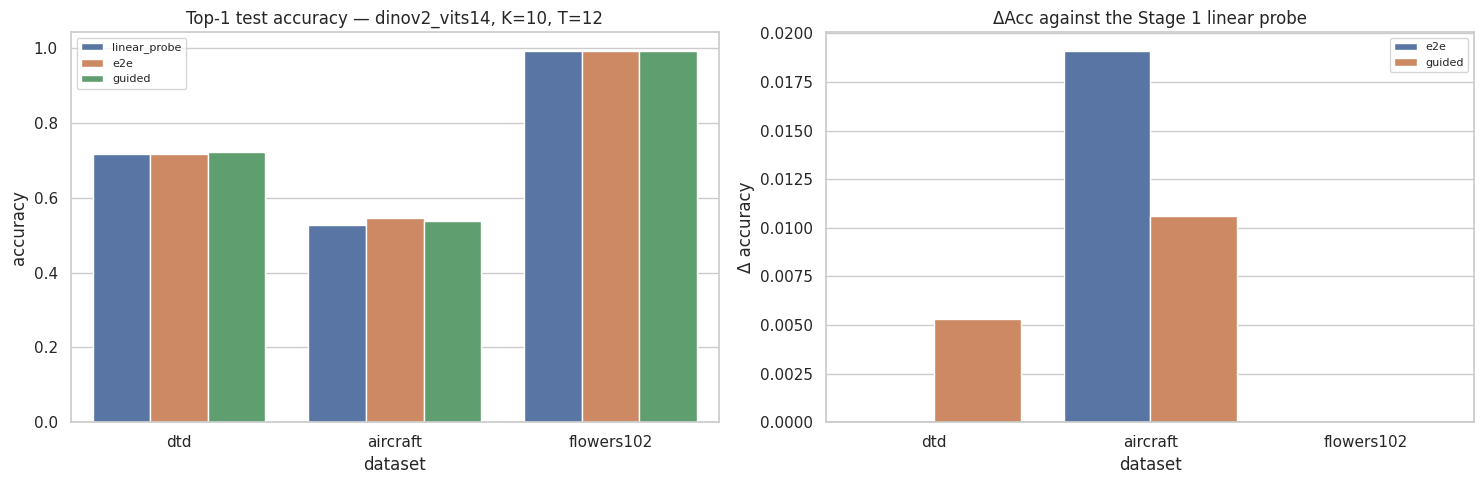


Runs whose selected checkpoint was epoch 0 (the FM stayed at the identity): 9 of 18


,dataset,strategy,subset_seed,best_val_accuracy,test_accuracy
1,dtd,e2e,0,0.722872,0.711702
4,dtd,e2e,1,0.729255,0.726064
7,dtd,e2e,2,0.702128,0.712234
19,flowers102,e2e,0,0.996078,0.993495
20,flowers102,guided,0,0.996078,0.993495
22,flowers102,e2e,1,0.996078,0.993495
23,flowers102,guided,1,0.996078,0.993495
25,flowers102,e2e,2,0.996078,0.993495
26,flowers102,guided,2,0.996078,0.993495


In [57]:
METHOD_ORDER = ['linear_probe', 'e2e', 'guided']
METHOD_LABEL = {'linear_probe': 'Stage 1 linear probe',
                'e2e': 'Stage 3 end-to-end rollout',
                'guided': 'Stage 3 classifier-guided'}

summary = (results_df.groupby(['dataset', 'strategy'], as_index=False)
           .agg(mean_accuracy=('test_accuracy', 'mean'), std_accuracy=('test_accuracy', 'std'),
                mean_delta=('delta_accuracy', 'mean'), std_delta=('delta_accuracy', 'std'),
                mean_best_epoch=('best_epoch', 'mean'), n=('test_accuracy', 'size')))
summary['strategy'] = pd.Categorical(summary['strategy'], METHOD_ORDER, ordered=True)
summary = summary.sort_values(['dataset', 'strategy'])
summary.to_csv(OUTPUT_ROOT / 'accuracy_summary.csv', index=False)
display(summary)

table = summary.pivot(index='dataset', columns='strategy', values='mean_accuracy')
print('\nTop-1 test accuracy (mean over 3 subset seeds), with ΔAcc vs the linear probe:\n')
header = f"{'dataset':<12}" + ''.join(f'{METHOD_LABEL[m]:>30}' for m in METHOD_ORDER)
print(header); print('-' * len(header))
for dataset_name in DATASETS:
    row = f'{dataset_name:<12}'
    for method in METHOD_ORDER:
        part = summary[(summary.dataset == dataset_name) & (summary.strategy == method)]
        if part.empty: row += f"{'-':>30}"; continue
        acc, sd, delta = part.iloc[0][['mean_accuracy', 'std_accuracy', 'mean_delta']]
        cell = f'{acc:.4f}±{sd:.4f}' if method == 'linear_probe' else f'{acc:.4f} ({delta:+.4f})'
        row += f'{cell:>30}'
    print(row)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_df = summary[summary.strategy != 'linear_probe']
sns.barplot(data=summary, x='dataset', y='mean_accuracy', hue='strategy', ax=axes[0],
            order=DATASETS, hue_order=METHOD_ORDER)
axes[0].set_title(f'Top-1 test accuracy — {ENCODER}, K={SHOT}, T={T}')
axes[0].set_ylabel('accuracy'); axes[0].legend(title='', fontsize=8)
sns.barplot(data=plot_df, x='dataset', y='mean_delta', hue='strategy', ax=axes[1],
            order=DATASETS, hue_order=METHOD_ORDER[1:])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('ΔAcc against the Stage 1 linear probe')
axes[1].set_ylabel('Δ accuracy'); axes[1].legend(title='', fontsize=8)
plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'accuracy_and_delta.png', dpi=150); plt.show()

identity_kept = results_df[(results_df.strategy != 'linear_probe') & (results_df.best_epoch == 0)]
print(f'\nRuns whose selected checkpoint was epoch 0 (the FM stayed at the identity): '
      f'{len(identity_kept)} of {len(results_df[results_df.strategy != "linear_probe"])}')
if len(identity_kept):
    display(identity_kept[['dataset', 'strategy', 'subset_seed', 'best_val_accuracy', 'test_accuracy']])

## 11. Training and validation behaviour

Both curves come from the same runs the table above reports. Two reading notes:

- **Epoch 0 is the identity FM**, so the validation-accuracy curve starts exactly at the linear
  probe's validation accuracy. Its train loss is `NaN` by construction — no update has happened —
  and is omitted from the loss panel.
- The two strategies minimize **different quantities**. Strategy 1's training loss is the
  classification cross-entropy on the rollout endpoint; Strategy 2's is a velocity regression MSE
  against a target that itself moves every `target_refresh_every` epochs. They are plotted on
  separate axes and must not be compared by magnitude. A Strategy 2 loss that *rises* is not
  divergence — it usually means the target moved further away after a refresh.

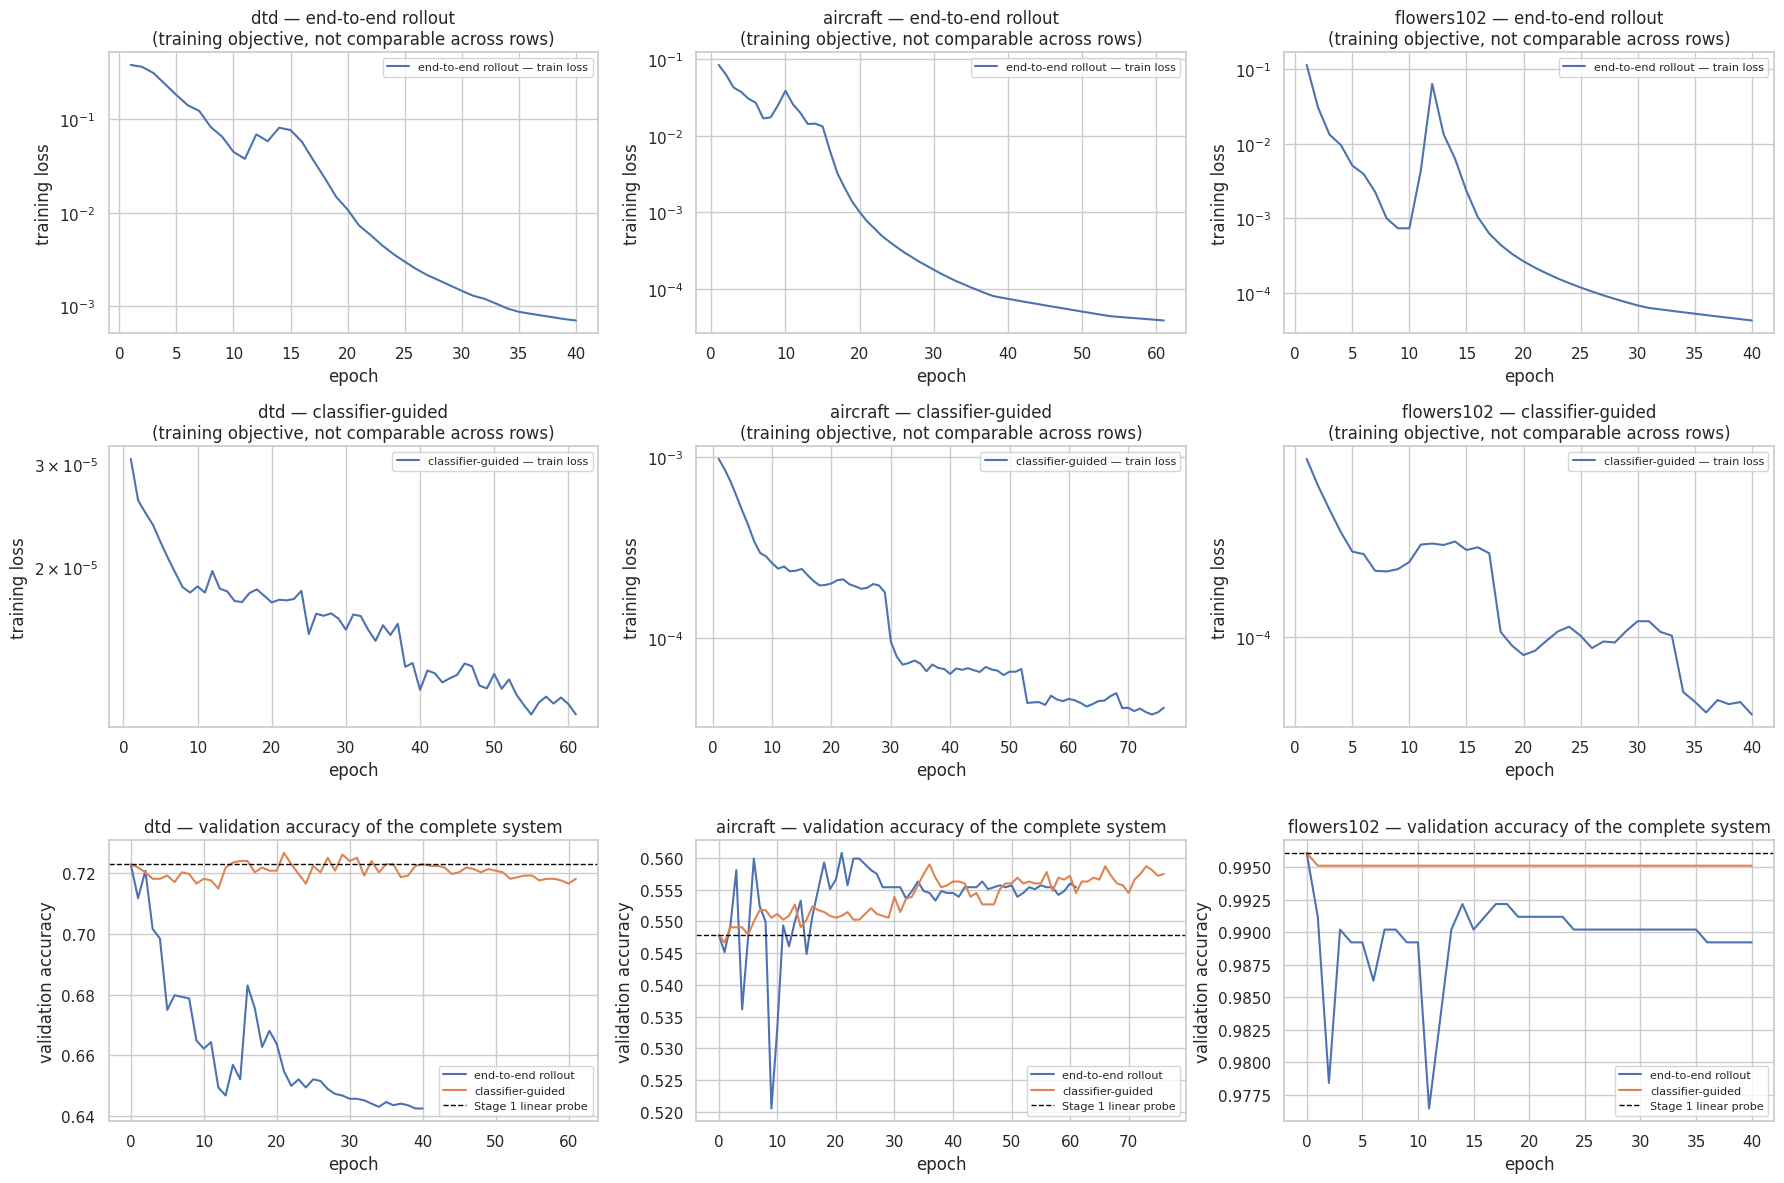

,strategy,mean_epochs,mean_best_epoch,mean_runtime_s,mean_relative_displacement
0,e2e,46.000000,6.000000,7.224070,0.297902
1,guided,56.666667,16.666667,2.926666,0.152160


mean_relative_displacement is ||z_hat - z|| / ||z||, averaged over the test split: how far the FM actually moves the representation it was initialized to leave untouched.


In [58]:
CURVE_SEED = SUBSET_SEEDS[0]
fig, axes = plt.subplots(3, len(DATASETS), figsize=(6 * len(DATASETS), 12), squeeze=False)
for col, dataset_name in enumerate(DATASETS):
    probe = PROBES[(dataset_name, CURVE_SEED)]
    for strategy, label in STRATEGIES:
        history = pd.DataFrame(main_histories[(strategy, dataset_name, CURVE_SEED)])
        trained = history[history.epoch > 0]
        ax = axes[0][col] if strategy == 'e2e' else axes[1][col]
        ax.plot(trained.epoch, trained.train_loss, label=f'{label} — train loss')
        ax.set_yscale('log'); ax.set_xlabel('epoch'); ax.set_ylabel('training loss')
        ax.set_title(f'{dataset_name} — {label}\n(training objective, not comparable across rows)')
        ax.legend(fontsize=8)
        axes[2][col].plot(history.epoch, history.val_accuracy, label=f'{label}')
    axes[2][col].axhline(probe['stage1_val_accuracy'], color='black', linestyle='--', linewidth=1,
                         label='Stage 1 linear probe')
    axes[2][col].set_xlabel('epoch'); axes[2][col].set_ylabel('validation accuracy')
    axes[2][col].set_title(f'{dataset_name} — validation accuracy of the complete system')
    axes[2][col].legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'training_curves.png', dpi=150); plt.show()

behaviour = (results_df[results_df.strategy != 'linear_probe']
             .groupby('strategy', as_index=False)
             .agg(mean_epochs=('epochs_trained', 'mean'), mean_best_epoch=('best_epoch', 'mean'),
                  mean_runtime_s=('runtime_seconds', 'mean'),
                  mean_relative_displacement=('relative_displacement', 'mean')))
display(behaviour)
print('mean_relative_displacement is ||z_hat - z|| / ||z||, averaged over the test split: how far '
      'the FM actually moves the representation it was initialized to leave untouched.')

## 12. Feature-space visualization

For a readable subset of classes, the original features `z` and the transported features `ẑ` under
both Stage 3 methods, on the **same test examples with the same class colors** across all three
panels.

Following the Stage 2 convention, the 2D embedding is fit **jointly** over all three feature sets
being compared, and the three panels then **share axis limits**. A joint fit that is autoscaled per
panel would rescale each view independently and hide exactly the movement the figure exists to show.

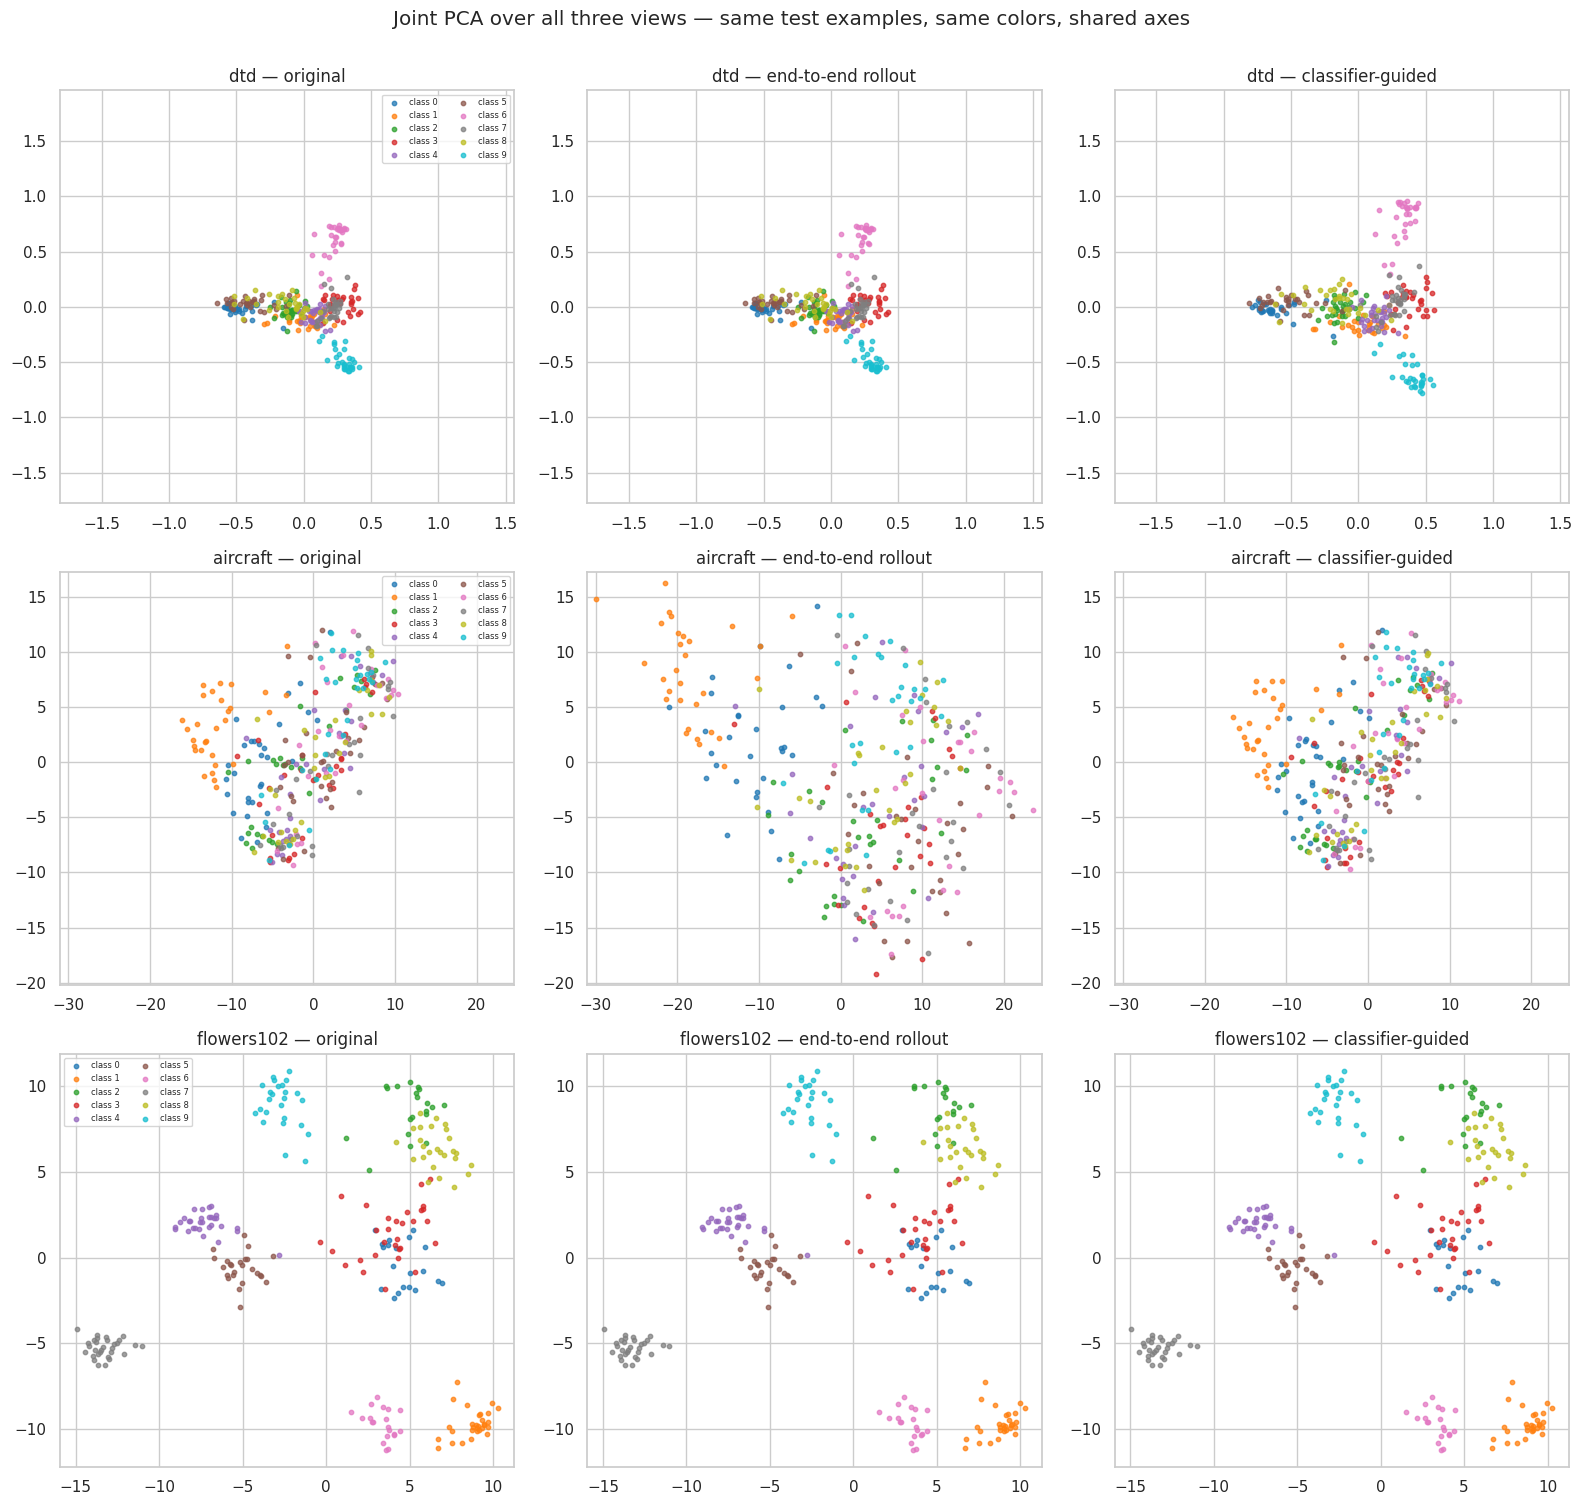

In [59]:
N_VIS_CLASSES = 10
VIS_PER_CLASS = 30
VIS_SEED = SUBSET_SEEDS[0]

def visualization_sample(dataset_name, subset_seed):
    z_te, y_te = STAGE3_DATA[(dataset_name, subset_seed)][4:6]
    y_np = y_te.cpu().numpy()
    classes = np.unique(y_np)[:N_VIS_CLASSES]
    rng = np.random.default_rng(0); chosen = []
    for c in classes:
        idx = np.flatnonzero(y_np == c)
        chosen.extend(rng.choice(idx, size=min(VIS_PER_CLASS, len(idx)), replace=False).tolist())
    chosen = np.asarray(sorted(chosen))
    return z_te[chosen], y_np[chosen], classes

def transported_views(dataset_name, subset_seed, z_subset):
    views = {'original': z_subset.cpu().numpy()}
    for strategy, label in STRATEGIES:
        net = load_stage3_net(strategy, dataset_name, subset_seed, z_subset.shape[1])
        with torch.no_grad():
            views[label] = euler_rollout(net, z_subset, T).cpu().numpy()
    return views

def joint_projection(views, method='pca'):
    stacked = np.concatenate(list(views.values()), axis=0)
    if method == 'pca':
        embedded = PCA(n_components=2, random_state=0).fit_transform(stacked)
    else:
        perplexity = min(30, max(5, stacked.shape[0] // 4 - 1))
        embedded = TSNE(n_components=2, random_state=0, init='pca',
                        perplexity=perplexity).fit_transform(stacked)
    n = next(iter(views.values())).shape[0]
    return {name: embedded[i * n:(i + 1) * n] for i, name in enumerate(views)}

def plot_joint_views(method):
    fig, axes = plt.subplots(len(DATASETS), 3, figsize=(16, 5 * len(DATASETS)), squeeze=False)
    for row, dataset_name in enumerate(DATASETS):
        z_subset, y_subset, classes = visualization_sample(dataset_name, VIS_SEED)
        views = transported_views(dataset_name, VIS_SEED, z_subset)
        embedded = joint_projection(views, method)
        all_points = np.concatenate(list(embedded.values()), axis=0)
        xlim = (all_points[:, 0].min() - 1, all_points[:, 0].max() + 1)
        ylim = (all_points[:, 1].min() - 1, all_points[:, 1].max() + 1)
        for col, (name, points) in enumerate(embedded.items()):
            ax = axes[row][col]
            for i, c in enumerate(classes):
                mask = y_subset == c
                ax.scatter(points[mask, 0], points[mask, 1], s=10, alpha=0.75,
                           color=plt.cm.tab10(i % 10), label=f'class {c}' if col == 0 else None)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)
            ax.set_title(f'{dataset_name} — {name}')
        axes[row][0].legend(fontsize=6, ncol=2, loc='best')
    plt.suptitle(f'Joint {method.upper()} over all three views — same test examples, same colors, '
                 f'shared axes', y=1.002)
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / f'feature_space_{method}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_joint_views('pca')

### 12b. The same comparison under a joint t-SNE

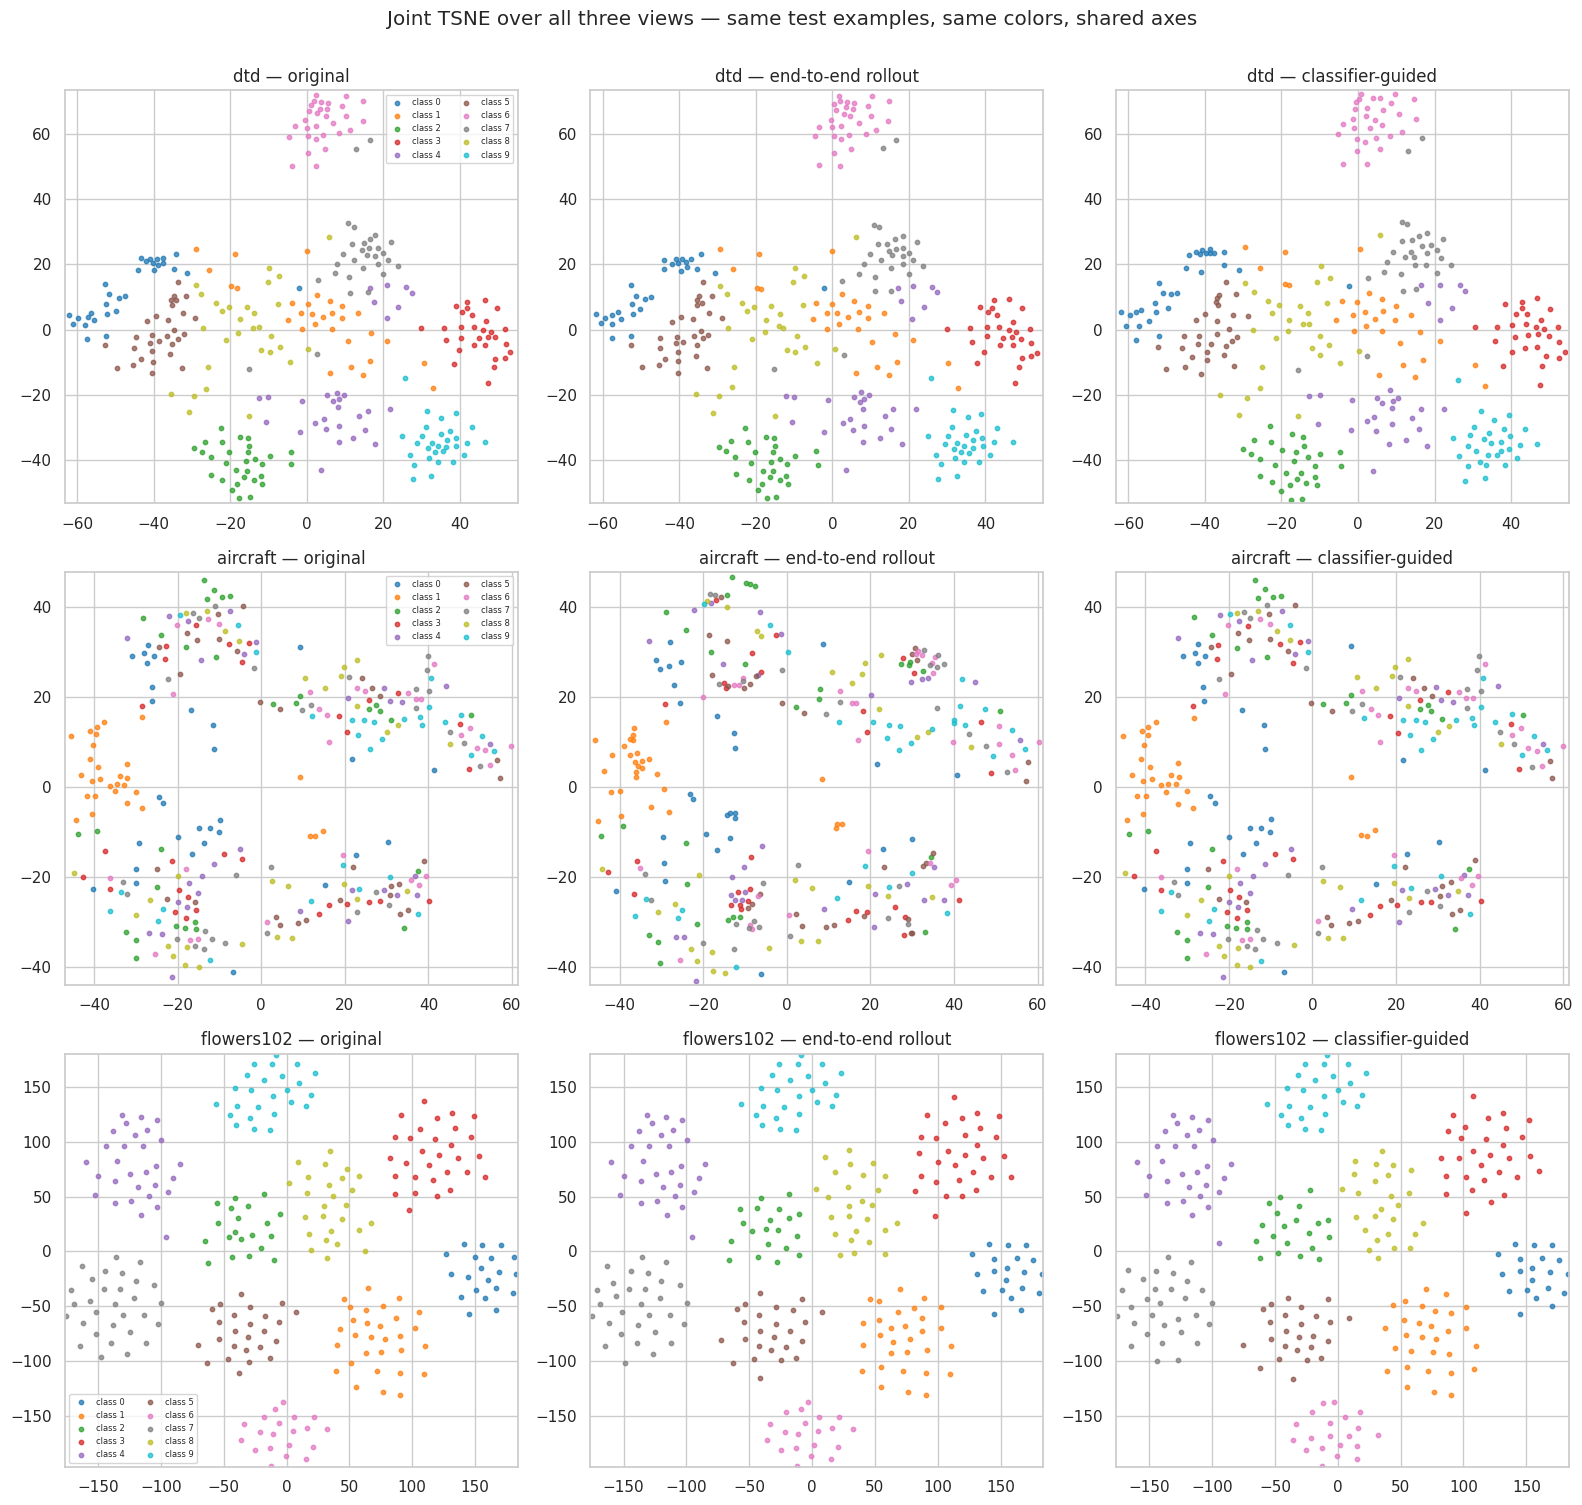

In [60]:
plot_joint_views('tsne')

## 13. Is the difference real? Paired confidence intervals and McNemar

The three-seed mean in Section 10 has no error bar worth trusting on its own. Two paired tests are
run per (dataset, method), both against the linear probe **on the same test split and the same
seed**:

- a percentile bootstrap over test *examples*, giving a 95% CI for ΔAcc;
- an exact McNemar test on the discordant pairs, which is the appropriate test for two classifiers
  evaluated on one sample.

These measure test-set uncertainty, not seed uncertainty. A ΔAcc whose CI spans zero should be
reported as "no measurable difference", not as a small win.

In [61]:
from scipy import stats

def paired_bootstrap_ci(correct_a, correct_b, n_resamples=10000, seed=0):
    a = np.asarray(correct_a, dtype=float); b = np.asarray(correct_b, dtype=float)
    rng = np.random.default_rng(seed); n = len(a)
    idx = rng.integers(0, n, size=(n_resamples, n))
    diffs = a[idx].mean(1) - b[idx].mean(1)
    return float(a.mean() - b.mean()), float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))

def mcnemar_exact(correct_a, correct_b):
    a = np.asarray(correct_a, dtype=bool); b = np.asarray(correct_b, dtype=bool)
    b10 = int((a & ~b).sum())      # Stage 3 right, probe wrong
    b01 = int((~a & b).sum())      # probe right, Stage 3 wrong
    n = b01 + b10
    p = 1.0 if n == 0 else float(stats.binomtest(b10, n, 0.5).pvalue)
    return b01, b10, p

sig_rows = []
for dataset_name in DATASETS:
    for subset_seed in SUBSET_SEEDS:
        y_te = STAGE3_DATA[(dataset_name, subset_seed)][5].cpu()
        probe_correct = (main_predictions[('linear_probe', dataset_name, subset_seed)] == y_te).numpy()
        for strategy, label in STRATEGIES:
            fm_correct = (main_predictions[(strategy, dataset_name, subset_seed)] == y_te).numpy()
            delta, lo, hi = paired_bootstrap_ci(fm_correct, probe_correct)
            b01, b10, p = mcnemar_exact(fm_correct, probe_correct)
            sig_rows.append(dict(dataset=dataset_name, strategy=strategy, subset_seed=subset_seed,
                                 delta=delta, ci_low=lo, ci_high=hi,
                                 probe_only_correct=b01, fm_only_correct=b10, mcnemar_p=p,
                                 significant=bool(p < 0.05), ci_excludes_zero=bool(lo > 0 or hi < 0)))
significance_df = pd.DataFrame(sig_rows)
significance_df.to_csv(OUTPUT_ROOT / 'paired_significance.csv', index=False)
display(significance_df)

n_cells = len(significance_df)
print(f'\nOf {n_cells} (dataset, method, seed) cells:')
print(f'  {int((significance_df.delta > 0).sum())} favour Stage 3, '
      f'{int((significance_df.delta < 0).sum())} favour the linear probe, '
      f'{int((significance_df.delta == 0).sum())} are exactly tied')
print(f'  {int(significance_df.ci_excludes_zero.sum())} have a bootstrap CI excluding zero')
print(f'  {int(significance_df.significant.sum())} reach McNemar p < 0.05')

,dataset,strategy,subset_seed,delta,ci_low,ci_high,probe_only_correct,fm_only_correct,mcnemar_p,significant,ci_excludes_zero
0,dtd,e2e,0,0.000000,0.000000,0.000000,0,0,1.000000,False,False
1,dtd,guided,0,0.003191,-0.006383,0.012766,39,45,0.585647,False,False
2,dtd,e2e,1,0.000000,0.000000,0.000000,0,0,1.000000,False,False
3,dtd,guided,1,0.003723,-0.005319,0.013298,35,42,0.494382,False,False
4,dtd,e2e,2,0.000000,0.000000,0.000000,0,0,1.000000,False,False
5,dtd,guided,2,0.009043,-0.001064,0.019149,37,54,0.092947,False,False
6,aircraft,e2e,0,0.018902,0.006301,0.031503,202,265,0.004069,True,True
7,aircraft,guided,0,0.011401,0.004200,0.018902,58,96,0.002749,True,True
8,aircraft,e2e,1,0.015002,0.003593,0.026403,173,223,0.013702,True,True
9,aircraft,guided,1,0.006901,-0.000600,0.014101,64,87,0.073049,False,False



Of 18 (dataset, method, seed) cells:
  9 favour Stage 3, 0 favour the linear probe, 9 are exactly tied
  5 have a bootstrap CI excluding zero
  5 reach McNemar p < 0.05


## 14. Variant comparison A — does regularizing the displacement help Strategy 1?

The specification invites experimenting with penalties on the displacement `‖ẑ - z‖` and on the
predicted velocity magnitude. This sweep runs on **subset seed 0 only** — it is a variant comparison,
not a replacement for the three-seed main result — and reports both accuracy and how far the FM
actually moved the representation.

The hypothesis being tested is the one stated in Section 6: an unregularized rollout can push `ẑ`
off the manifold the frozen head was fit on and win training accuracy by exploiting the classifier.
If that is happening, the unregularized runs should show large `relative_displacement` together with
a train/test gap that the penalized runs do not have.


=== regularization sweep | dtd | subset 0 ===
  loaded  e2e__reg_none            dtd         subset 0  test 0.7117
  loaded  e2e__disp_1e-2           dtd         subset 0  test 0.7117
  loaded  e2e__disp_1e-1           dtd         subset 0  test 0.7117
  loaded  e2e__vel_1e-3            dtd         subset 0  test 0.7117

=== regularization sweep | aircraft | subset 0 ===
  loaded  e2e__reg_none            aircraft    subset 0  test 0.5518
  loaded  e2e__disp_1e-2           aircraft    subset 0  test 0.5488
  loaded  e2e__disp_1e-1           aircraft    subset 0  test 0.5389
  loaded  e2e__vel_1e-3            aircraft    subset 0  test 0.5656

=== regularization sweep | flowers102 | subset 0 ===
  loaded  e2e__reg_none            flowers102  subset 0  test 0.9935
  loaded  e2e__disp_1e-2           flowers102  subset 0  test 0.9935
  loaded  e2e__disp_1e-1           flowers102  subset 0  test 0.9935
  loaded  e2e__vel_1e-3            flowers102  subset 0  test 0.9935


,dataset,variant,test_accuracy,delta_accuracy,relative_displacement,best_epoch,best_val_accuracy
0,dtd,e2e__reg_none,0.711702,1.927640e-08,0.000000,0,0.722872
1,dtd,e2e__disp_1e-2,0.711702,1.927640e-08,0.000000,0,0.722872
2,dtd,e2e__disp_1e-1,0.711702,1.927640e-08,0.000000,0,0.722872
3,dtd,e2e__vel_1e-3,0.711702,1.927640e-08,0.000000,0,0.722872
4,aircraft,e2e__reg_none,0.551755,1.890187e-02,0.905675,21,0.560756
5,aircraft,e2e__disp_1e-2,0.548755,1.590157e-02,0.034885,90,0.568557
6,aircraft,e2e__disp_1e-1,0.538854,6.000580e-03,0.017620,42,0.550555
7,aircraft,e2e__vel_1e-3,0.565557,3.270325e-02,0.080844,43,0.576658
8,flowers102,e2e__reg_none,0.993495,8.937304e-09,0.000000,0,0.996078
9,flowers102,e2e__disp_1e-2,0.993495,8.937304e-09,0.000000,0,0.996078


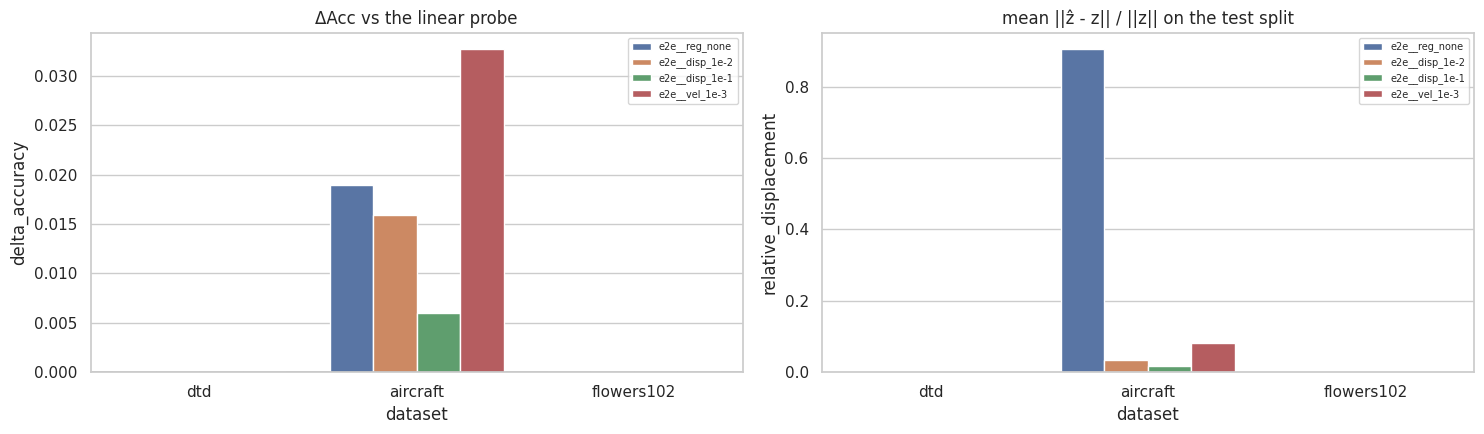

In [62]:
RUN_REGULARIZATION_SWEEP = True
REG_SWEEP = [
    ('e2e__reg_none',      dict()),
    ('e2e__disp_1e-2',     dict(lambda_displacement=1e-2)),
    ('e2e__disp_1e-1',     dict(lambda_displacement=1e-1)),
    ('e2e__vel_1e-3',      dict(lambda_velocity=1e-3)),
]
SWEEP_SEED = SUBSET_SEEDS[0]

if RUN_REGULARIZATION_SWEEP:
    sweep_rows = []
    for dataset_name in DATASETS:
        print(f'\n=== regularization sweep | {dataset_name} | subset {SWEEP_SEED} ===')
        for tag, hyper in REG_SWEEP:
            metrics, _, _ = run_one('e2e', dataset_name, SWEEP_SEED, tag=tag, hyper=hyper,
                                    root=OUTPUT_ROOT / 'sweeps')
            sweep_rows.append(dict(metrics, variant=tag,
                                   lambda_displacement=hyper.get('lambda_displacement', 0.0),
                                   lambda_velocity=hyper.get('lambda_velocity', 0.0)))
    reg_df = pd.DataFrame(sweep_rows)
    reg_df.to_csv(OUTPUT_ROOT / 'sweep_regularization.csv', index=False)
    display(reg_df[['dataset', 'variant', 'test_accuracy', 'delta_accuracy',
                    'relative_displacement', 'best_epoch', 'best_val_accuracy']])
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    sns.barplot(data=reg_df, x='dataset', y='delta_accuracy', hue='variant', ax=axes[0], order=DATASETS)
    axes[0].axhline(0, color='black', linewidth=1); axes[0].set_title('ΔAcc vs the linear probe')
    axes[0].legend(fontsize=7)
    sns.barplot(data=reg_df, x='dataset', y='relative_displacement', hue='variant', ax=axes[1], order=DATASETS)
    axes[1].set_title('mean ||ẑ - z|| / ||z|| on the test split'); axes[1].legend(fontsize=7)
    plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'sweep_regularization.png', dpi=150); plt.show()
else:
    print('Regularization sweep disabled (RUN_REGULARIZATION_SWEEP = False).')

## 15. Variant comparison B — the Strategy 2 guidance knobs

The specification names four things to experiment with: the feature-space step size, the number of
target-improvement steps, how often targets are recomputed, and whether the target updates are
normalized or otherwise constrained. This sweep varies each in turn from the default, again on
subset seed 0 only.


=== guidance sweep | dtd | subset 0 ===
  loaded  guided__default          dtd         subset 0  test 0.7149
  loaded  guided__step_0.02        dtd         subset 0  test 0.7186
  loaded  guided__step_0.30        dtd         subset 0  test 0.7170
  loaded  guided__steps_1          dtd         subset 0  test 0.7165
  loaded  guided__steps_10         dtd         subset 0  test 0.7117
  loaded  guided__norm_none        dtd         subset 0  test 0.7138
  loaded  guided__norm_unit        dtd         subset 0  test 0.7117
  loaded  guided__refresh_10       dtd         subset 0  test 0.7144

=== guidance sweep | aircraft | subset 0 ===
  loaded  guided__default          aircraft    subset 0  test 0.5443
  loaded  guided__step_0.02        aircraft    subset 0  test 0.5395
  loaded  guided__step_0.30        aircraft    subset 0  test 0.5488
  loaded  guided__steps_1          aircraft    subset 0  test 0.5416
  loaded  guided__steps_10         aircraft    subset 0  test 0.5398
  loaded  guided

,dataset,variant,step_size,num_steps,normalize,refresh_every,test_accuracy,delta_accuracy,relative_displacement,best_epoch
0,dtd,guided__default,0.10,3,trust_region,1,0.714894,3.191509e-03,0.341749,21
1,dtd,guided__step_0.02,0.02,3,trust_region,1,0.718617,6.914913e-03,0.087852,15
2,dtd,guided__step_0.30,0.30,3,trust_region,1,0.717021,5.319168e-03,0.447486,17
3,dtd,guided__steps_1,0.10,1,trust_region,1,0.716489,4.787253e-03,0.336930,35
4,dtd,guided__steps_10,0.10,10,trust_region,1,0.711702,1.927640e-08,0.000000,0
5,dtd,guided__norm_none,0.10,3,none,1,0.713830,2.127679e-03,0.382203,17
6,dtd,guided__norm_unit,0.10,3,unit,1,0.711702,1.927640e-08,0.000000,0
7,dtd,guided__refresh_10,0.10,3,trust_region,10,0.714362,2.659594e-03,0.043307,5
8,aircraft,guided__default,0.10,3,trust_region,1,0.544254,1.140112e-02,0.101469,36
9,aircraft,guided__step_0.02,0.02,3,trust_region,1,0.539454,6.600640e-03,0.052518,24


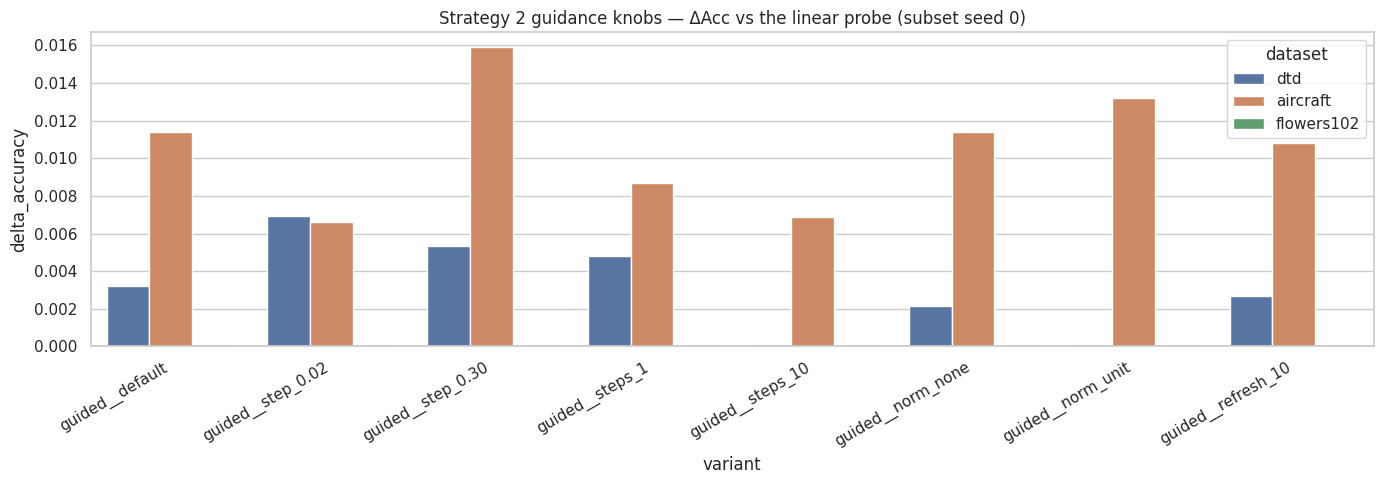

In [63]:
RUN_GUIDANCE_SWEEP = True
GUIDANCE_SWEEP = [
    ('guided__default',        dict()),
    ('guided__step_0.02',      dict(guidance_step_size=0.02)),
    ('guided__step_0.30',      dict(guidance_step_size=0.30)),
    ('guided__steps_1',        dict(guidance_num_steps=1)),
    ('guided__steps_10',       dict(guidance_num_steps=10)),
    ('guided__norm_none',      dict(guidance_normalize='none')),
    ('guided__norm_unit',      dict(guidance_normalize='unit')),
    ('guided__refresh_10',     dict(target_refresh_every=10)),
]

if RUN_GUIDANCE_SWEEP:
    guide_rows = []
    for dataset_name in DATASETS:
        print(f'\n=== guidance sweep | {dataset_name} | subset {SWEEP_SEED} ===')
        for tag, hyper in GUIDANCE_SWEEP:
            metrics, _, _ = run_one('guided', dataset_name, SWEEP_SEED, tag=tag, hyper=hyper,
                                    root=OUTPUT_ROOT / 'sweeps')
            guide_rows.append(dict(metrics, variant=tag,
                                   step_size=hyper.get('guidance_step_size', S3['guidance_step_size']),
                                   num_steps=hyper.get('guidance_num_steps', S3['guidance_num_steps']),
                                   normalize=hyper.get('guidance_normalize', S3['guidance_normalize']),
                                   refresh_every=hyper.get('target_refresh_every', S3['target_refresh_every'])))
    guidance_df = pd.DataFrame(guide_rows)
    guidance_df.to_csv(OUTPUT_ROOT / 'sweep_guidance.csv', index=False)
    display(guidance_df[['dataset', 'variant', 'step_size', 'num_steps', 'normalize',
                         'refresh_every', 'test_accuracy', 'delta_accuracy',
                         'relative_displacement', 'best_epoch']])
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.barplot(data=guidance_df, x='variant', y='delta_accuracy', hue='dataset', ax=ax)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title('Strategy 2 guidance knobs — ΔAcc vs the linear probe (subset seed 0)')
    plt.xticks(rotation=30, ha='right'); plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / 'sweep_guidance.png', dpi=150); plt.show()
else:
    print('Guidance sweep disabled (RUN_GUIDANCE_SWEEP = False).')

## 16. Optional extension — jointly fine-tuning the classifier

> *"After completing the frozen-classifier experiments, you may also unfreeze the pretrained linear
> classifier and jointly optimize the FM transformation and classifier. Compare this with the
> frozen-classifier setting and with the original Stage 1 linear probe."*

Both comparisons the specification names are in the table below, and a third that it does not ask for
but without which the other two cannot be read.

**Why the third one is not optional in practice.** Unfreezing changes two things at once: it adds the
FM *and* it gives the classifier more training. A joint run that beats Stage 1 may simply be a probe
that trained longer. So `head_only` continues the same Stage 1 head for the same epoch budget, under
the same optimizer and the same validation-checkpointing rule, with **no FM at all**. Any joint gain
smaller than the `head_only` gain is not evidence for flow matching.

**And a decomposition, because even that is not enough.** Once both parts have moved, "which one did
the work" is still open. Every joint run is therefore scored four ways on the same test split:

| evaluation | what it isolates |
|---|---|
| `probe` = `W₀ z + b₀` | the Stage 1 baseline |
| `fm_only` = `W₀ ẑ + b₀` | the trained FM, judged by the **original** classifier |
| `head_only` = `W₁ z + b₁` | the fine-tuned classifier, with **no** FM |
| `full` = `W₁ ẑ + b₁` | the joint system as reported |

If `full ≈ head_only`, the flow is decoration. If `full ≈ fm_only`, the classifier barely moved. The
accompanying `head_drift` columns say how far the classifier travelled to get there, which is the
quantity the regularization in Section 16b controls.

In [ ]:
RUN_JOINT_FINETUNE = True

def head_anchor_penalty(joint_head, w0, b0):
    """Squared drift of the unfrozen classifier from the Stage 1 one it started as — the
    'additional regularization' the specification names for this setting. Generic weight decay pulls
    the head toward zero, which is not where it began; this pulls it toward the pretrained solution,
    so it directly controls how much of any gain is allowed to come from moving the classifier."""
    return (joint_head.weight - w0).pow(2).sum() + (joint_head.bias - b0).pow(2).sum()

@torch.no_grad()
def attribute_joint(net, frozen_head, tuned_head, z, y, T):
    """Decompose a joint run into who actually did the work (see the table above)."""
    net.eval()
    z_hat = euler_rollout(net, z, T)
    def acc(logits): return float((logits.argmax(1) == y).float().mean())
    return dict(probe=acc(frozen_head(z)), fm_only=acc(frozen_head(z_hat)),
                head_only_head=acc(tuned_head(z)), full=acc(tuned_head(z_hat)))

@torch.no_grad()
def head_drift(frozen_head, tuned_head):
    """How far the classifier moved. A large gain with near-zero drift means the FM did the work."""
    w0, w1, b0, b1 = frozen_head.weight, tuned_head.weight, frozen_head.bias, tuned_head.bias
    cos = F.cosine_similarity(w0, w1, dim=1)
    return dict(weight_drift=float((w1 - w0).norm()),
                relative_weight_drift=float((w1 - w0).norm() / w0.norm().clamp_min(1e-12)),
                bias_drift=float((b1 - b0).norm()),
                mean_class_cosine=float(cos.mean()), min_class_cosine=float(cos.min()))

def train_head_only(dataset_name, subset_seed, run_dir):
    """Control: continue training the Stage 1 head alone, same budget, same rule, no FM."""
    probe = PROBES[(dataset_name, subset_seed)]
    z_tr, y_tr, z_va, y_va, z_te, y_te = STAGE3_DATA[(dataset_name, subset_seed)]
    run_dir.mkdir(parents=True, exist_ok=True)
    seed_everything(INIT_SEED)
    head = copy.deepcopy(probe['head']); head.requires_grad_(True); head.train()
    optimizer = torch.optim.AdamW(head.parameters(), lr=S3['head_learning_rate'],
                                  weight_decay=S3['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5,
                                                           patience=S3['lr_patience'])
    init_acc, init_loss, _ = evaluate_system(None, head, z_va, y_va, T)
    best_acc, best_epoch, stale = init_acc, 0, 0
    best_state = copy.deepcopy(head.state_dict())
    history = [dict(epoch=0, train_loss=float('nan'), val_accuracy=init_acc, val_loss=init_loss)]
    n_train = z_tr.shape[0]
    started = time.perf_counter()
    for epoch in range(1, S3['max_epochs'] + 1):
        generator = torch.Generator().manual_seed(INIT_SEED * 100000 + epoch)
        perm = torch.randperm(n_train, generator=generator)
        head.train(); total = 0.0
        for start in range(0, n_train, S3['batch_size']):
            idx = perm[start:start + S3['batch_size']]
            optimizer.zero_grad(set_to_none=True)
            loss = F.cross_entropy(head(z_tr[idx]), y_tr[idx])
            loss.backward(); optimizer.step(); total += loss.item() * len(idx)
        val_acc, val_loss, _ = evaluate_system(None, head, z_va, y_va, T)
        history.append(dict(epoch=epoch, train_loss=total / n_train, val_accuracy=val_acc,
                            val_loss=val_loss))
        if val_acc > best_acc + S3['min_delta']:
            best_acc, best_epoch = val_acc, epoch
            best_state = copy.deepcopy(head.state_dict()); stale = 0
        else:
            stale += 1
        scheduler.step(val_acc)
        if stale >= S3['early_stopping_patience']: break
    head.load_state_dict(best_state); head.eval()
    test_acc, test_ce, test_pred = evaluate_system(None, head, z_te, y_te, T)
    metrics = dict(dataset=dataset_name, encoder=ENCODER, shot=str(SHOT), subset_seed=subset_seed,
                   strategy='head_only', tag='head_only', T=None, joint_finetune=True,
                   baseline_test_accuracy=probe['stage1_test_accuracy'], best_val_accuracy=best_acc,
                   best_epoch=best_epoch, epochs_trained=len(history) - 1, test_accuracy=test_acc,
                   test_loss=test_ce, delta_accuracy=test_acc - probe['stage1_test_accuracy'],
                   mean_displacement=0.0, relative_displacement=0.0,
                   runtime_seconds=time.perf_counter() - started,
                   feature_transform=probe['feature_transform'],
                   **{f'drift_{k}': v for k, v in head_drift(probe['head'], head).items()})
    (run_dir / 'metrics.json').write_text(json.dumps(metrics, indent=2))
    pd.DataFrame(history).to_csv(run_dir / 'history.csv', index=False)
    np.save(run_dir / 'test_predictions.npy', test_pred.numpy())
    torch.save(head.state_dict(), run_dir / 'finetuned_head.pt')
    return metrics

def load_finetuned_head(tag, dataset_name, subset_seed, root, feature_dim, num_classes):
    path = run_directory(tag, dataset_name, subset_seed, root) / 'finetuned_head.pt'
    head = nn.Linear(feature_dim, num_classes).to(DEVICE)
    head.load_state_dict(torch.load(path, map_location=DEVICE, weights_only=False))
    head.requires_grad_(False); head.eval()
    return head

if RUN_JOINT_FINETUNE:
    EXT_ROOT = OUTPUT_ROOT / 'extension'
    joint_rows, attribution_rows = [], []
    for dataset_name in DATASETS:
        print(f'\n=== joint fine-tuning | {dataset_name} ===')
        for subset_seed in SUBSET_SEEDS:
            probe = PROBES[(dataset_name, subset_seed)]
            z_te, y_te = STAGE3_DATA[(dataset_name, subset_seed)][4:6]
            n_classes = probe['head'].out_features

            # (1) the Stage 1 linear probe, and (2) the FROZEN Stage 3 runs — the specification
            # asks for both of these comparisons explicitly
            joint_rows.append(dict(dataset=dataset_name, strategy='linear_probe',
                                   subset_seed=subset_seed,
                                   test_accuracy=probe['stage1_test_accuracy'], delta_accuracy=0.0))
            for strategy, _label in STRATEGIES:
                frozen = results_df[(results_df.dataset == dataset_name) &
                                    (results_df.strategy == strategy) &
                                    (results_df.subset_seed == subset_seed)].iloc[0]
                joint_rows.append(dict(dataset=dataset_name, strategy=f'{strategy}__frozen',
                                       subset_seed=subset_seed,
                                       test_accuracy=float(frozen.test_accuracy),
                                       delta_accuracy=float(frozen.delta_accuracy)))

            # (3) the head-only control
            control_dir = run_directory('head_only', dataset_name, subset_seed, EXT_ROOT)
            control_path = control_dir / 'metrics.json'
            if control_path.exists() and not FORCE_RETRAIN:
                control = json.loads(control_path.read_text())
                print(f"  loaded  head_only        {dataset_name:11s} subset {subset_seed}  "
                      f"test {control['test_accuracy']:.4f}")
            else:
                control = train_head_only(dataset_name, subset_seed, control_dir)
                print(f"  trained head_only        {dataset_name:11s} subset {subset_seed}  "
                      f"test {control['test_accuracy']:.4f} ({control['delta_accuracy']:+.4f})")
            joint_rows.append(control)

            # (4) the joint runs themselves, with the four-way attribution
            for strategy, _label in STRATEGIES:
                tag = f'{strategy}__joint'
                metrics, _, _ = run_one(strategy, dataset_name, subset_seed, tag=tag, joint=True,
                                        root=EXT_ROOT)
                joint_rows.append(dict(metrics, strategy=tag))
                net = load_stage3_net(tag, dataset_name, subset_seed, z_te.shape[1], EXT_ROOT)
                tuned = load_finetuned_head(tag, dataset_name, subset_seed, EXT_ROOT,
                                            z_te.shape[1], n_classes)
                attribution_rows.append(dict(
                    dataset=dataset_name, strategy=tag, subset_seed=subset_seed,
                    **attribute_joint(net, probe['head'], tuned, z_te, y_te, T),
                    **head_drift(probe['head'], tuned)))

    joint_df = pd.DataFrame(joint_rows)
    joint_df.to_csv(OUTPUT_ROOT / 'joint_finetune.csv', index=False)
    attribution_df = pd.DataFrame(attribution_rows)
    attribution_df.to_csv(OUTPUT_ROOT / 'joint_attribution.csv', index=False)

    JOINT_ORDER = ['linear_probe', 'e2e__frozen', 'guided__frozen', 'head_only',
                   'e2e__joint', 'guided__joint']
    joint_summary = (joint_df.groupby(['dataset', 'strategy'], as_index=False)
                     .agg(mean_accuracy=('test_accuracy', 'mean'),
                          std_accuracy=('test_accuracy', 'std'),
                          mean_delta=('delta_accuracy', 'mean')))
    joint_summary['strategy'] = pd.Categorical(joint_summary['strategy'], JOINT_ORDER, ordered=True)
    joint_summary = joint_summary.sort_values(['dataset', 'strategy'])
    joint_summary.to_csv(OUTPUT_ROOT / 'joint_finetune_summary.csv', index=False)
    display(joint_summary.round(4))
    display(attribution_df.groupby(['dataset', 'strategy'], as_index=False)
            .agg(probe=('probe', 'mean'), fm_only=('fm_only', 'mean'),
                 head_only_head=('head_only_head', 'mean'), full=('full', 'mean'),
                 rel_head_drift=('relative_weight_drift', 'mean'),
                 mean_class_cosine=('mean_class_cosine', 'mean')).round(4))
else:
    print('Joint fine-tuning extension disabled (RUN_JOINT_FINETUNE = False).')

### 16b. What the extension asks to experiment with

> *"You may experiment with choices such as different learning rates for the FM and classifier,
> delayed unfreezing, or additional regularization."*

All three, one knob at a time from the default, on subset seed 0 and the end-to-end strategy only —
this is a variant comparison, not a replacement for the three-seed table above.

- **Learning-rate ratio.** The head starts at a good solution and the FM starts at nothing, so
  giving them the same learning rate lets the head move fastest early, when the FM has no signal
  yet. The default is `head_lr = 0.1 × fm_lr`; `1.0×` and `0.01×` bracket it.
- **Delayed unfreezing.** Holding the classifier frozen for the first `n` epochs lets the FM leave
  the identity before the head starts chasing it. With zero-initialised output the FM's first few
  epochs are nearly flat, so this is the interval where an unfrozen head would otherwise absorb all
  the gradient.
- **Additional regularization.** `λ‖W − W₀‖² + λ‖b − b₀‖²` anchors the classifier to the Stage 1
  solution. This, rather than weight decay, is the regularizer that matches the question: weight
  decay pulls the head toward zero, whereas the thing worth limiting is how far it strays from the
  pretrained classifier the stage is supposed to be improving *on*.

In [ ]:
RUN_JOINT_SWEEP = True
JOINT_SWEEP = [
    ('joint__default',        dict()),
    ('joint__headlr_1x',      dict(head_learning_rate=S3['learning_rate'])),
    ('joint__headlr_0.01x',   dict(head_learning_rate=S3['learning_rate'] * 0.01)),
    ('joint__unfreeze_10',    dict(unfreeze_epoch=10)),
    ('joint__unfreeze_30',    dict(unfreeze_epoch=30)),
    ('joint__anchor_1e-2',    dict(lambda_head_anchor=1e-2)),
    ('joint__anchor_1e0',     dict(lambda_head_anchor=1.0)),
]

if RUN_JOINT_SWEEP:
    sweep_rows = []
    for dataset_name in DATASETS:
        print(f'\n=== joint sweep | {dataset_name} | subset {SWEEP_SEED} ===')
        probe = PROBES[(dataset_name, SWEEP_SEED)]
        z_te, y_te = STAGE3_DATA[(dataset_name, SWEEP_SEED)][4:6]
        n_classes = probe['head'].out_features
        for tag, hyper in JOINT_SWEEP:
            metrics, _, _ = run_one('e2e', dataset_name, SWEEP_SEED, tag=tag, hyper=hyper,
                                    joint=True, root=OUTPUT_ROOT / 'sweeps')
            net = load_stage3_net(tag, dataset_name, SWEEP_SEED, z_te.shape[1], OUTPUT_ROOT / 'sweeps')
            tuned = load_finetuned_head(tag, dataset_name, SWEEP_SEED, OUTPUT_ROOT / 'sweeps',
                                        z_te.shape[1], n_classes)
            sweep_rows.append(dict(
                metrics, variant=tag,
                head_learning_rate=hyper.get('head_learning_rate', S3['head_learning_rate']),
                unfreeze_epoch=hyper.get('unfreeze_epoch', S3['unfreeze_epoch']),
                lambda_head_anchor=hyper.get('lambda_head_anchor', 0.0),
                **attribute_joint(net, probe['head'], tuned, z_te, y_te, T),
                **head_drift(probe['head'], tuned)))
    joint_sweep_df = pd.DataFrame(sweep_rows)
    joint_sweep_df.to_csv(OUTPUT_ROOT / 'sweep_joint_finetune.csv', index=False)
    display(joint_sweep_df[['dataset', 'variant', 'head_learning_rate', 'unfreeze_epoch',
                            'lambda_head_anchor', 'test_accuracy', 'delta_accuracy',
                            'relative_weight_drift', 'fm_only', 'head_only_head',
                            'best_epoch']].round(4))
else:
    print('Joint sweep disabled (RUN_JOINT_SWEEP = False).')

### 16c. Who did the work?

Three views. The bars decompose each joint cell into the four evaluations above; the middle panel
plots how far the classifier travelled against what was gained by travelling; the right panel is the
sweep, so the effect of each knob is readable at a glance.

The panel to look at first is the middle one. A point high and to the left is the good case — a real
gain with the classifier barely moved, meaning the FM produced a representation the *pretrained*
classifier handles better, which is what Stage 3 set out to test. A point high and to the right is a
fine-tuned classifier wearing a flow-matching hat.

In [ ]:
if RUN_JOINT_FINETUNE:
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))

    tidy = attribution_df.melt(id_vars=['dataset', 'strategy'],
                               value_vars=['probe', 'fm_only', 'head_only_head', 'full'],
                               var_name='evaluation', value_name='accuracy')
    tidy['cell'] = tidy.dataset + '\n' + tidy.strategy.str.replace('__joint', '', regex=False)
    sns.barplot(data=tidy, x='cell', y='accuracy', hue='evaluation', ax=axes[0],
                hue_order=['probe', 'fm_only', 'head_only_head', 'full'])
    axes[0].set(title='Four-way attribution of every joint run', xlabel='')
    axes[0].legend(fontsize=7, title='')
    axes[0].tick_params(axis='x', labelsize=7)

    attribution_df = attribution_df.assign(gain=lambda d: d.full - d.probe)
    for (ds, strat), part in attribution_df.groupby(['dataset', 'strategy']):
        axes[1].scatter(part.relative_weight_drift, part.gain, s=70, alpha=0.85,
                        label=f'{ds} · {strat.replace("__joint", "")}')
    axes[1].axhline(0, color='black', lw=1)
    axes[1].set(xlabel='relative classifier drift  ||W₁ − W₀|| / ||W₀||',
                ylabel='gain over the linear probe',
                title='Did the gain need the classifier to move?')
    axes[1].legend(fontsize=7)

    if RUN_JOINT_SWEEP:
        sweep_tidy = joint_sweep_df.copy()
        sweep_tidy['short'] = sweep_tidy.variant.str.replace('joint__', '', regex=False)
        sns.barplot(data=sweep_tidy, x='short', y='delta_accuracy', hue='dataset', ax=axes[2])
        axes[2].axhline(0, color='black', lw=1)
        axes[2].set(title='Learning rates, delayed unfreezing, anchor strength',
                    xlabel='', ylabel='ΔAcc vs the linear probe')
        axes[2].tick_params(axis='x', rotation=30, labelsize=7)
        axes[2].legend(fontsize=7)
    plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'joint_finetune.png', dpi=150); plt.show()

    print('Verdict per cell (mean over seeds):')
    for (ds, strat), part in attribution_df.groupby(['dataset', 'strategy']):
        gain = part.full.mean() - part.probe.mean()
        fm_share = part.fm_only.mean() - part.probe.mean()
        head_share = part.head_only_head.mean() - part.probe.mean()
        if abs(gain) < 1e-6:
            verdict = 'no gain to attribute'
        elif fm_share > 0.7 * gain and head_share < 0.3 * gain:
            verdict = 'the FM did the work'
        elif head_share > 0.7 * gain and fm_share < 0.3 * gain:
            verdict = 'the classifier did the work - the flow is decoration here'
        else:
            verdict = 'both contributed'
        print(f'  {ds:11s} {strat:14s} gain {gain:+.4f} | FM alone {fm_share:+.4f}, '
              f'head alone {head_share:+.4f}, drift {part.relative_weight_drift.mean():.4f} '
              f'-> {verdict}')

## 17. Optional analysis A — samples and the classifier at intermediate flow times

`ref/stage_2.pdf` closes with an optional invitation: *"explore the learned flow in the reverse
direction, starting from the class prototypes, and consider comparing samples and prototypes at
intermediate flow times."* Both were done for Stage 2 in `04` §12–§13. Sections 17 and 18 are the
Stage 3 versions, which are not the same experiment, because Stage 3 has no class prototypes — the
flow's destination is a *classifier*, not a point.

For intermediate flow times the adaptation is direct: classify every intermediate Euler state
`ẑ_k` through the frozen head, over the complete test split.

**The resulting curve is self-anchoring at both ends, which is what makes it trustworthy.** Under
Stage 3's identity initialization `ẑ_0 = z` exactly, so accuracy at `t=0` *is* the Stage 1 linear
probe — not approximately, identically — and accuracy at `t=1` is the Stage 3 result reported in
Section 10. The curve is ΔAcc unrolled, and the notebook asserts both endpoints rather than
trusting them.

Four quantities are tracked per step. Accuracy and cross-entropy are the obvious ones. The **margin**
— the true-class logit minus the best competing logit — is the more informative one, because it
moves continuously where accuracy moves in discrete jumps and shows whether the flow is pushing
samples across the decision boundary or merely deeper into the region they already occupied.
**Relative displacement** `‖ẑ_k − z‖ / ‖z‖` says how far the representation has travelled to buy
that, and it starts at exactly zero.

Verified: t=0 accuracy equals the Stage 1 linear probe and t=1 equals the Section 10 result, for every dataset and strategy.


,dataset,strategy,acc_t0,acc_t1,gain,best_t,best_acc,margin_t0,margin_t1,ce_t0,ce_t1,displacement_t1
0,dtd,e2e,0.711702,0.711702,0.000000,0.000000,0.711702,1.184618,1.184618,1.180151,1.180151,0.000000
1,dtd,guided,0.711702,0.714894,0.003191,0.333333,0.718617,1.184618,1.899873,1.180151,0.981280,0.341749
2,aircraft,e2e,0.532853,0.551755,0.018902,0.666667,0.561656,0.025432,0.277856,1.977345,2.303866,0.905675
3,aircraft,guided,0.532853,0.544254,0.011401,1.000000,0.544254,0.025432,0.235421,1.977345,1.927351,0.101469
4,flowers102,e2e,0.993495,0.993495,0.000000,0.000000,0.993495,3.426575,3.426575,0.262292,0.262292,0.000000
5,flowers102,guided,0.993495,0.993495,0.000000,0.000000,0.993495,3.426575,3.426575,0.262292,0.262292,0.000000


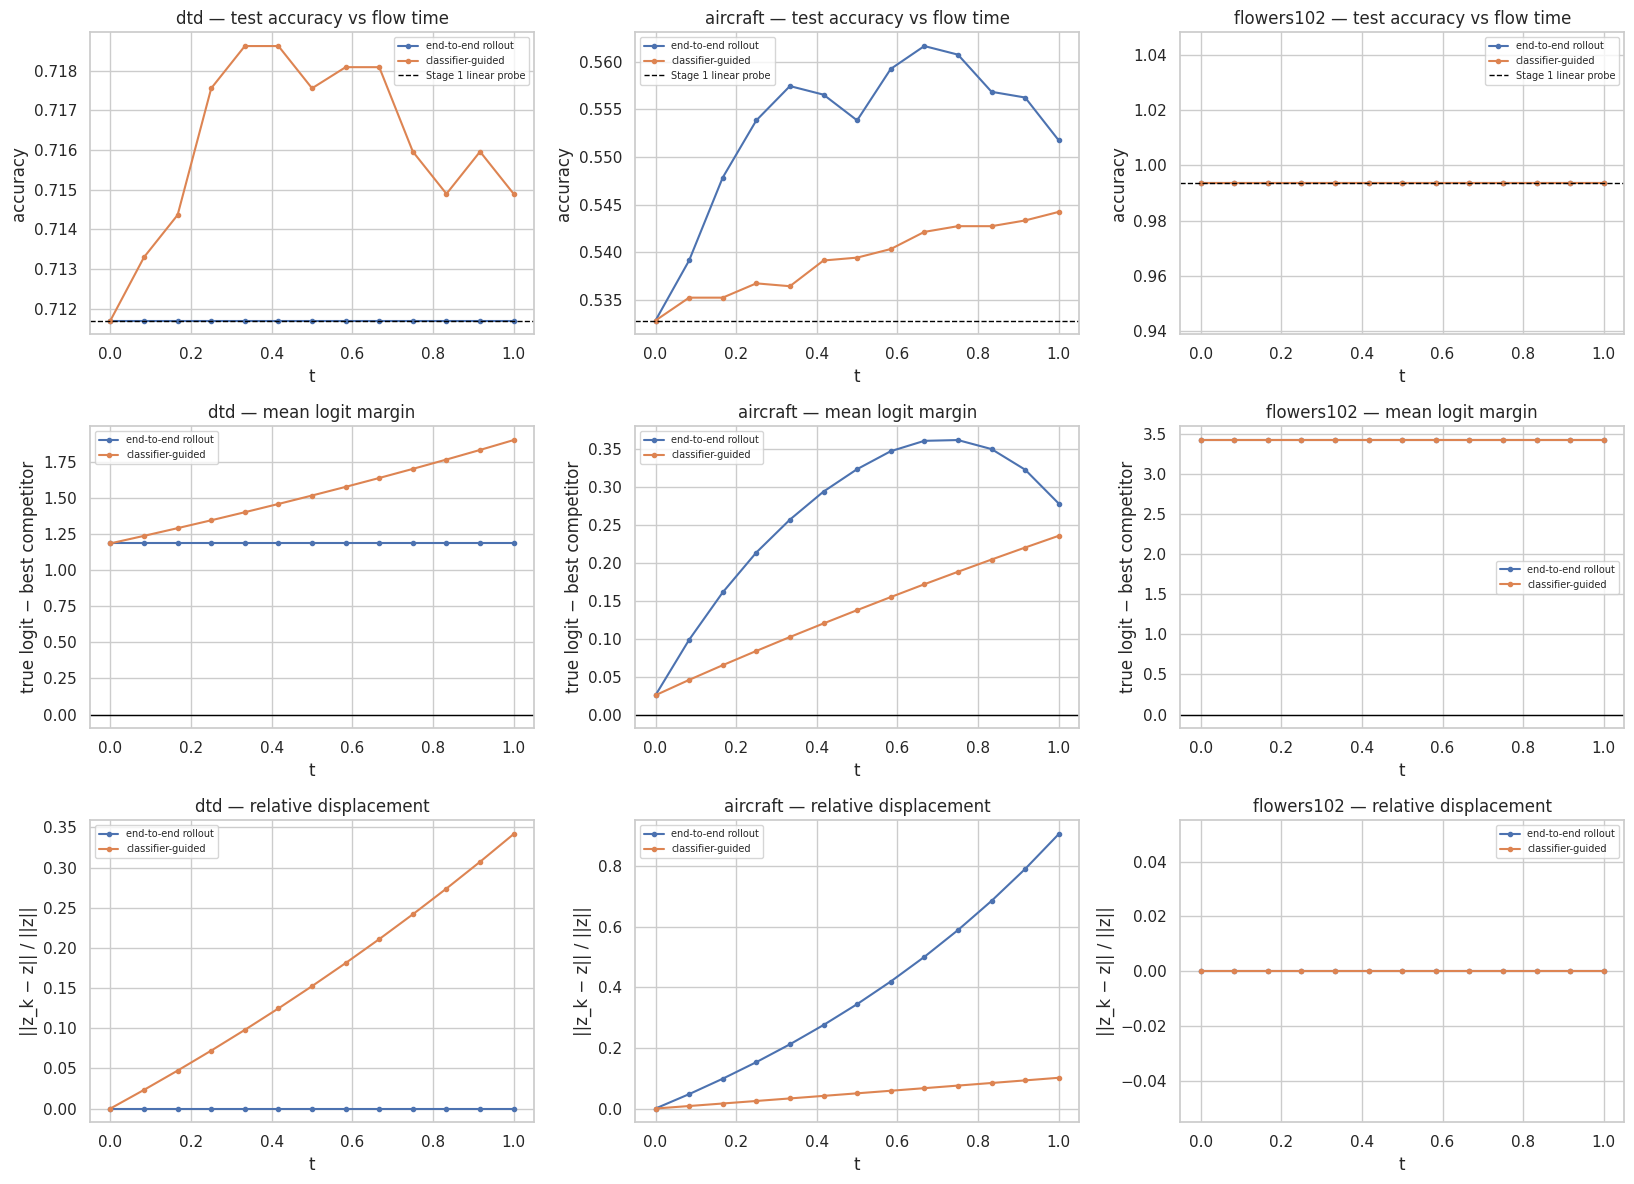

In [65]:
FLOW_TIME_SEED = SUBSET_SEEDS[0]

@torch.no_grad()
def flow_metrics_over_time(net, head, z, y, T, chunk=2048):
    """Per-step statistics of every intermediate Euler state, over the full test split.

    Uses the shared `euler_rollout`, so these are exactly the states inference produces; chunking
    bounds memory only. Row k=0 is the untouched feature, which under Stage 3's identity
    initialization means it *is* the Stage 1 linear probe, and row k=T is the reported Stage 3
    result.
    """
    net.eval()
    n_steps = T + 1
    correct, ce, margin, disp = (np.zeros(n_steps) for _ in range(4))
    for s in range(0, len(z), chunk):
        zb, yb = z[s:s + chunk], y[s:s + chunk]
        _, traj = euler_rollout(net, zb, T, return_trajectory=True)
        for k, zk in enumerate(traj):
            logits = head(zk)
            true_logit = logits.gather(1, yb.view(-1, 1)).squeeze(1)
            masked = logits.clone(); masked.scatter_(1, yb.view(-1, 1), float('-inf'))
            correct[k] += float((logits.argmax(1) == yb).sum().item())
            ce[k] += float(F.cross_entropy(logits, yb, reduction='sum').item())
            margin[k] += float((true_logit - masked.max(1).values).sum().item())
            disp[k] += float((zk - zb).norm(dim=1).sum().item())
    n = len(z)
    mean_norm = z.norm(dim=1).mean().item()
    return pd.DataFrame(dict(step=np.arange(n_steps), t=np.arange(n_steps) / T,
                             accuracy=correct / n, cross_entropy=ce / n, margin=margin / n,
                             relative_displacement=(disp / n) / mean_norm))

flow_time_curves, flow_time_rows = {}, []
for dataset_name in DATASETS:
    probe = PROBES[(dataset_name, FLOW_TIME_SEED)]
    z_te, y_te = STAGE3_DATA[(dataset_name, FLOW_TIME_SEED)][4:6]
    for strategy, label in STRATEGIES:
        net = load_stage3_net(strategy, dataset_name, FLOW_TIME_SEED, z_te.shape[1])
        curve = flow_metrics_over_time(net, probe['head'], z_te, y_te, T)
        flow_time_curves[(dataset_name, strategy)] = curve
        # Both ends are asserted, not assumed: t=0 must be the Stage 1 probe and t=1 must be the
        # number Section 10 reported, or the curve is not the one it claims to be.
        drift0 = abs(curve.accuracy.iloc[0] - probe['stage1_test_accuracy'])
        end_acc = float(results_df[(results_df.dataset == dataset_name) &
                                   (results_df.strategy == strategy) &
                                   (results_df.subset_seed == FLOW_TIME_SEED)].test_accuracy.iloc[0])
        drift1 = abs(curve.accuracy.iloc[-1] - end_acc)
        if drift0 > 1e-6 or drift1 > 1e-9:
            raise RuntimeError(f'{dataset_name}/{strategy}: flow-time curve is not anchored '
                               f'(t=0 off by {drift0:.2e}, t=1 off by {drift1:.2e}).')
        flow_time_rows.append(dict(
            dataset=dataset_name, strategy=strategy,
            acc_t0=curve.accuracy.iloc[0], acc_t1=curve.accuracy.iloc[-1],
            gain=curve.accuracy.iloc[-1] - curve.accuracy.iloc[0],
            best_t=float(curve.t[curve.accuracy.idxmax()]), best_acc=curve.accuracy.max(),
            margin_t0=curve.margin.iloc[0], margin_t1=curve.margin.iloc[-1],
            ce_t0=curve.cross_entropy.iloc[0], ce_t1=curve.cross_entropy.iloc[-1],
            displacement_t1=curve.relative_displacement.iloc[-1]))

flow_time_summary = pd.DataFrame(flow_time_rows)
flow_time_summary.to_csv(OUTPUT_ROOT / 'intermediate_flow_time_metrics.csv', index=False)
print('Verified: t=0 accuracy equals the Stage 1 linear probe and t=1 equals the Section 10 result, '
      'for every dataset and strategy.')
display(flow_time_summary)

fig, axes = plt.subplots(3, len(DATASETS), figsize=(5.5 * len(DATASETS), 12), squeeze=False)
for col, dataset_name in enumerate(DATASETS):
    probe = PROBES[(dataset_name, FLOW_TIME_SEED)]
    for strategy, label in STRATEGIES:
        curve = flow_time_curves[(dataset_name, strategy)]
        axes[0][col].plot(curve.t, curve.accuracy, marker='o', ms=3, label=label)
        axes[1][col].plot(curve.t, curve.margin, marker='o', ms=3, label=label)
        axes[2][col].plot(curve.t, curve.relative_displacement, marker='o', ms=3, label=label)
    axes[0][col].axhline(probe['stage1_test_accuracy'], color='black', ls='--', lw=1,
                         label='Stage 1 linear probe')
    axes[0][col].set(title=f'{dataset_name} — test accuracy vs flow time', xlabel='t', ylabel='accuracy')
    axes[1][col].axhline(0, color='black', lw=1)
    axes[1][col].set(title=f'{dataset_name} — mean logit margin', xlabel='t',
                     ylabel='true logit − best competitor')
    axes[2][col].set(title=f'{dataset_name} — relative displacement', xlabel='t',
                     ylabel='||z_k − z|| / ||z||')
    for r in range(3): axes[r][col].legend(fontsize=7)
plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'intermediate_flow_times.png', dpi=150); plt.show()

### 17b. The point cloud at intermediate flow times

The same states as a picture, on the same readable subset of classes used in Section 12, in one
jointly-fit PCA per dataset with shared axis limits across the strip.

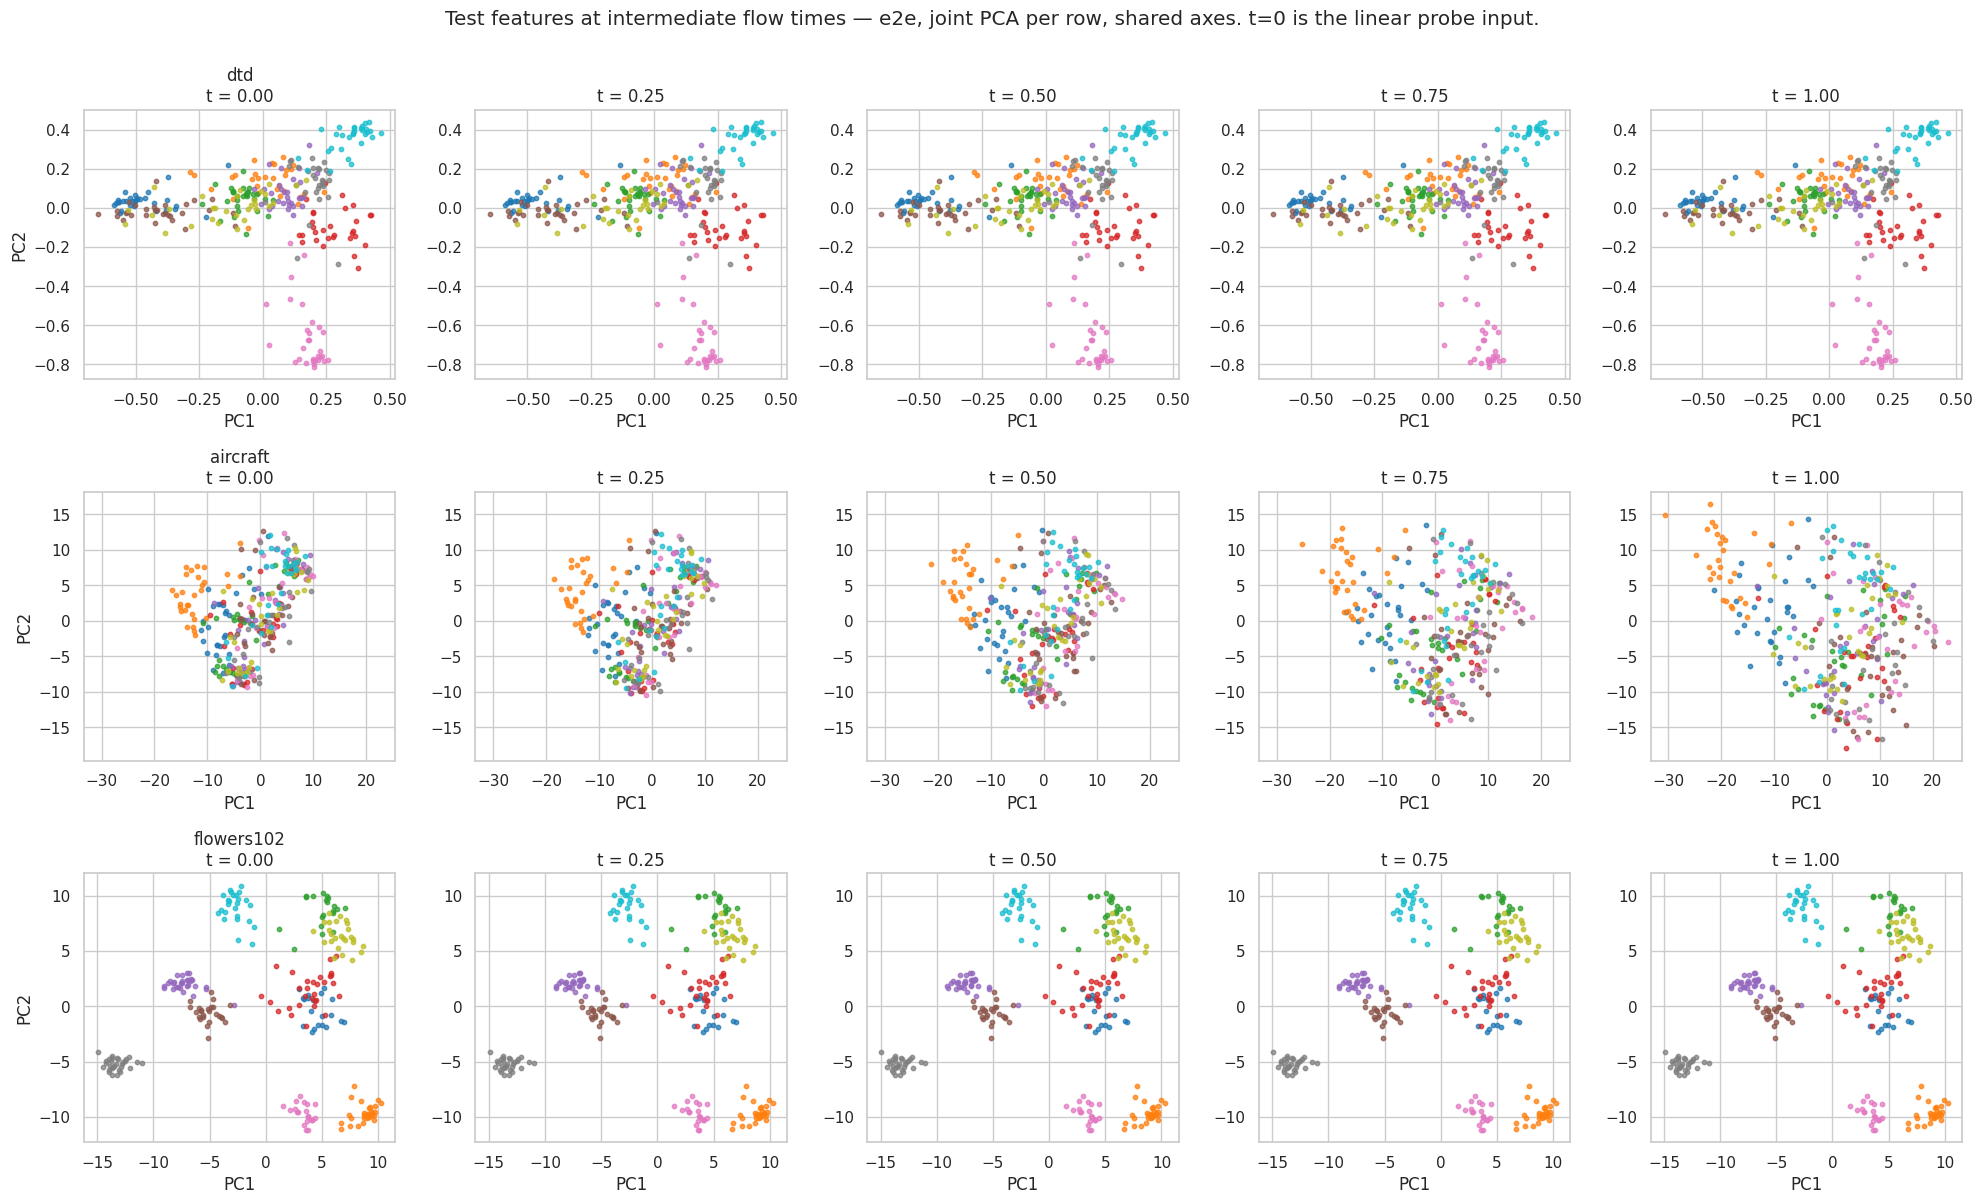

In [66]:
SNAPSHOT_STRATEGY = 'e2e'     # set to 'guided' for the other strategy's strip
SNAPSHOT_STEPS = [0, T // 4, T // 2, 3 * T // 4, T]

fig, axes = plt.subplots(len(DATASETS), len(SNAPSHOT_STEPS),
                         figsize=(4 * len(SNAPSHOT_STEPS), 4 * len(DATASETS)), squeeze=False)
for row, dataset_name in enumerate(DATASETS):
    z_subset, y_subset, classes = visualization_sample(dataset_name, FLOW_TIME_SEED)
    net = load_stage3_net(SNAPSHOT_STRATEGY, dataset_name, FLOW_TIME_SEED, z_subset.shape[1])
    with torch.no_grad():
        _, traj = euler_rollout(net, z_subset, T, return_trajectory=True)
    states = [traj[k].cpu().numpy() for k in SNAPSHOT_STEPS]
    pca = PCA(n_components=2, random_state=0).fit(np.concatenate(states))
    xy = [pca.transform(s) for s in states]
    allxy = np.concatenate(xy)
    pad = 0.05 * np.ptp(allxy, axis=0)
    xlim = (allxy[:, 0].min() - pad[0], allxy[:, 0].max() + pad[0])
    ylim = (allxy[:, 1].min() - pad[1], allxy[:, 1].max() + pad[1])
    for col, (k, points) in enumerate(zip(SNAPSHOT_STEPS, xy)):
        ax = axes[row][col]
        for i, c in enumerate(classes):
            mask = y_subset == c
            ax.scatter(points[mask, 0], points[mask, 1], s=10, alpha=0.75, color=plt.cm.tab10(i % 10))
        header = f'{dataset_name}\n' if col == 0 else ''
        ax.set(title=f'{header}t = {k / T:.2f}', xlim=xlim, ylim=ylim,
               xlabel='PC1', ylabel='PC2' if col == 0 else '')
fig.suptitle(f'Test features at intermediate flow times — {SNAPSHOT_STRATEGY}, joint PCA per row, '
             f'shared axes. t=0 is the linear probe input.', y=1.002)
plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'intermediate_flow_snapshots.png', dpi=150,
                                bbox_inches='tight'); plt.show()

### 17c. Ablation — a validation-selected stopping time

If accuracy peaks before `t=1`, the flow is overshooting and the last few Euler steps cost
something. Stage 2 asked this in `04` §16; it is at least as relevant here, because Strategy 1
minimizes a classification loss on `K=10` examples per class and has an obvious route to
overfitting — during development, on deliberately small fabricated data, training cross-entropy fell
from 1.76 to 0.11 while test accuracy went *down*.

`t*` is chosen on **validation only**. The test curve is computed for reporting, but the index read
out of it was fixed before test was touched, so no test information enters the choice.
`oracle_best` is the best the test curve reaches at any `t`; the gap to it is the price of choosing
`t*` honestly. **This is an ablation — the required table in Section 10 always classifies `ẑ_T`.**

Ties are broken toward the earliest step, because `argmax` returns the first maximum. That is the
right default here — fewer Euler steps for the same validation accuracy is strictly cheaper — but it
means a run whose FM stayed at the identity reports `t* = 0` rather than `t* = 1`, since its curve is
flat. Read `t*` together with the `best_epoch` column from Section 10 rather than on its own.

In [67]:
RUN_TSTAR_ABLATION = True

@torch.no_grad()
def accuracy_by_step(net, head, z, y, T, chunk=4096):
    """Top-1 accuracy at each of the T+1 Euler states, using the shared integrator."""
    net.eval()
    correct = np.zeros(T + 1)
    for s in range(0, len(z), chunk):
        zb, yb = z[s:s + chunk], y[s:s + chunk]
        _, traj = euler_rollout(net, zb, T, return_trajectory=True)
        for k, zk in enumerate(traj):
            correct[k] += float((head(zk).argmax(1) == yb).sum().item())
    return correct / len(z)

if RUN_TSTAR_ABLATION:
    tstar_rows = []
    for dataset_name in DATASETS:
        for subset_seed in SUBSET_SEEDS:
            probe = PROBES[(dataset_name, subset_seed)]
            _, _, z_va, y_va, z_te, y_te = STAGE3_DATA[(dataset_name, subset_seed)]
            for strategy, label in STRATEGIES:
                net = load_stage3_net(strategy, dataset_name, subset_seed, z_te.shape[1])
                val_curve = accuracy_by_step(net, probe['head'], z_va, y_va, T)
                k_star = int(val_curve.argmax())
                test_curve = accuracy_by_step(net, probe['head'], z_te, y_te, T)
                tstar_rows.append(dict(
                    dataset=dataset_name, strategy=strategy, subset_seed=subset_seed,
                    t_star=k_star / T, val_at_tstar=float(val_curve[k_star]),
                    val_at_t1=float(val_curve[-1]),
                    test_at_tstar=float(test_curve[k_star]), test_at_t1=float(test_curve[-1]),
                    gain_from_early_stop=float(test_curve[k_star] - test_curve[-1]),
                    test_best_possible=float(test_curve.max()),
                    linear_probe=probe['stage1_test_accuracy']))
    tstar_runs = pd.DataFrame(tstar_rows)
    tstar_runs.to_csv(OUTPUT_ROOT / 'validation_selected_tstar_runs.csv', index=False)
    tstar_summary = tstar_runs.groupby(['dataset', 'strategy'], as_index=False).agg(
        mean_t_star=('t_star', 'mean'), test_at_t1=('test_at_t1', 'mean'),
        test_at_tstar=('test_at_tstar', 'mean'), gain=('gain_from_early_stop', 'mean'),
        gain_std=('gain_from_early_stop', 'std'), oracle_best=('test_best_possible', 'mean'),
        linear_probe=('linear_probe', 'mean'))
    tstar_summary['oracle_gap'] = tstar_summary.oracle_best - tstar_summary.test_at_tstar
    tstar_summary['delta_vs_probe_at_tstar'] = tstar_summary.test_at_tstar - tstar_summary.linear_probe
    tstar_summary.to_csv(OUTPUT_ROOT / 'validation_selected_tstar_summary.csv', index=False)
    improved = int((tstar_summary.gain > 0).sum())
    print(f'ABLATION. Stopping the flow at a validation-selected t* helps in {improved} of '
          f'{len(tstar_summary)} conditions (mean {tstar_summary.gain.mean():+.4f}, '
          f'best {tstar_summary.gain.max():+.4f}).')
    print(f'Mean t* = {tstar_runs.t_star.mean():.3f}. It is 1.0 in '
          f'{int((tstar_runs.t_star == 1.0).sum())} of {len(tstar_runs)} runs (the ablation changes '
          f'nothing there) and 0.0 in {int((tstar_runs.t_star == 0.0).sum())} (a flat curve, which '
          f'for an identity-selected run is expected rather than a finding).')
    display(tstar_summary.sort_values('gain', ascending=False))
else:
    print('t* ablation disabled (RUN_TSTAR_ABLATION = False).')

ABLATION. Stopping the flow at a validation-selected t* helps in 2 of 6 conditions (mean +0.0008, best +0.0037).
Mean t* = 0.412. It is 1.0 in 4 of 18 runs (the ablation changes nothing there) and 0.0 in 9 (a flat curve, which for an identity-selected run is expected rather than a finding).


,dataset,strategy,mean_t_star,test_at_t1,test_at_tstar,gain,gain_std,oracle_best,linear_probe,oracle_gap,delta_vs_probe_at_tstar
0,aircraft,e2e,0.694444,0.547555,0.551255,0.003700,0.004454,0.554655,0.528453,0.00340,2.280227e-02
3,dtd,guided,0.777778,0.721986,0.723050,0.001064,0.001843,0.725000,0.716667,0.00195,6.382987e-03
1,aircraft,guided,1.000000,0.539054,0.539054,0.000000,0.000000,0.539154,0.528453,0.00010,1.060105e-02
2,dtd,e2e,0.000000,0.716667,0.716667,0.000000,0.000000,0.716667,0.716667,0.00000,7.947286e-09
4,flowers102,e2e,0.000000,0.993495,0.993495,0.000000,0.000000,0.993495,0.993495,0.00000,8.937304e-09
5,flowers102,guided,0.000000,0.993495,0.993495,0.000000,0.000000,0.993495,0.993495,0.00000,8.937304e-09


## 18. Optional analysis B — the flow in reverse

Stage 2 could start the backward integration from its class prototypes. Stage 3 has none, so the
question has to be restated rather than copied. Two anchors are used, and they ask different things.

**A — the classifier's own class templates.** The frozen head's decision is entirely determined by
its weight rows `w_c`, which live in the same space as `z` and are the closest thing to a per-class
prototype the setting has. They carry no comparable magnitude, so they are rescaled to the mean
feature norm before being integrated backward through a field that only ever saw features at that
radius. The question: *what feature does the learned flow think maps toward this class direction?*
Recovery is the fraction of classes whose reverse-flowed template lands nearest its own class's mean
original feature.

The untouched template's recovery is the **pre-transport reference, not a ceiling.** `w_c` does not
sit inside its class's feature cloud to begin with, so moving it toward that cloud can legitimately
improve recovery. Stage 2's write-up originally mislabelled the analogous quantity as a ceiling and
`RESULTS.md` carries the correction; the same mistake is available here and is worth not repeating.

**B — a round trip on the class means.** Forward-flow each class mean, then integrate the result
back. This one has an unambiguous ideal: a perfectly invertible field returns the original mean, so
zero error is exactly right and there is nothing to argue about. It measures how much the forward
flow discards. An identity field scores exactly 0, which the local test asserts.

Both are approximate inverses at best. The backward pass evaluates the field at `t ∈ {1, …, 1/T}`
while the forward pass uses `t ∈ {0, …, 1−1/T}`, so the two do not coincide even for a perfectly
learned field — and a flow trained to make a classifier's job easier has every reason to be
contractive, which is not invertible in principle. This recovers a plausible pre-image, not the
original point.

In [68]:
RUN_REVERSE_FLOW = True
REVERSE_SEED = SUBSET_SEEDS[0]

def euler_rollout_reverse(v_theta, z0, T, return_trajectory=False):
    """Integrate the learned field backward from t=1 toward t=0. Mirrors `euler_rollout`: same step
    size, one network evaluation per step, but decreasing time and a subtracted update."""
    z = z0
    trajectory = [z0.detach().clone()] if return_trajectory else None
    for k in range(T):
        t = torch.full((z.shape[0],), 1.0 - k / T, device=z.device, dtype=z.dtype)
        z = z - (1.0 / T) * v_theta(z, t)
        if return_trajectory: trajectory.append(z.detach().clone())
    return (z, trajectory) if return_trajectory else z

def class_mean_features(z, y, n_classes):
    """Mean feature per class, in the frozen classifier's input space. Not normalized: Stage 3's
    space is whatever transform Stage 1 chose, which is the unit sphere only under 'l2'."""
    return torch.stack([z[y == c].mean(0) if bool((y == c).any())
                        else torch.zeros(z.shape[1], device=z.device) for c in range(n_classes)])

def classifier_templates(head, scale):
    """The Stage 3 analogue of a class prototype: the frozen head's weight rows, rescaled to the
    feature radius the field was trained on."""
    w = head.weight.detach()
    return w / w.norm(dim=1, keepdim=True).clamp_min(1e-12) * scale

@torch.no_grad()
def nearest_class_mean(points, means):
    """Nearest class mean by Euclidean distance — not cosine, because most Stage 3 runs live in a
    standardized space where direction alone is not the whole story."""
    return torch.cdist(points, means).argmin(1)

@torch.no_grad()
def reverse_flow_analysis(net, head, z_test, y_test, T, n_classes):
    net.eval()
    means = class_mean_features(z_test, y_test, n_classes)
    scale = z_test.norm(dim=1).mean()
    target = torch.arange(n_classes, device=z_test.device)

    templates = classifier_templates(head, scale)
    reversed_templates, template_traj = euler_rollout_reverse(net, templates, T, return_trajectory=True)
    metrics = dict(
        classes=n_classes,
        template_forward_recovery=(nearest_class_mean(templates, means) == target).float().mean().item(),
        template_reverse_recovery=(nearest_class_mean(reversed_templates, means) == target).float().mean().item(),
        template_distance_moved=((reversed_templates - templates).norm(dim=1) / scale).mean().item())

    forward_means = euler_rollout(net, means, T)
    round_trip = euler_rollout_reverse(net, forward_means, T)
    denom = means.norm(dim=1).clamp_min(1e-12)
    metrics.update(
        round_trip_error=((round_trip - means).norm(dim=1) / denom).mean().item(),
        round_trip_recovery=(nearest_class_mean(round_trip, means) == target).float().mean().item(),
        class_mean_forward_displacement=((forward_means - means).norm(dim=1) / denom).mean().item())
    return metrics, [s.cpu() for s in template_traj], means.cpu()

if RUN_REVERSE_FLOW:
    reverse_rows, reverse_views = [], {}
    for dataset_name in DATASETS:
        probe = PROBES[(dataset_name, REVERSE_SEED)]
        z_te, y_te = STAGE3_DATA[(dataset_name, REVERSE_SEED)][4:6]
        n_classes = probe['head'].out_features
        for strategy, label in STRATEGIES:
            net = load_stage3_net(strategy, dataset_name, REVERSE_SEED, z_te.shape[1])
            metrics, traj, means = reverse_flow_analysis(net, probe['head'], z_te, y_te, T, n_classes)
            reverse_rows.append(dict(dataset=dataset_name, strategy=strategy, **metrics))
            reverse_views[(dataset_name, strategy)] = dict(traj=traj, z=z_te.cpu(), y=y_te.cpu())
    reverse_summary = pd.DataFrame(reverse_rows)
    reverse_summary.to_csv(OUTPUT_ROOT / 'reverse_flow_recovery.csv', index=False)
    print('Recovery = fraction of classes whose anchor lands nearest its OWN class mean test feature.')
    print('template_forward_recovery is the PRE-TRANSPORT REFERENCE, not a ceiling: a classifier '
          'template need not start inside its class cloud, so reverse flow can beat it.')
    print('round_trip_error is 0 for a perfectly invertible field; the forward flow is not required '
          'to be one, and a contraction cannot be.')
    display(reverse_summary)
else:
    print('Reverse-flow analysis disabled (RUN_REVERSE_FLOW = False).')

Recovery = fraction of classes whose anchor lands nearest its OWN class mean test feature.
template_forward_recovery is the PRE-TRANSPORT REFERENCE, not a ceiling: a classifier template need not start inside its class cloud, so reverse flow can beat it.
round_trip_error is 0 for a perfectly invertible field; the forward flow is not required to be one, and a contraction cannot be.


,dataset,strategy,classes,template_forward_recovery,template_reverse_recovery,template_distance_moved,round_trip_error,round_trip_recovery,class_mean_forward_displacement
0,dtd,e2e,47,1.00,1.00,0.000000,0.000000,1.0,0.000000
1,dtd,guided,47,1.00,1.00,0.378960,0.011680,1.0,0.399265
2,aircraft,e2e,100,0.61,0.26,0.407764,0.064582,1.0,1.394060
3,aircraft,guided,100,0.61,0.51,0.266781,0.001110,1.0,0.108942
4,flowers102,e2e,102,1.00,1.00,0.000000,0.000000,1.0,0.000000
5,flowers102,guided,102,1.00,1.00,0.000000,0.000000,1.0,0.000000


### 18b. Where the class templates travel on the way back

The rescaled classifier templates integrated backward through the learned field, drawn over the real
test features so the destination is readable. Reverse `t = 1` is where the template starts.

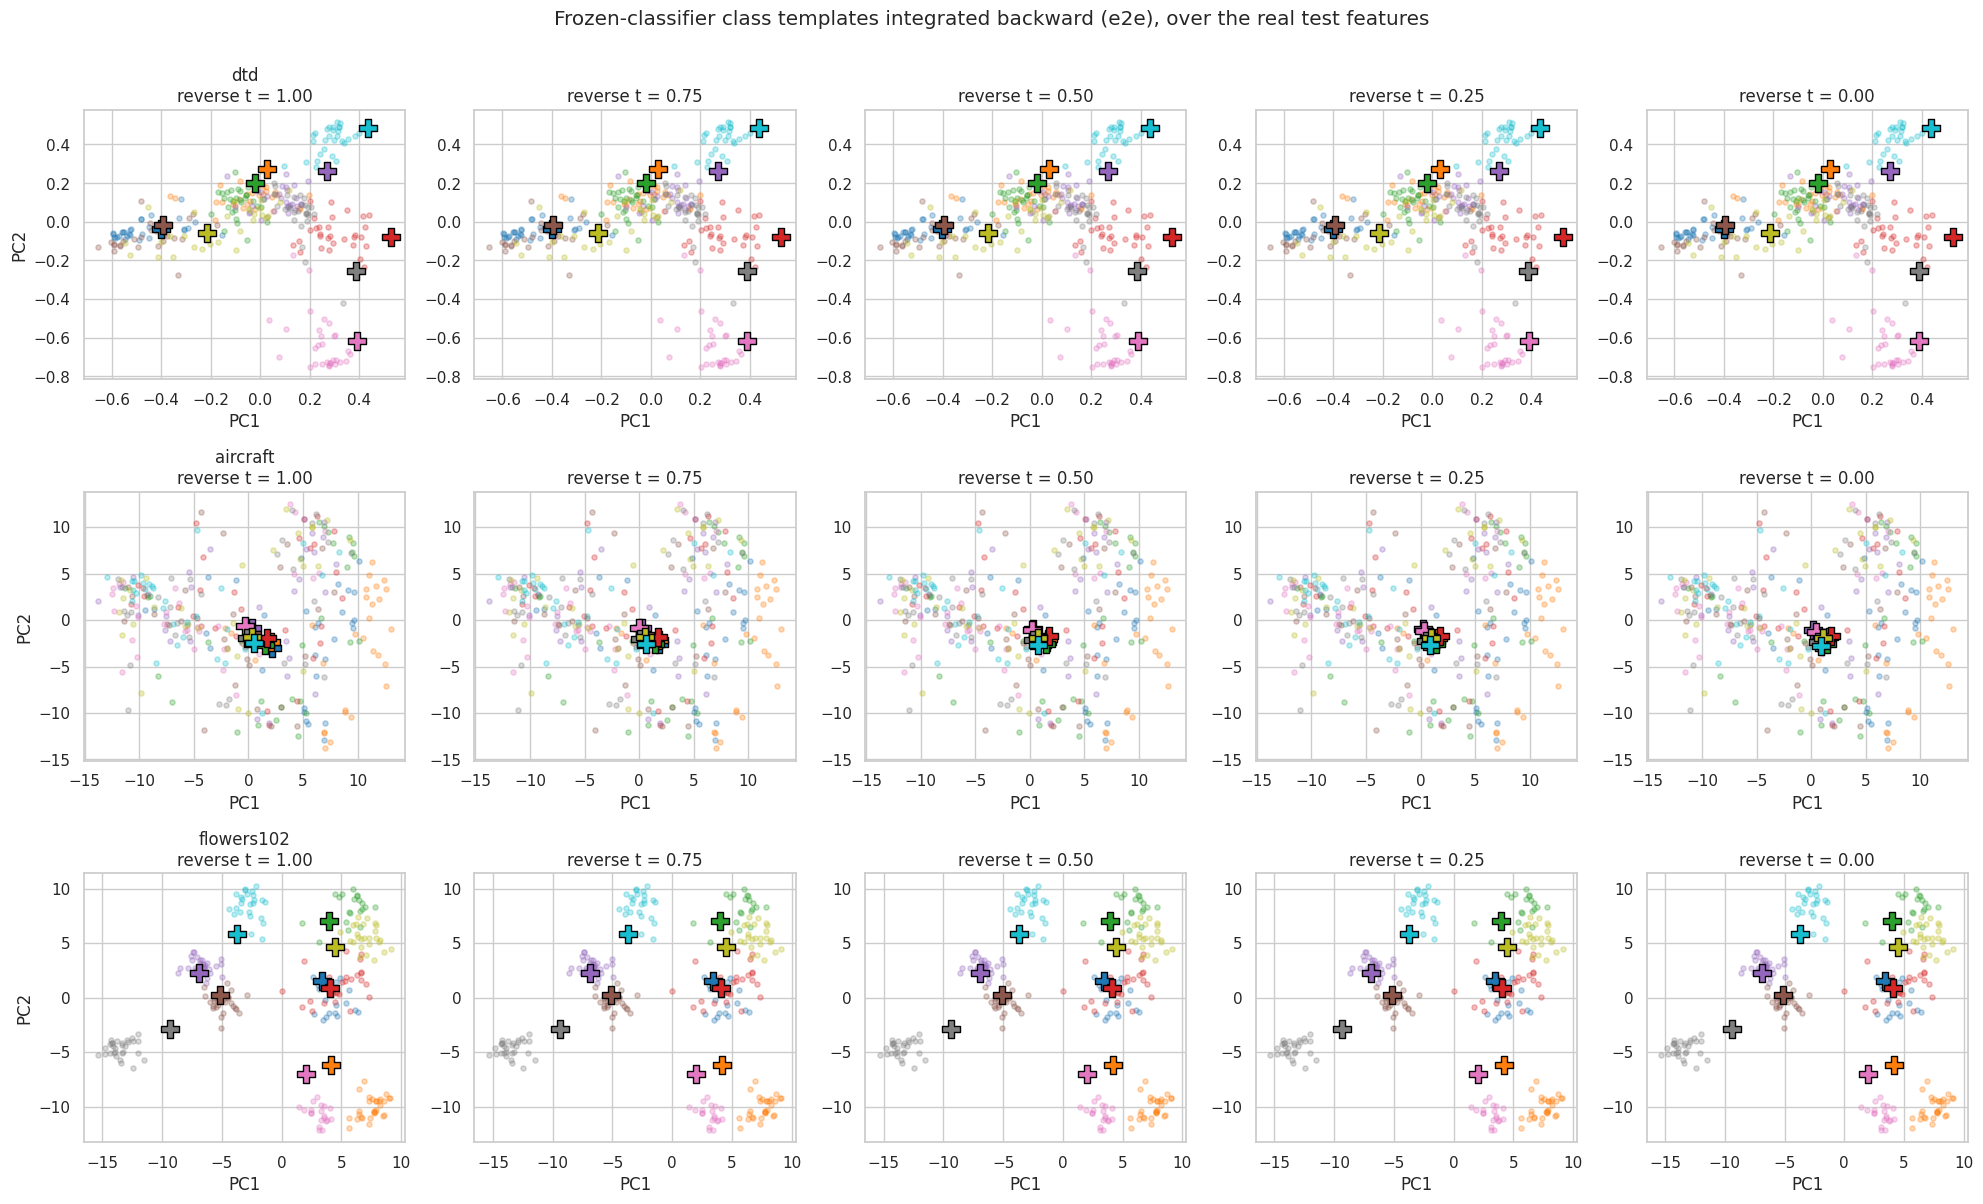

In [69]:
if RUN_REVERSE_FLOW:
    REVERSE_SNAPSHOTS = [0, T // 4, T // 2, 3 * T // 4, T]
    REVERSE_STRATEGY = 'e2e'      # set to 'guided' for the other strategy's strip
    fig, axes = plt.subplots(len(DATASETS), len(REVERSE_SNAPSHOTS),
                             figsize=(4 * len(REVERSE_SNAPSHOTS), 4 * len(DATASETS)), squeeze=False)
    for row, dataset_name in enumerate(DATASETS):
        view = reverse_views[(dataset_name, REVERSE_STRATEGY)]
        labels = view['y'].numpy()
        selected = np.unique(labels)[:N_VIS_CLASSES]
        sel = np.concatenate([np.flatnonzero(labels == c)[:VIS_PER_CLASS] for c in selected])
        bg, bg_y = view['z'][sel].numpy(), labels[sel]
        states = [view['traj'][k][selected].numpy() for k in REVERSE_SNAPSHOTS]
        pca = PCA(n_components=2, random_state=0).fit(np.concatenate([bg] + states))
        bg_xy = pca.transform(bg); state_xy = [pca.transform(s) for s in states]
        allxy = np.concatenate([bg_xy] + state_xy)
        pad = 0.05 * np.ptp(allxy, axis=0)
        xlim = (allxy[:, 0].min() - pad[0], allxy[:, 0].max() + pad[0])
        ylim = (allxy[:, 1].min() - pad[1], allxy[:, 1].max() + pad[1])
        for col, (k, xy) in enumerate(zip(REVERSE_SNAPSHOTS, state_xy)):
            ax = axes[row][col]
            for i, c in enumerate(selected):
                mask = bg_y == c
                ax.scatter(bg_xy[mask, 0], bg_xy[mask, 1], s=14, alpha=0.3, color=plt.cm.tab10(i % 10))
            for i in range(len(selected)):
                ax.scatter(xy[i, 0], xy[i, 1], color=plt.cm.tab10(i % 10), marker='P', s=170,
                           edgecolors='black', zorder=5)
            header = f'{dataset_name}\n' if col == 0 else ''
            ax.set(title=f'{header}reverse t = {1 - k / T:.2f}', xlim=xlim, ylim=ylim,
                   xlabel='PC1', ylabel='PC2' if col == 0 else '')
    fig.suptitle(f'Frozen-classifier class templates integrated backward ({REVERSE_STRATEGY}), '
                 f'over the real test features', y=1.002)
    plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'reverse_flow.png', dpi=150, bbox_inches='tight')
    plt.show()

## 19. Which predictions the flow actually changes

An aggregate ΔAcc of, say, +.004 is consistent with two completely different mechanisms: the flow
fixed 8 samples and broke none, or it fixed 200 and broke 192. Those call for different conclusions,
and the mean cannot tell them apart. Every test sample is therefore sorted into one of four
outcomes against the linear probe on the same split:

| outcome | probe | Stage 3 |
|---|---|---|
| `fixed` | wrong | **right** |
| `broken` | right | **wrong** |
| `both_right` | right | right |
| `both_wrong` | wrong | wrong |

`fixed − broken` is exactly the numerator of ΔAcc, and `fixed + broken` is the churn underneath it.
The two right-hand panels then ask *what distinguishes* the samples in each group: how far the flow
moved them, and how confident the classifier was to begin with. A flow that only ever rescues
samples the probe was already unsure about is behaving sensibly; one that breaks confidently-correct
samples is not.

,dataset,strategy,fixed,broken,net,churn,delta
0,aircraft,e2e,263.6667,200.0000,63.6667,463.6667,0.0191
1,aircraft,guided,94.0000,58.6667,35.3333,152.6667,0.0106
2,dtd,e2e,0.0000,0.0000,0.0000,0.0000,0.0000
3,dtd,guided,47.0000,37.0000,10.0000,84.0000,0.0053
4,flowers102,e2e,0.0000,0.0000,0.0000,0.0000,0.0000
5,flowers102,guided,0.0000,0.0000,0.0000,0.0000,0.0000


/tmp/ipykernel_546/3487864619.py:80: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'prediction_outcomes.png', dpi=150); plt.show()


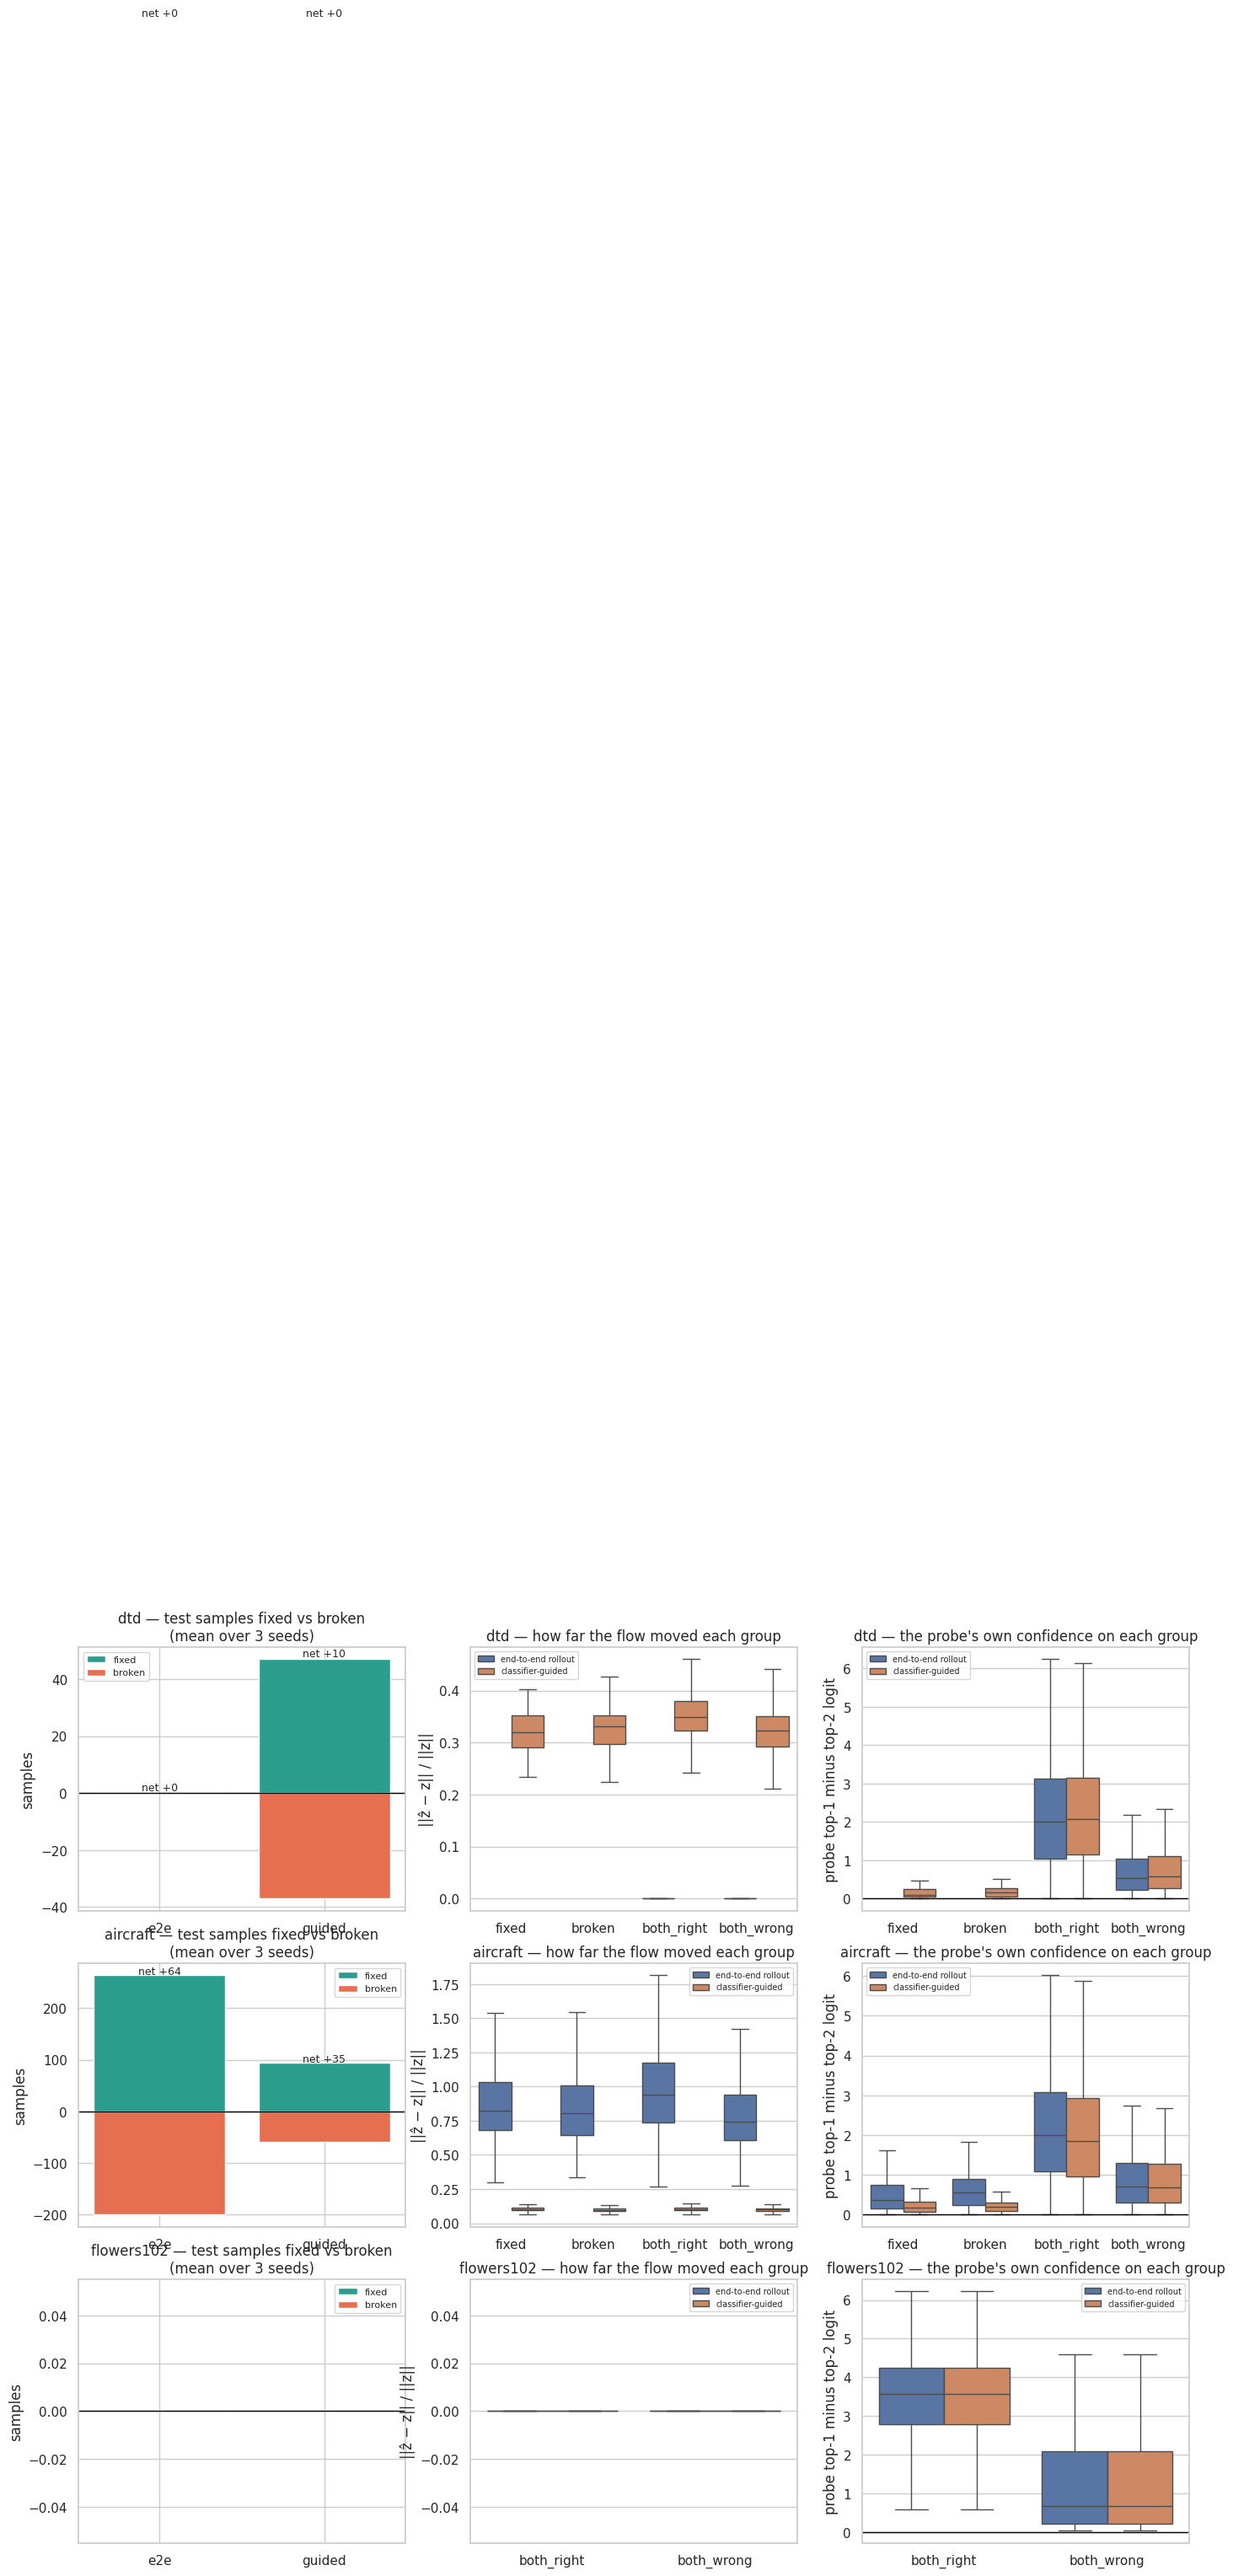

Read the right-hand panel first: if `broken` sits at a high probe margin, the flow is destroying confident correct predictions, which no aggregate ΔAcc would reveal.


In [70]:
OUTCOME_SEED = SUBSET_SEEDS[0]
OUTCOME_ORDER = ['fixed', 'broken', 'both_right', 'both_wrong']
OUTCOME_COLORS = {'fixed': '#2a9d8f', 'broken': '#e76f51',
                  'both_right': '#a8dadc', 'both_wrong': '#cccccc'}

def outcome_labels(probe_pred, fm_pred, y):
    probe_ok, fm_ok = (probe_pred == y), (fm_pred == y)
    out = np.empty(len(y), dtype=object)
    out[(~probe_ok) & fm_ok] = 'fixed'
    out[probe_ok & (~fm_ok)] = 'broken'
    out[probe_ok & fm_ok] = 'both_right'
    out[(~probe_ok) & (~fm_ok)] = 'both_wrong'
    return out

# Counts use every seed - they are free, the predictions are already in memory.
outcome_rows = []
for dataset_name in DATASETS:
    for subset_seed in SUBSET_SEEDS:
        y_te = STAGE3_DATA[(dataset_name, subset_seed)][5].cpu()
        probe_pred = main_predictions[('linear_probe', dataset_name, subset_seed)]
        for strategy, label in STRATEGIES:
            out = outcome_labels(probe_pred.numpy(), main_predictions[(strategy, dataset_name, subset_seed)].numpy(), y_te.numpy())
            counts = {k: int((out == k).sum()) for k in OUTCOME_ORDER}
            outcome_rows.append(dict(dataset=dataset_name, strategy=strategy, subset_seed=subset_seed,
                                     n=len(out), **counts,
                                     net=counts['fixed'] - counts['broken'],
                                     churn=counts['fixed'] + counts['broken'],
                                     delta=(counts['fixed'] - counts['broken']) / len(out)))
outcome_df = pd.DataFrame(outcome_rows)
outcome_df.to_csv(OUTPUT_ROOT / 'prediction_outcomes.csv', index=False)
display(outcome_df.groupby(['dataset', 'strategy'], as_index=False)
        .agg(fixed=('fixed', 'mean'), broken=('broken', 'mean'), net=('net', 'mean'),
             churn=('churn', 'mean'), delta=('delta', 'mean')).round(4))

fig, axes = plt.subplots(len(DATASETS), 3, figsize=(17, 4.6 * len(DATASETS)), squeeze=False)
for row, dataset_name in enumerate(DATASETS):
    probe = PROBES[(dataset_name, OUTCOME_SEED)]
    z_te, y_te = STAGE3_DATA[(dataset_name, OUTCOME_SEED)][4:6]
    probe_pred = main_predictions[('linear_probe', dataset_name, OUTCOME_SEED)]
    with torch.no_grad():
        probe_logits = probe['head'](z_te)
        srt = probe_logits.sort(dim=1, descending=True).values
        probe_margin = (srt[:, 0] - srt[:, 1]).cpu().numpy()

    part = outcome_df[(outcome_df.dataset == dataset_name)]
    piv = part.groupby('strategy')[['fixed', 'broken']].mean().reindex([s for s, _ in STRATEGIES])
    axes[row][0].bar(piv.index, piv['fixed'], color=OUTCOME_COLORS['fixed'], label='fixed')
    axes[row][0].bar(piv.index, -piv['broken'], color=OUTCOME_COLORS['broken'], label='broken')
    for i, (f, b) in enumerate(zip(piv['fixed'], piv['broken'])):
        axes[row][0].text(i, max(f, 0) + 1, f'net {f - b:+.0f}', ha='center', fontsize=9)
    axes[row][0].axhline(0, color='black', lw=1)
    axes[row][0].set(title=f'{dataset_name} — test samples fixed vs broken\n(mean over {len(SUBSET_SEEDS)} seeds)',
                     ylabel='samples')
    axes[row][0].legend(fontsize=8)

    disp_frames, margin_frames = [], []
    for strategy, label in STRATEGIES:
        net = load_stage3_net(strategy, dataset_name, OUTCOME_SEED, z_te.shape[1])
        with torch.no_grad():
            z_hat = euler_rollout(net, z_te, T)
            disp = ((z_hat - z_te).norm(dim=1) / z_te.norm(dim=1)).cpu().numpy()
        out = outcome_labels(probe_pred.numpy(),
                             main_predictions[(strategy, dataset_name, OUTCOME_SEED)].numpy(),
                             y_te.cpu().numpy())
        disp_frames.append(pd.DataFrame(dict(strategy=label, outcome=out, displacement=disp)))
        margin_frames.append(pd.DataFrame(dict(strategy=label, outcome=out, probe_margin=probe_margin)))
    disp_all = pd.concat(disp_frames); margin_all = pd.concat(margin_frames)
    changed = [o for o in OUTCOME_ORDER if (disp_all.outcome == o).any()]
    sns.boxplot(data=disp_all, x='outcome', y='displacement', hue='strategy', ax=axes[row][1],
                order=changed, showfliers=False)
    axes[row][1].set(title=f'{dataset_name} — how far the flow moved each group',
                     ylabel='||ẑ − z|| / ||z||', xlabel='')
    axes[row][1].legend(fontsize=7)
    sns.boxplot(data=margin_all, x='outcome', y='probe_margin', hue='strategy', ax=axes[row][2],
                order=changed, showfliers=False)
    axes[row][2].axhline(0, color='black', lw=1)
    axes[row][2].set(title=f'{dataset_name} — the probe\'s own confidence on each group',
                     ylabel='probe top-1 minus top-2 logit', xlabel='')
    axes[row][2].legend(fontsize=7)
plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'prediction_outcomes.png', dpi=150); plt.show()
print('Read the right-hand panel first: if `broken` sits at a high probe margin, the flow is '
      'destroying confident correct predictions, which no aggregate ΔAcc would reveal.')

### 19b. Is the flow one translation, or per-sample transport?

Watching Section 23's video, the cloud can appear to slide bodily across the frame rather than
rearrange — features ending up "on the other side" of where they started. That is worth taking
seriously, so this section measures it instead of explaining it away.

**First, the animation is not lying.** Frame 0 is asserted equal to `z` and the final frame equal to
`euler_rollout(net, z, T)`, the same endpoint Section 10 scores, and the projection is fit once and
held fixed. A test against a field with a known constant velocity confirms the animated motion has
cosine `+1.0` with the true motion. So the movement on screen is the movement in feature space.

**Second, there is no reason for the motion to point "toward" anything recognisable.** This is the
part that differs from Stage 2 and is easy to carry over wrongly. Stage 2's flow had an explicit
target — the class prototype — so features visibly moved *toward their own class*, and a flow going
elsewhere would have been a bug. Stage 3 has no such target. The objective is the frozen
classifier's logits, and nothing in it rewards staying near the class cloud, or near `z` at all. A
flow that improves accuracy by leaving the data manifold entirely is a valid minimum of the Stage 3
loss. Direction relative to the class clusters is therefore not evidence of a bug in either
direction.

**Third, the thing actually worth checking.** A large *common* displacement is the cheapest way for
an FM in front of an affine classifier to buy accuracy: adding a fixed vector `m` to every feature
shifts the logits by `W m`, a per-class constant — which is precisely a re-fit of the classifier's
**bias**. That would raise accuracy while transporting nothing per-sample, and it is exactly what a
cloud sliding bodily across the frame looks like.

So the displacement is split in two and each half is scored on its own:

| control | what it isolates |
|---|---|
| `shift_only` = `head(z + m)` | the common translation alone, no per-sample structure |
| `residual_only` = `head(z + (ẑ − z) − m)` | the per-sample structure alone, no net translation |

`m` is estimated on the **training** subset and applied to test, so the control never sees test
displacements. `common_fraction` is `‖m‖` over the mean per-sample displacement: 1.0 means every
sample moves by the same vector, 0 means the moves cancel.

**How to read the result.** If `shift_only` recovers most of the gain, the FM's benefit is a bias
correction a single vector could deliver — real, reproducible, but not learned per-sample transport,
and it should be reported that way rather than as flow matching doing the work. If `residual_only`
carries it, the transport is genuinely per-sample and the apparent sliding is a common-mode component
riding on top of it.

In [ ]:
@torch.no_grad()
def displacement_decomposition(net, head, z_train, z_test, y_test, T):
    """Split what the flow does into a common translation and a per-sample residual.

    The translation is estimated on the TRAINING subset and applied to test, so the control never
    sees test displacements.
    """
    net.eval()
    m = (euler_rollout(net, z_train, T) - z_train).mean(0, keepdim=True)
    z_hat = euler_rollout(net, z_test, T)
    delta = z_hat - z_test
    per_sample_norm = delta.norm(dim=1).mean()

    def acc(x):
        return float((head(x).argmax(1) == y_test).float().mean())

    unit = delta / delta.norm(dim=1, keepdim=True).clamp_min(1e-12)
    return dict(
        probe=acc(z_test), stage3=acc(z_hat),
        shift_only=acc(z_test + m), residual_only=acc(z_test + delta - m),
        common_norm=float(m.norm()), mean_displacement=float(per_sample_norm),
        common_fraction=float(m.norm() / per_sample_norm.clamp_min(1e-12)),
        direction_coherence=float(unit.mean(0).norm()))

decomp_rows = []
for dataset_name in DATASETS:
    probe = PROBES[(dataset_name, OUTCOME_SEED)]
    z_tr, _, _, _, z_te, y_te = STAGE3_DATA[(dataset_name, OUTCOME_SEED)]
    for strategy, label in STRATEGIES:
        net = load_stage3_net(strategy, dataset_name, OUTCOME_SEED, z_te.shape[1])
        stats = displacement_decomposition(net, probe['head'], z_tr, z_te, y_te, T)
        gain = stats['stage3'] - stats['probe']
        decomp_rows.append(dict(
            dataset=dataset_name, strategy=strategy, **stats,
            gain=gain,
            shift_share=(stats['shift_only'] - stats['probe']) / gain if abs(gain) > 1e-9 else np.nan,
            residual_share=(stats['residual_only'] - stats['probe']) / gain if abs(gain) > 1e-9 else np.nan))
decomp_df = pd.DataFrame(decomp_rows)
decomp_df.to_csv(OUTPUT_ROOT / 'displacement_decomposition.csv', index=False)
display(decomp_df.round(4))

moved = decomp_df[decomp_df.mean_displacement > 1e-6]
if len(moved):
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
    tidy = moved.melt(id_vars=['dataset', 'strategy'],
                      value_vars=['probe', 'shift_only', 'residual_only', 'stage3'],
                      var_name='variant', value_name='accuracy')
    tidy['cell'] = tidy.dataset + '\n' + tidy.strategy
    sns.barplot(data=tidy, x='cell', y='accuracy', hue='variant', ax=axes[0],
                hue_order=['probe', 'shift_only', 'residual_only', 'stage3'])
    axes[0].set(title='Which half of the displacement carries the gain?', xlabel='')
    axes[0].legend(fontsize=8)
    axes[1].bar(moved.dataset + '\n' + moved.strategy, moved.common_fraction,
                color='#457b9d', label='common_fraction  ||m|| / mean||Δ||')
    axes[1].plot(moved.dataset + '\n' + moved.strategy, moved.direction_coherence, 'o--',
                 color='#e76f51', label='direction_coherence')
    axes[1].set(ylim=(0, 1.05), title='How much of the motion is one shared translation?', xlabel='')
    axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'displacement_decomposition.png', dpi=150); plt.show()

    for r in moved.itertuples():
        if not np.isfinite(r.shift_share): continue
        verdict = ('a common translation - i.e. effectively a classifier-bias re-fit'
                   if r.shift_share > 0.7 else
                   'genuine per-sample transport' if r.residual_share > 0.7 else
                   'a mixture of the two')
        print(f'{r.dataset:11s} {r.strategy:7s}: gain {r.gain:+.4f} | '
              f'shift alone {r.shift_share:+.0%} of it, residual alone {r.residual_share:+.0%} | '
              f'common_fraction {r.common_fraction:.2f} -> {verdict}')
else:
    print('No cell moved its features: every selected checkpoint kept the identity.')

## 20. Per-class effects

ΔAcc is a mean over classes as well as over samples, and a flat mean can hide a flow that helps a
handful of classes and hurts an equal number. Each point below is one class: its accuracy under the
linear probe against its accuracy under Stage 3. Points on the diagonal are untouched; distance from
the diagonal is the per-class effect, and the labelled points are the largest movers in each
direction.

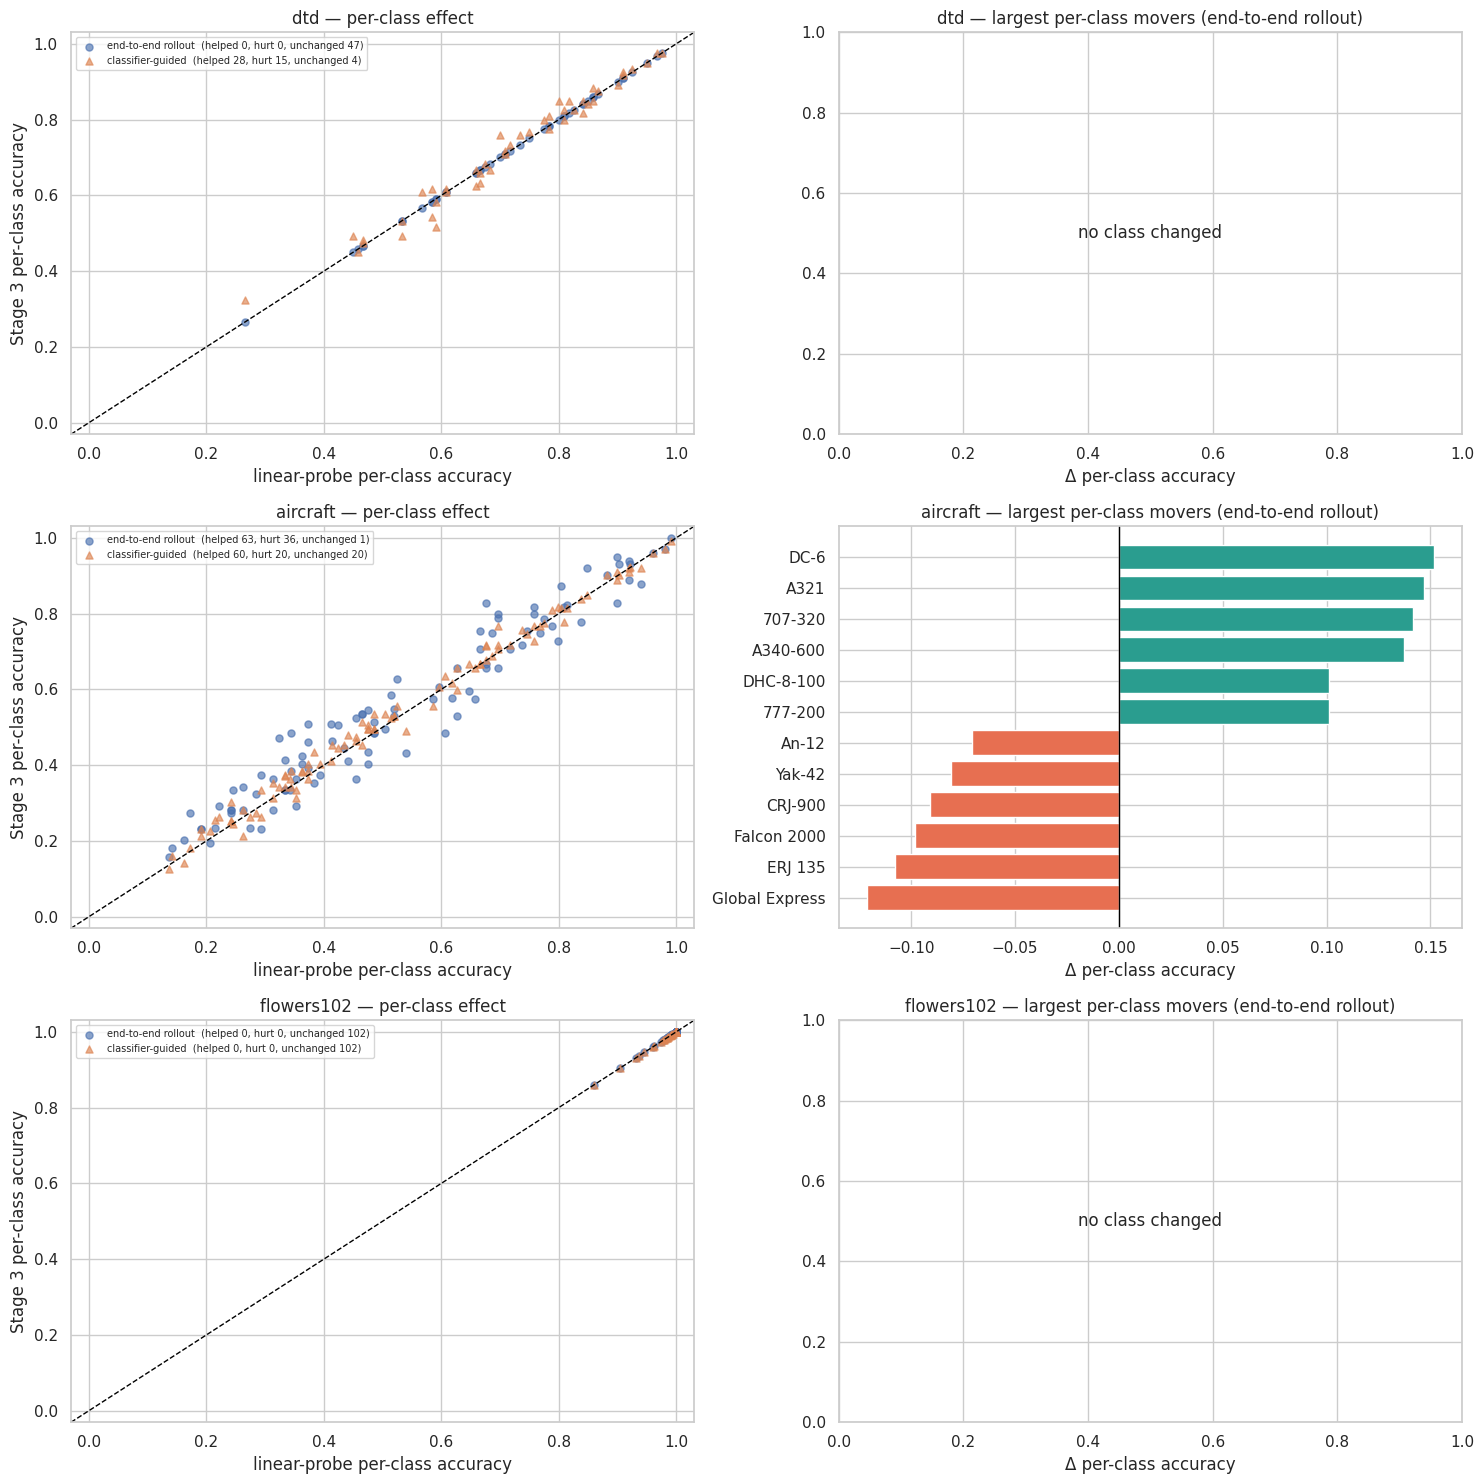

,dataset,strategy,classes_helped,classes_hurt,mean_delta,worst,best
0,aircraft,e2e,155,97,0.0191,-0.2121,0.3030
1,aircraft,guided,127,65,0.0106,-0.1515,0.1515
2,dtd,e2e,0,0,0.0000,0.0000,0.0000
3,dtd,guided,57,39,0.0053,-0.1250,0.2000
4,flowers102,e2e,0,0,0.0000,0.0000,0.0000
5,flowers102,guided,0,0,0.0000,0.0000,0.0000


In [71]:
TOP_MOVERS = 6

per_class_rows = []
for dataset_name in DATASETS:
    class_names = feature_bank[dataset_name]['test']['classes']
    for subset_seed in SUBSET_SEEDS:
        y_te = STAGE3_DATA[(dataset_name, subset_seed)][5].cpu().numpy()
        probe_pred = main_predictions[('linear_probe', dataset_name, subset_seed)].numpy()
        for strategy, label in STRATEGIES:
            fm_pred = main_predictions[(strategy, dataset_name, subset_seed)].numpy()
            for c in np.unique(y_te):
                mask = y_te == c
                per_class_rows.append(dict(
                    dataset=dataset_name, strategy=strategy, subset_seed=subset_seed,
                    class_index=int(c),
                    class_name=str(class_names[c]) if c < len(class_names) else str(c),
                    support=int(mask.sum()),
                    probe_accuracy=float((probe_pred[mask] == c).mean()),
                    stage3_accuracy=float((fm_pred[mask] == c).mean())))
per_class = pd.DataFrame(per_class_rows)
per_class['delta'] = per_class.stage3_accuracy - per_class.probe_accuracy
per_class.to_csv(OUTPUT_ROOT / 'per_class_effects.csv', index=False)

agg = (per_class.groupby(['dataset', 'strategy', 'class_index', 'class_name'], as_index=False)
       .agg(probe_accuracy=('probe_accuracy', 'mean'), stage3_accuracy=('stage3_accuracy', 'mean'),
            delta=('delta', 'mean'), support=('support', 'mean')))

fig, axes = plt.subplots(len(DATASETS), 2, figsize=(15, 5 * len(DATASETS)), squeeze=False)
for row, dataset_name in enumerate(DATASETS):
    ax = axes[row][0]
    for (strategy, label), marker in zip(STRATEGIES, ['o', '^']):
        part = agg[(agg.dataset == dataset_name) & (agg.strategy == strategy)]
        ax.scatter(part.probe_accuracy, part.stage3_accuracy, s=26, alpha=0.65, marker=marker,
                   label=f'{label}  (helped {int((part.delta > 0).sum())}, '
                         f'hurt {int((part.delta < 0).sum())}, '
                         f'unchanged {int((part.delta == 0).sum())})')
    lim = (-0.03, 1.03)
    ax.plot(lim, lim, color='black', lw=1, ls='--')
    ax.set(xlim=lim, ylim=lim, xlabel='linear-probe per-class accuracy',
           ylabel='Stage 3 per-class accuracy', title=f'{dataset_name} — per-class effect')
    ax.legend(fontsize=7, loc='upper left')

    movers = agg[(agg.dataset == dataset_name) & (agg.strategy == STRATEGIES[0][0])].copy()
    movers = pd.concat([movers.nlargest(TOP_MOVERS, 'delta'), movers.nsmallest(TOP_MOVERS, 'delta')])
    movers = movers[movers.delta != 0].sort_values('delta')
    ax2 = axes[row][1]
    if len(movers):
        colors = [OUTCOME_COLORS['fixed'] if d > 0 else OUTCOME_COLORS['broken'] for d in movers.delta]
        ax2.barh([n[:28] for n in movers.class_name], movers.delta, color=colors)
        ax2.axvline(0, color='black', lw=1)
    else:
        ax2.text(0.5, 0.5, 'no class changed', ha='center', va='center', transform=ax2.transAxes)
    ax2.set(title=f'{dataset_name} — largest per-class movers ({STRATEGIES[0][1]})',
            xlabel='Δ per-class accuracy')
plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'per_class_effects.png', dpi=150); plt.show()

spread = (per_class.groupby(['dataset', 'strategy'], as_index=False)
          .agg(classes_helped=('delta', lambda s: int((s > 0).sum())),
               classes_hurt=('delta', lambda s: int((s < 0).sum())),
               mean_delta=('delta', 'mean'), worst=('delta', 'min'), best=('delta', 'max')))
display(spread.round(4))

## 21. Flow trajectories

Stage 2 plotted the path each feature takes through the learned field; Stage 3 did not have that
figure until now. A small number of representative test examples are integrated through the flow and
their intermediate states drawn as a path, in a PCA fit jointly over the background cloud and every
trajectory point. PCA rather than t-SNE, for the reason Stage 2 gives: a trajectory has to stay
geometrically interpretable as a path, which t-SNE does not preserve.

Examples are chosen by *outcome*, not at random — some the flow fixed, some it broke, some it left
correct — so the figure shows what a successful and an unsuccessful transport look like side by
side rather than an average of the two.

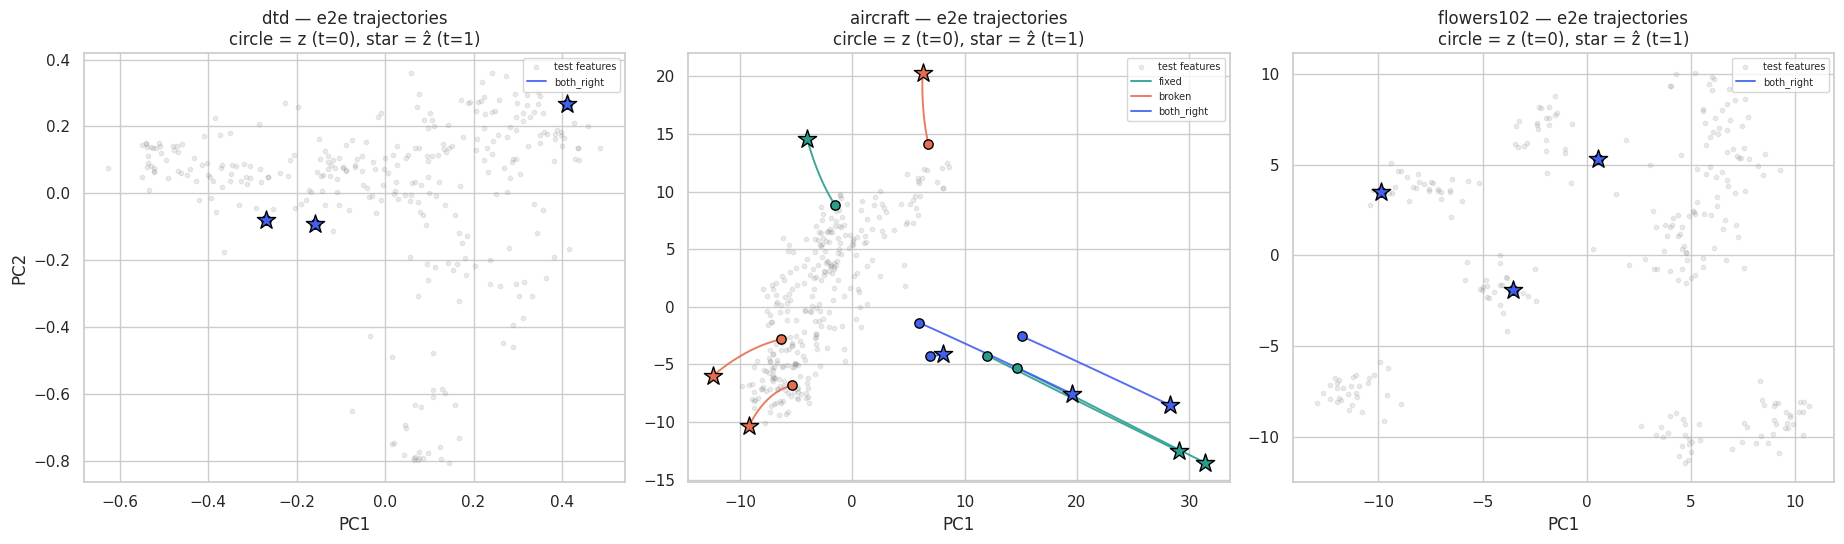

In [72]:
TRAJECTORY_STRATEGY = 'e2e'      # set to 'guided' for the other strategy
TRAJECTORY_SEED = SUBSET_SEEDS[0]
PER_OUTCOME = 3

fig, axes = plt.subplots(1, len(DATASETS), figsize=(6.2 * len(DATASETS), 5.6), squeeze=False)
for col, dataset_name in enumerate(DATASETS):
    z_te, y_te = STAGE3_DATA[(dataset_name, TRAJECTORY_SEED)][4:6]
    y_np = y_te.cpu().numpy()
    probe_pred = main_predictions[('linear_probe', dataset_name, TRAJECTORY_SEED)].numpy()
    fm_pred = main_predictions[(TRAJECTORY_STRATEGY, dataset_name, TRAJECTORY_SEED)].numpy()
    out = outcome_labels(probe_pred, fm_pred, y_np)

    rng = np.random.default_rng(0)
    picked, styles = [], []
    for name, color in (('fixed', OUTCOME_COLORS['fixed']),
                        ('broken', OUTCOME_COLORS['broken']),
                        ('both_right', '#4361ee')):
        idx = np.flatnonzero(out == name)
        take = rng.choice(idx, size=min(PER_OUTCOME, len(idx)), replace=False) if len(idx) else []
        picked.extend(take.tolist() if len(idx) else [])
        styles.extend([(name, color)] * (len(take) if len(idx) else 0))
    if not picked:
        axes[0][col].text(0.5, 0.5, 'no changed predictions', ha='center', va='center',
                          transform=axes[0][col].transAxes)
        continue

    net = load_stage3_net(TRAJECTORY_STRATEGY, dataset_name, TRAJECTORY_SEED, z_te.shape[1])
    sel = torch.as_tensor(picked, device=z_te.device)
    with torch.no_grad():
        _, traj = euler_rollout(net, z_te[sel], T, return_trajectory=True)
    paths = np.stack([s.cpu().numpy() for s in traj], axis=1)      # (n_examples, T+1, d)

    bg_classes = np.unique(y_np)[:N_VIS_CLASSES]
    bg_idx = np.concatenate([np.flatnonzero(y_np == c)[:VIS_PER_CLASS] for c in bg_classes])
    bg = z_te[torch.as_tensor(bg_idx, device=z_te.device)].cpu().numpy()

    pca = PCA(n_components=2, random_state=0).fit(np.concatenate([bg, paths.reshape(-1, paths.shape[-1])]))
    bg_xy = pca.transform(bg)
    ax = axes[0][col]
    ax.scatter(bg_xy[:, 0], bg_xy[:, 1], s=10, alpha=0.16, color='#888888', label='test features')
    seen = set()
    for i, (name, color) in enumerate(styles):
        xy = pca.transform(paths[i])
        ax.plot(xy[:, 0], xy[:, 1], color=color, lw=1.4, alpha=0.9,
                label=name if name not in seen else None)
        seen.add(name)
        ax.scatter(*xy[0], color=color, marker='o', s=45, edgecolors='black', zorder=5)
        ax.scatter(*xy[-1], color=color, marker='*', s=190, edgecolors='black', zorder=6)
    ax.set(title=f'{dataset_name} — {TRAJECTORY_STRATEGY} trajectories\n'
                 f'circle = z (t=0), star = ẑ (t=1)', xlabel='PC1', ylabel='PC2' if col == 0 else '')
    ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'flow_trajectories.png', dpi=150); plt.show()

## 22. Effect sizes at a glance

Three views of the same numbers, chosen because the bar chart in Section 10 is the least informative
of the four.

**Left — paired slopes.** One line per subset seed, connecting the probe to each Stage 3 method on
the *same* data. The comparison is paired, so this is the honest picture: what matters is whether the
lines move together and in which direction, not where the group means sit.

**Middle — a forest plot.** Every (dataset, method, seed) cell with its 95% bootstrap CI from
Section 13. Cells whose interval crosses the dashed zero line are *not* measurable differences,
however suggestive the point estimate looks. Filled markers reached McNemar p < 0.05.

**Right — the summary heatmap.** Mean ΔAcc per dataset and method, which is the table from Section 10
in a form that can be read at a glance.

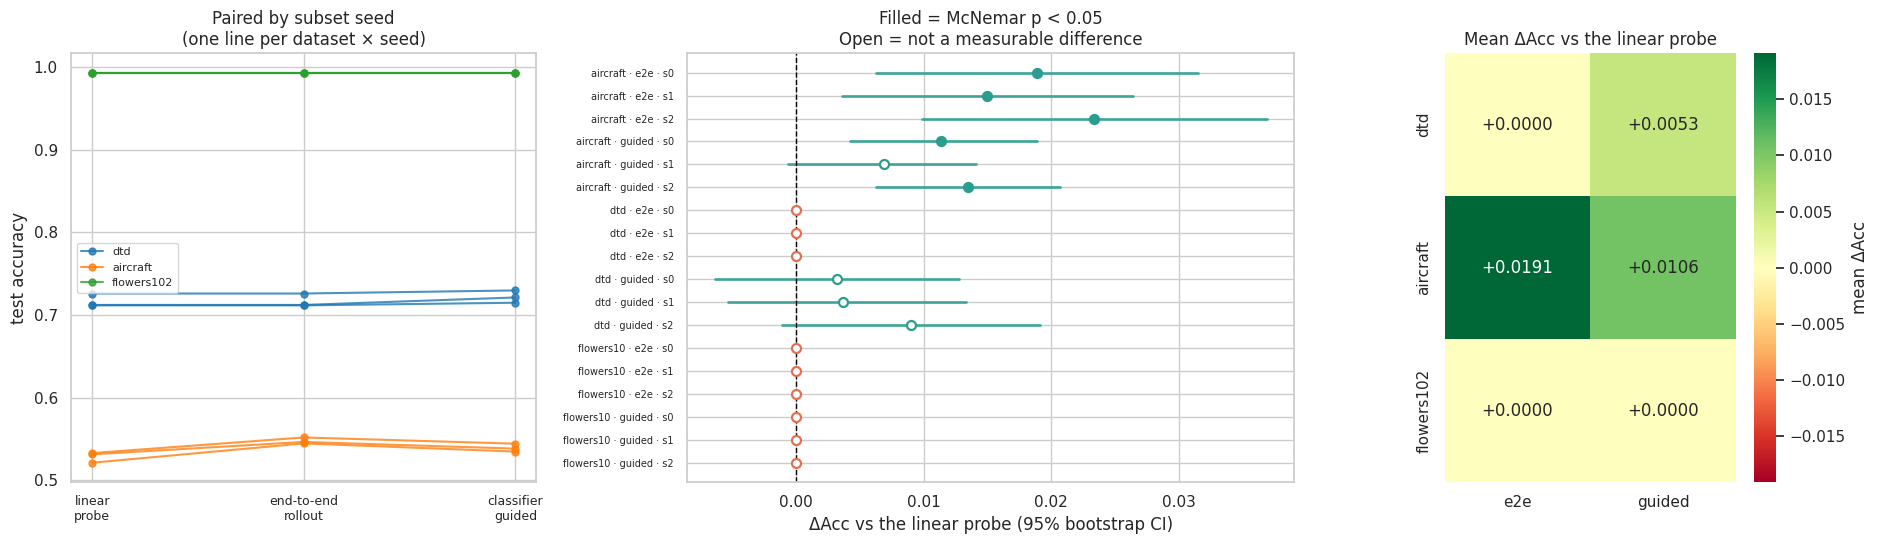

In [73]:
fig = plt.figure(figsize=(19, 5.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.5, 0.9])

ax = fig.add_subplot(gs[0, 0])
positions = {m: i for i, m in enumerate(METHOD_ORDER)}
for d_i, dataset_name in enumerate(DATASETS):
    color = plt.cm.tab10(d_i)
    for subset_seed in SUBSET_SEEDS:
        ys = []
        for method in METHOD_ORDER:
            row = results_df[(results_df.dataset == dataset_name) &
                             (results_df.strategy == method) &
                             (results_df.subset_seed == subset_seed)]
            ys.append(float(row.test_accuracy.iloc[0]))
        ax.plot(list(positions.values()), ys, marker='o', ms=5, color=color, alpha=0.8,
                label=dataset_name if subset_seed == SUBSET_SEEDS[0] else None)
ax.set_xticks(list(positions.values()))
ax.set_xticklabels(['linear\nprobe', 'end-to-end\nrollout', 'classifier\nguided'], fontsize=9)
ax.set(ylabel='test accuracy', title='Paired by subset seed\n(one line per dataset × seed)')
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[0, 1])
forest = significance_df.sort_values(['dataset', 'strategy', 'subset_seed']).reset_index(drop=True)
labels = [f'{r.dataset[:9]} · {r.strategy} · s{r.subset_seed}' for r in forest.itertuples()]
ypos = np.arange(len(forest))
for i, r in enumerate(forest.itertuples()):
    color = OUTCOME_COLORS['fixed'] if r.delta > 0 else OUTCOME_COLORS['broken']
    ax.plot([r.ci_low, r.ci_high], [i, i], color=color, lw=2, alpha=0.85)
    ax.scatter(r.delta, i, color=color, s=42, zorder=5,
               marker='o' if r.significant else 'o',
               facecolors=color if r.significant else 'white', edgecolors=color, linewidths=1.6)
ax.axvline(0, color='black', ls='--', lw=1)
ax.set_yticks(ypos); ax.set_yticklabels(labels, fontsize=7)
ax.set(xlabel='ΔAcc vs the linear probe (95% bootstrap CI)',
       title='Filled = McNemar p < 0.05\nOpen = not a measurable difference')
ax.invert_yaxis()

ax = fig.add_subplot(gs[0, 2])
heat = (summary[summary.strategy != 'linear_probe']
        .pivot(index='dataset', columns='strategy', values='mean_delta').reindex(DATASETS))
vmax = float(np.nanmax(np.abs(heat.values))) if heat.size else 1.0
sns.heatmap(heat, annot=True, fmt='+.4f', center=0, cmap='RdYlGn', vmin=-vmax, vmax=vmax,
            cbar_kws=dict(label='mean ΔAcc'), ax=ax)
ax.set(title='Mean ΔAcc vs the linear probe', xlabel='', ylabel='')
plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'effect_sizes.png', dpi=150); plt.show()

## 23. The path of the flow, as video

Two animations of the same `T`-step Euler rollout the rest of the notebook reports, rendered as MP4
where `ffmpeg` is available (it is on Colab) and as an animated GIF otherwise.

**A — the population.** The whole test cloud for a readable subset of classes, moving from `z` to
`ẑ`, in one PCA fit jointly over *every* state of *both* strategies so the two panels share a frame
and nothing jumps between them. The running caption reports the accuracy of the frozen classifier at
each Euler step, which is the Section 17 curve played back in space rather than plotted.

**B — individual paths.** A handful of examples with their trails, coloured by **outcome** rather
than by class: green for samples the flow fixed, red for ones it broke, blue for ones that were
already correct. This is the one worth watching — a `fixed` path and a `broken` path in the same
frame show what the flow is trading away, which no aggregate ΔAcc can.

Two honesty notes about what you are seeing:

- Positions between Euler states are **linear interpolation, added only so the motion is legible**.
  The model produces `T + 1` states and nothing in between; the frame counter reports the true Euler
  step, and the accuracy readout only ever changes at a real state.
- The PCA is fit once over all states and then held fixed. Points therefore move because the
  features move, not because the projection is being refitted per frame.

In [ ]:
RUN_FLOW_VIDEO = True
VIDEO_SMOOTH_FRAMES = 3       # interpolated frames between consecutive Euler states (visual only)
VIDEO_FPS = 8
VIDEO_DPI = 80                # keep the embedded animation from bloating the .ipynb
VIDEO_CLASSES, VIDEO_PER_CLASS = 8, 20

import base64
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.lines import Line2D
from IPython.display import HTML

def save_animation(anim, stem, fps=VIDEO_FPS, dpi=VIDEO_DPI):
    """MP4 when ffmpeg is available, GIF otherwise. Returns the path actually written."""
    try:
        from matplotlib.animation import FFMpegWriter
        path = OUTPUT_ROOT / f'{stem}.mp4'
        anim.save(str(path), writer=FFMpegWriter(fps=fps, bitrate=2400), dpi=dpi)
        return path
    except Exception as err:
        print(f'[info] ffmpeg unavailable ({type(err).__name__}); writing a GIF instead.')
        path = OUTPUT_ROOT / f'{stem}.gif'
        anim.save(str(path), writer=PillowWriter(fps=fps), dpi=dpi)
        return path

def show_animation(path, width=960):
    data = base64.b64encode(path.read_bytes()).decode('ascii')
    if path.suffix == '.mp4':
        display(HTML(f'<video width="{width}" controls loop autoplay muted playsinline>'
                     f'<source src="data:video/mp4;base64,{data}" type="video/mp4">'
                     f'Your browser cannot play this video.</video>'))
    else:
        display(HTML(f'<img src="data:image/gif;base64,{data}" width="{width}"/>'))
    print(f'saved: {path.name}  ({path.stat().st_size / 1e6:.1f} MB)')

def interpolated_frames(n_states, sub, hold_start=2, hold_end=6):
    """Frame plan as (step_index, alpha) pairs. alpha interpolates toward the next state and is
    presentation only - `step_index` is the true Euler step and is what the caption reports."""
    plan = [(0, 0.0)] * hold_start
    for k in range(n_states - 1):
        for j in range(sub):
            plan.append((k, j / sub))
    plan += [(n_states - 1, 0.0)] * hold_end
    return plan

# Animate the dataset where the flow does the most work, rather than hardcoding one. Ranked by
# |ΔAcc| rather than ΔAcc: a flow that makes things clearly worse is just as worth watching.
_ranked = (results_df[results_df.strategy != 'linear_probe']
           .assign(abs_delta=lambda d: d.delta_accuracy.abs())
           .groupby('dataset', as_index=False).abs_delta.max()
           .sort_values('abs_delta', ascending=False))
VIDEO_DATASET = str(_ranked.dataset.iloc[0])
VIDEO_SEED = SUBSET_SEEDS[0]
print(f'Animating {VIDEO_DATASET} (largest |ΔAcc| of the three), subset seed {VIDEO_SEED}, T={T}.')

### 23a. The population moving through the flow

In [ ]:
if RUN_FLOW_VIDEO:
    probe = PROBES[(VIDEO_DATASET, VIDEO_SEED)]
    z_te, y_te = STAGE3_DATA[(VIDEO_DATASET, VIDEO_SEED)][4:6]
    y_np = y_te.cpu().numpy()
    classes = np.unique(y_np)[:VIDEO_CLASSES]
    sel = np.concatenate([np.flatnonzero(y_np == c)[:VIDEO_PER_CLASS] for c in classes])
    sel_t = torch.as_tensor(sel, device=z_te.device)
    z_sub, y_sub = z_te[sel_t], y_np[sel]

    states, step_accuracy = {}, {}
    for strategy, label in STRATEGIES:
        net = load_stage3_net(strategy, VIDEO_DATASET, VIDEO_SEED, z_te.shape[1])
        with torch.no_grad():
            _, traj = euler_rollout(net, z_sub, T, return_trajectory=True)
        stacked = np.stack([s.cpu().numpy() for s in traj])          # (T+1, n, d)
        assert stacked.shape[0] == T + 1
        assert np.allclose(stacked[0], z_sub.cpu().numpy()), 'trajectory must start at the untouched feature'
        with torch.no_grad():
            endpoint = euler_rollout(net, z_sub, T).cpu().numpy()
        # the video must end on the state Section 10 scored, or it is showing a different flow
        assert np.allclose(stacked[-1], endpoint), 'trajectory must end at the reported z_hat'
        states[strategy] = stacked
        # accuracy over the COMPLETE test split, not just the animated subset
        step_accuracy[strategy] = accuracy_by_step(net, probe['head'], z_te, y_te, T)

    pca = PCA(n_components=2, random_state=0).fit(
        np.concatenate([states[s].reshape(-1, z_sub.shape[1]) for s, _ in STRATEGIES]))
    proj = {s: np.stack([pca.transform(states[s][k]) for k in range(T + 1)]) for s, _ in STRATEGIES}
    allxy = np.concatenate([proj[s].reshape(-1, 2) for s, _ in STRATEGIES])
    pad = 0.06 * np.ptp(allxy, axis=0)
    xlim = (allxy[:, 0].min() - pad[0], allxy[:, 0].max() + pad[0])
    ylim = (allxy[:, 1].min() - pad[1], allxy[:, 1].max() + pad[1])

    fig, axes = plt.subplots(1, len(STRATEGIES), figsize=(6.2 * len(STRATEGIES), 5.9))
    fig.subplots_adjust(top=0.80, bottom=0.06)
    scatters = []
    for ax, (strategy, label) in zip(np.atleast_1d(axes), STRATEGIES):
        colors = np.array([plt.cm.tab10(list(classes).index(c) % 10) for c in y_sub])
        sc = ax.scatter(proj[strategy][0][:, 0], proj[strategy][0][:, 1], s=18, c=colors, alpha=0.85)
        ax.set(xlim=xlim, ylim=ylim, xticks=[], yticks=[], title=label)
        scatters.append((strategy, ax, sc))
    caption = fig.text(0.5, 0.865, '', ha='center', fontsize=12)
    fig.suptitle(f'{VIDEO_DATASET} / {ENCODER} — the test cloud flowing from z to ẑ\n'
                 f'(K={SHOT}, subset seed {VIDEO_SEED}, T={T}; one joint PCA, held fixed)',
                 y=0.985, fontsize=12)

    plan = interpolated_frames(T + 1, VIDEO_SMOOTH_FRAMES)

    def draw(frame):
        k, alpha = plan[frame]
        parts = []
        for strategy, ax, sc in scatters:
            a = proj[strategy][k]
            b = proj[strategy][min(k + 1, T)]
            sc.set_offsets(a * (1 - alpha) + b * alpha)
            parts.append(f'{dict(STRATEGIES)[strategy]} {step_accuracy[strategy][k]:.4f}')
        caption.set_text(f'Euler step {k}/{T}   (t = {k / T:.2f})    '
                         f'test accuracy — probe {probe["stage1_test_accuracy"]:.4f}   |   '
                         + '   |   '.join(parts))
        return []

    anim = FuncAnimation(fig, draw, frames=len(plan), interval=1000 // VIDEO_FPS, blit=False)
    path = save_animation(anim, f'flow_population_{VIDEO_DATASET}')
    plt.close(fig)
    show_animation(path)
    print('Accuracy in the caption is measured on the complete test split at each Euler state; the '
          'moving points are the animated subset only.')
else:
    print('Flow video disabled (RUN_FLOW_VIDEO = False).')

### 23b. Individual paths, coloured by outcome

In [ ]:
if RUN_FLOW_VIDEO:
    PATHS_PER_OUTCOME = 2
    OUTCOME_STYLE = [('fixed', OUTCOME_COLORS['fixed']),
                     ('broken', OUTCOME_COLORS['broken']),
                     ('both_right', '#4361ee')]

    probe = PROBES[(VIDEO_DATASET, VIDEO_SEED)]
    z_te, y_te = STAGE3_DATA[(VIDEO_DATASET, VIDEO_SEED)][4:6]
    y_np = y_te.cpu().numpy()
    probe_pred = main_predictions[('linear_probe', VIDEO_DATASET, VIDEO_SEED)].numpy()

    # choose examples on the FIRST strategy's outcomes, then show the same examples under both,
    # so the two panels are the same samples rather than each strategy's own best cases
    ref_out = outcome_labels(probe_pred,
                             main_predictions[(STRATEGIES[0][0], VIDEO_DATASET, VIDEO_SEED)].numpy(),
                             y_np)
    rng = np.random.default_rng(0)
    picked, pick_style = [], []
    for name, color in OUTCOME_STYLE:
        idx = np.flatnonzero(ref_out == name)
        if not len(idx): continue
        take = rng.choice(idx, size=min(PATHS_PER_OUTCOME, len(idx)), replace=False)
        picked.extend(take.tolist()); pick_style.extend([(name, color)] * len(take))

    if not picked:
        print('No prediction changed under', STRATEGIES[0][1],
              '- nothing to animate here. The population video above still applies.')
    else:
        sel_t = torch.as_tensor(picked, device=z_te.device)
        paths = {}
        for strategy, label in STRATEGIES:
            net = load_stage3_net(strategy, VIDEO_DATASET, VIDEO_SEED, z_te.shape[1])
            with torch.no_grad():
                _, traj = euler_rollout(net, z_te[sel_t], T, return_trajectory=True)
            paths[strategy] = np.stack([s.cpu().numpy() for s in traj])     # (T+1, n, d)

        bg_classes = np.unique(y_np)[:VIDEO_CLASSES]
        bg_idx = np.concatenate([np.flatnonzero(y_np == c)[:VIDEO_PER_CLASS] for c in bg_classes])
        bg = z_te[torch.as_tensor(bg_idx, device=z_te.device)].cpu().numpy()

        pca = PCA(n_components=2, random_state=0).fit(np.concatenate(
            [bg] + [paths[s].reshape(-1, bg.shape[1]) for s, _ in STRATEGIES]))
        bg_xy = pca.transform(bg)
        proj = {s: np.stack([pca.transform(paths[s][k]) for k in range(T + 1)]) for s, _ in STRATEGIES}
        allxy = np.concatenate([bg_xy] + [proj[s].reshape(-1, 2) for s, _ in STRATEGIES])
        pad = 0.06 * np.ptp(allxy, axis=0)
        xlim = (allxy[:, 0].min() - pad[0], allxy[:, 0].max() + pad[0])
        ylim = (allxy[:, 1].min() - pad[1], allxy[:, 1].max() + pad[1])

        fig, axes = plt.subplots(1, len(STRATEGIES), figsize=(6.2 * len(STRATEGIES), 6.1))
        fig.subplots_adjust(top=0.80, bottom=0.13)
        panels = []
        for ax, (strategy, label) in zip(np.atleast_1d(axes), STRATEGIES):
            ax.scatter(bg_xy[:, 0], bg_xy[:, 1], s=10, alpha=0.14, color='#888888')
            artists = []
            for i, (name, color) in enumerate(pick_style):
                start = proj[strategy][0][i]
                ax.scatter([start[0]], [start[1]], s=95, facecolors='none', edgecolors=color,
                           linewidths=2.0, zorder=6)
                trail, = ax.plot([], [], color=color, lw=1.8, zorder=4)
                cur, = ax.plot([], [], marker='o', ms=9, color=color, mec='black', mew=1.0, zorder=7)
                artists.append((trail, cur))
            ax.set(xlim=xlim, ylim=ylim, xticks=[], yticks=[], title=label)
            panels.append((strategy, artists))
        caption = fig.text(0.5, 0.865, '', ha='center', fontsize=12)
        legend = [Line2D([], [], color=c, lw=2.5, label=n) for n, c in OUTCOME_STYLE
                  if any(s == n for s, _ in pick_style)]
        legend += [Line2D([], [], marker='o', ls='', ms=9, mfc='none', mec='#555', mew=2, label='z (t=0)')]
        fig.legend(handles=legend, loc='lower center', ncol=len(legend), fontsize=9,
                   bbox_to_anchor=(0.5, 0.01))
        fig.suptitle(f'{VIDEO_DATASET} / {ENCODER} — individual paths, coloured by outcome under '
                     f'{STRATEGIES[0][1]}\n(same examples in both panels; grey = test features)',
                     y=0.985, fontsize=12)

        plan = interpolated_frames(T + 1, VIDEO_SMOOTH_FRAMES)

        def draw_paths(frame):
            k, alpha = plan[frame]
            for strategy, artists in panels:
                xy = proj[strategy]
                nxt = xy[min(k + 1, T)]
                for i, (trail, cur) in enumerate(artists):
                    hist = xy[:k + 1, i]
                    here = xy[k, i] * (1 - alpha) + nxt[i] * alpha
                    trail.set_data(np.append(hist[:, 0], here[0]), np.append(hist[:, 1], here[1]))
                    cur.set_data([here[0]], [here[1]])
            caption.set_text(f'Euler step {k}/{T}   (t = {k / T:.2f})')
            return []

        anim = FuncAnimation(fig, draw_paths, frames=len(plan), interval=1000 // VIDEO_FPS, blit=False)
        path = save_animation(anim, f'flow_paths_{VIDEO_DATASET}')
        plt.close(fig)
        show_animation(path)
        print('Green paths end somewhere the frozen classifier gets right and did not before; red '
              'paths end somewhere it now gets wrong. Both are the same field.')

### 23c. A simulation you can actually see

Everything above operates in 384 dimensions, where the only evidence about what the flow does is a
number or a 2D projection of something that is not 2D. This section runs the **exact same code** —
`make_velocity_net`, `train_stage3`, `euler_rollout`, `evaluate_system` — on a two-dimensional
problem, where the frozen classifier's decision regions can be drawn directly and no projection is
involved. Nothing here touches Stage 1 data: it is a self-contained demonstration, and because it
exercises the same functions it doubles as an end-to-end check that the machinery does what the
prose above claims.

The toy is built so a linear classifier *cannot* work at all: **two concentric rings**, an inner disc
inside a surrounding annulus. No affine boundary separates those, so the frozen probe sits at chance
whatever it does, and the question becomes whether the FM can rearrange the plane until a line —
*that* line, the one already fitted and now frozen — becomes the right answer.

An earlier version of this toy used a bimodal class with lobes on opposite sides. It looked
non-linear but is not: a classifier can give that class near-zero weight and hand it every region the
others do not claim, so the probe reached .92 and there was nothing left for the flow to do. Rings
have no such escape. The toy probe is also checkpointed on validation accuracy exactly as Stage 1 is
— without that it keeps whatever the last step left, which on a problem with no linear signal can
land *below* chance and inflate the flow's apparent gain.

Three variants are run, and the third is the point of including a toy at all. Strategy 2 at its
default guidance step does nothing here, while the same strategy with a larger step works. That is a
tuning artifact rather than a limitation of the method, and it is visible here in a way it is not at
384 dimensions: the trust region caps how far the target may move per refresh, so too small a step
means the target creeps and the run early-stops before it has travelled anywhere useful. It is the
concrete reason Section 15's sweep exists.

Watch for three things in the panels below.

1. **The decision regions never change.** They are drawn from the frozen `W, b` and are identical in
   every panel. Only the points move.
2. **How the rings are rearranged.** The flow has to turn a radial problem into a linearly separable
   one, using a boundary it did not choose and cannot alter.
3. **The velocity field itself.** The quiver panels show `v(z, t)` on a grid at three flow times.
   This is the object being learned, and in 384 dimensions it can never be looked at directly.

In [ ]:
RUN_TOY_SIMULATION = True
TOY_ROOT = OUTPUT_ROOT / 'toy'
TOY_N_PER_CLASS, TOY_SEED = 240, 0

# strategy, label, hyper overrides
TOY_VARIANTS = [
    ('e2e',    'end-to-end rollout',                {}),
    ('guided', 'classifier-guided (default step)',  {}),
    ('guided', 'classifier-guided (step 0.5)',      dict(guidance_step_size=0.5)),
]

# The toy is a demonstration, not a grid cell, so it gets its own budget rather than inheriting
# whatever the main config uses. Restored immediately afterwards so nothing downstream is affected.
TOY_BUDGET = dict(max_epochs=400, early_stopping_patience=80, lr_patience=25, learning_rate=3e-3,
                  hidden_dim=128, checkpoint_interval=100)

def make_toy_problem(seed=0):
    """Two concentric rings: an inner disc (class 0) inside an annulus (class 1). No affine
    boundary separates these, so the frozen linear probe is stuck at chance by construction."""
    rng = np.random.default_rng(seed)
    xs, ys = [], []
    for label, (r_lo, r_hi) in enumerate([(0.0, 1.1), (2.4, 3.4)]):
        radius = np.sqrt(rng.uniform(r_lo ** 2, r_hi ** 2, size=TOY_N_PER_CLASS))
        angle = rng.uniform(0, 2 * np.pi, size=TOY_N_PER_CLASS)
        xs.append(np.stack([radius * np.cos(angle), radius * np.sin(angle)], 1)
                  + rng.normal(scale=0.12, size=(TOY_N_PER_CLASS, 2)))
        ys.extend([label] * TOY_N_PER_CLASS)
    x = torch.tensor(np.concatenate(xs), dtype=torch.float32)
    y = torch.tensor(ys, dtype=torch.long)
    perm = torch.randperm(len(y), generator=torch.Generator().manual_seed(seed))
    x, y = x[perm], y[perm]
    n = len(y); a, b = int(0.4 * n), int(0.6 * n)
    return (x[:a].to(DEVICE), y[:a].to(DEVICE), x[a:b].to(DEVICE), y[a:b].to(DEVICE),
            x[b:].to(DEVICE), y[b:].to(DEVICE))

def train_toy_probe(x, y, x_val, y_val, n_classes=2, epochs=400):
    """The 'Stage 1' step of the toy: fit a linear head, select the checkpoint on validation
    accuracy exactly as Stage 1 does, then freeze it."""
    seed_everything(0)
    head = nn.Linear(2, n_classes).to(DEVICE)
    optimizer = torch.optim.AdamW(head.parameters(), lr=0.05, weight_decay=1e-4)
    best_acc, best_state = -1.0, copy.deepcopy(head.state_dict())
    for _ in range(epochs):
        optimizer.zero_grad(set_to_none=True)
        F.cross_entropy(head(x), y).backward()
        optimizer.step()
        with torch.no_grad():
            acc = float((head(x_val).argmax(1) == y_val).float().mean())
        if acc > best_acc:
            best_acc, best_state = acc, copy.deepcopy(head.state_dict())
    head.load_state_dict(best_state)
    head.requires_grad_(False); head.eval()
    return head

def decision_grid(head, xlim, ylim, steps=320):
    gx, gy = np.meshgrid(np.linspace(*xlim, steps), np.linspace(*ylim, steps))
    grid = torch.tensor(np.stack([gx.ravel(), gy.ravel()], 1), dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        regions = head(grid).argmax(1).cpu().numpy().reshape(gx.shape)
    return gx, gy, regions

if RUN_TOY_SIMULATION:
    tx, ty, vx, vy, sx, sy = make_toy_problem(TOY_SEED)
    toy_head = train_toy_probe(tx, ty, vx, vy)
    toy_probe_acc, _, _ = evaluate_system(None, toy_head, sx, sy, T)
    print(f'toy linear probe (frozen from here on): test accuracy {toy_probe_acc:.4f} '
          f'— chance is 0.5, and no line can do better on rings')

    _saved_s3 = {k: S3[k] for k in TOY_BUDGET if k in S3}
    S3.update(TOY_BUDGET)
    toy_nets, toy_results = {}, []
    for strategy, label, hyper in TOY_VARIANTS:
        run_dir = TOY_ROOT / label.replace(' ', '_').replace('(', '').replace(')', '').replace('.', '')
        run_dir.mkdir(parents=True, exist_ok=True)
        cfg = dict(stage='stage3-toy', strategy=strategy, label=label, T=T, feature_dim=2,
                   num_classes=2, hyper=hyper)
        net, history, best_val, best_epoch, secs = train_stage3(
            strategy, tx, ty, vx, vy, toy_head, T, run_dir, cfg,
            init_seed=INIT_SEED, hyper=hyper, verbose=False)
        acc, ce, _ = evaluate_system(net, toy_head, sx, sy, T)
        toy_nets[label] = net
        toy_results.append(dict(variant=label, strategy=strategy, probe=toy_probe_acc, stage3=acc,
                                delta=acc - toy_probe_acc, best_epoch=best_epoch,
                                epochs=len(history) - 1, seconds=secs))
        print(f'  {label:34s} test {acc:.4f} ({acc - toy_probe_acc:+.4f})  best@{best_epoch}')
    S3.update(_saved_s3)          # restore the real configuration
    toy_df = pd.DataFrame(toy_results)
    toy_df.to_csv(OUTPUT_ROOT / 'toy_simulation.csv', index=False)
    display(toy_df.round(4))
else:
    print('Toy simulation disabled (RUN_TOY_SIMULATION = False).')

### 23c-i. Before and after, over the frozen decision regions

In [ ]:
if RUN_TOY_SIMULATION:
    TOY_COLORS = np.array([[0.85, 0.33, 0.10], [0.00, 0.45, 0.74]])
    y_np = sy.cpu().numpy()
    with torch.no_grad():
        views = [('original z', sx.cpu().numpy())] + [
            (label, euler_rollout(toy_nets[label], sx, T).cpu().numpy())
            for _s, label, _h in TOY_VARIANTS]
    stacked = np.concatenate([v for _n, v in views])
    pad = 0.12 * np.ptp(stacked, axis=0)
    xlim = (stacked[:, 0].min() - pad[0], stacked[:, 0].max() + pad[0])
    ylim = (stacked[:, 1].min() - pad[1], stacked[:, 1].max() + pad[1])
    gx, gy, regions = decision_grid(toy_head, xlim, ylim)

    fig, axes = plt.subplots(1, len(views), figsize=(5.6 * len(views), 5.6), squeeze=False)
    for ax, (name, pts) in zip(axes[0], views):
        ax.contourf(gx, gy, regions, levels=[-0.5, 0.5, 1.5], colors=TOY_COLORS, alpha=0.16)
        ax.contour(gx, gy, regions, levels=[0.5], colors='black', linewidths=1.2)
        with torch.no_grad():
            pred = toy_head(torch.tensor(pts, dtype=torch.float32, device=DEVICE)).argmax(1)
            wrong = (pred != sy).cpu().numpy()
        acc = 1.0 - wrong.mean()
        ax.scatter(pts[~wrong, 0], pts[~wrong, 1], s=16, c=TOY_COLORS[y_np[~wrong]], alpha=0.9)
        ax.scatter(pts[wrong, 0], pts[wrong, 1], s=40, facecolors='none', edgecolors='black',
                   linewidths=0.9, label=f'misclassified ({wrong.sum()})')
        ax.set(xlim=xlim, ylim=ylim, xticks=[], yticks=[], title=f'{name}\naccuracy {acc:.4f}')
        ax.legend(fontsize=8, loc='upper right')
    fig.suptitle('The shaded regions are the FROZEN classifier and are identical in every panel — '
                 'only the points move', y=1.0)
    plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'toy_decision_regions.png', dpi=150,
                                    bbox_inches='tight'); plt.show()

### 23c-ii. The learned velocity field, and the paths it produces

In [ ]:
if RUN_TOY_SIMULATION:
    QUIVER_TIMES = [0.0, 0.5, 1.0 - 1.0 / T]
    shown = [(label, toy_nets[label]) for _s, label, _h in TOY_VARIANTS]
    fig, axes = plt.subplots(len(shown), len(QUIVER_TIMES) + 1,
                             figsize=(5.0 * (len(QUIVER_TIMES) + 1), 4.8 * len(shown)), squeeze=False)
    qx, qy = np.meshgrid(np.linspace(*xlim, 22), np.linspace(*ylim, 22))
    qgrid = torch.tensor(np.stack([qx.ravel(), qy.ravel()], 1), dtype=torch.float32, device=DEVICE)
    rng = np.random.default_rng(0)
    pick = rng.choice(len(sy), size=90, replace=False)
    for row, (label, net) in enumerate(shown):
        for col, t_value in enumerate(QUIVER_TIMES):
            ax = axes[row][col]
            with torch.no_grad():
                v = net(qgrid, torch.full((qgrid.shape[0],), t_value, device=DEVICE)).cpu().numpy()
            ax.contourf(gx, gy, regions, levels=[-0.5, 0.5, 1.5], colors=TOY_COLORS, alpha=0.12)
            ax.quiver(qx, qy, v[:, 0].reshape(qx.shape), v[:, 1].reshape(qx.shape),
                      np.linalg.norm(v, axis=1).reshape(qx.shape), cmap='viridis',
                      angles='xy', width=0.004)
            ax.set(xlim=xlim, ylim=ylim, xticks=[], yticks=[],
                   title=(f'{label}\nv(z, t={t_value:.2f})' if col == 0 else f'v(z, t={t_value:.2f})'),
                   ylabel='')
        ax = axes[row][-1]
        ax.contourf(gx, gy, regions, levels=[-0.5, 0.5, 1.5], colors=TOY_COLORS, alpha=0.12)
        with torch.no_grad():
            _, traj = euler_rollout(net, sx[torch.as_tensor(pick, device=DEVICE)], T,
                                    return_trajectory=True)
        paths = np.stack([s.cpu().numpy() for s in traj])
        for i in range(paths.shape[1]):
            ax.plot(paths[:, i, 0], paths[:, i, 1], lw=0.8, alpha=0.55,
                    color=TOY_COLORS[y_np[pick[i]]])
        ax.scatter(paths[0, :, 0], paths[0, :, 1], s=14, c=TOY_COLORS[y_np[pick]], alpha=0.9)
        ax.scatter(paths[-1, :, 0], paths[-1, :, 1], s=52, marker='*', c=TOY_COLORS[y_np[pick]],
                   edgecolors='black', linewidths=0.5, zorder=5)
        ax.set(xlim=xlim, ylim=ylim, xticks=[], yticks=[], title='paths  (dot = z, star = ẑ)')
    plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'toy_velocity_field.png', dpi=150); plt.show()
    print('The field is what Stage 3 learns. In 384 dimensions it can only be inferred from summary '
          'statistics; here it is the object itself. A near-zero field is a run that kept the '
          'identity - which is what the default-step guided variant does on this problem.')

### 23c-iii. The toy flow as video

In [ ]:
if RUN_TOY_SIMULATION:
    toy_traj = {}
    for _s, label, _h in TOY_VARIANTS:
        with torch.no_grad():
            _, traj = euler_rollout(toy_nets[label], sx, T, return_trajectory=True)
        toy_traj[label] = np.stack([s.cpu().numpy() for s in traj])
    toy_step_acc = {label: accuracy_by_step(toy_nets[label], toy_head, sx, sy, T)
                    for _s, label, _h in TOY_VARIANTS}

    fig, axes = plt.subplots(1, len(TOY_VARIANTS), figsize=(5.6 * len(TOY_VARIANTS), 5.8))
    fig.subplots_adjust(top=0.82)
    movers = []
    for ax, (_s, label, _h) in zip(np.atleast_1d(axes), TOY_VARIANTS):
        ax.contourf(gx, gy, regions, levels=[-0.5, 0.5, 1.5], colors=TOY_COLORS, alpha=0.16)
        ax.contour(gx, gy, regions, levels=[0.5], colors='black', linewidths=1.2)
        sc = ax.scatter(toy_traj[label][0][:, 0], toy_traj[label][0][:, 1], s=18,
                        c=TOY_COLORS[y_np], alpha=0.9)
        ax.set(xlim=xlim, ylim=ylim, xticks=[], yticks=[], title=label)
        movers.append((label, sc))
    cap = fig.text(0.5, 0.885, '', ha='center', fontsize=12)
    fig.suptitle('Toy simulation — the frozen decision boundary never moves, only the features do',
                 y=0.975, fontsize=12)

    plan = interpolated_frames(T + 1, VIDEO_SMOOTH_FRAMES)

    def draw_toy(frame):
        k, alpha = plan[frame]
        parts = []
        for label, sc in movers:
            a, b = toy_traj[label][k], toy_traj[label][min(k + 1, T)]
            sc.set_offsets(a * (1 - alpha) + b * alpha)
            parts.append(f'{toy_step_acc[label][k]:.3f}')
        cap.set_text(f'Euler step {k}/{T}  (t = {k / T:.2f})    '
                     f'probe {toy_probe_acc:.3f}   |   accuracy: ' + '   |   '.join(parts))
        return []

    anim = FuncAnimation(fig, draw_toy, frames=len(plan), interval=1000 // VIDEO_FPS, blit=False)
    toy_path = save_animation(anim, 'toy_flow')      # Section 23's writer: MP4, else GIF
    plt.close(fig)
    show_animation(toy_path, width=1000)

## 24. Summary

Everything the specification asks Stage 3 to report, in one place. The numbers below are read
straight from the saved artifacts; nothing is recomputed here.

In [ ]:
print(f'Stage 3 — FM before a frozen linear classifier')
print(f'  encoder {ENCODER} | K={SHOT} | T={T} | subset seeds {SUBSET_SEEDS}')
print(f'  {len(results_df[results_df.strategy != "linear_probe"])} trained FM layers, '
      f'{len(results_df)} result rows in the main grid\n')

final = summary.pivot(index='dataset', columns='strategy', values='mean_accuracy').reindex(DATASETS)
final_delta = summary.pivot(index='dataset', columns='strategy', values='mean_delta').reindex(DATASETS)
report = pd.DataFrame({
    'linear probe': final['linear_probe'],
    'end-to-end rollout': final['e2e'],
    'Δ e2e': final_delta['e2e'],
    'classifier-guided': final['guided'],
    'Δ guided': final_delta['guided'],
}).round(4)
display(report)
report.to_csv(OUTPUT_ROOT / 'stage3_report_table.csv')

wins = significance_df.groupby('strategy').agg(
    cells=('delta', 'size'), positive=('delta', lambda s: int((s > 0).sum())),
    negative=('delta', lambda s: int((s < 0).sum())),
    ci_excludes_zero=('ci_excludes_zero', 'sum'), mcnemar_significant=('significant', 'sum'))
display(wins)
n_csv = len(list(OUTPUT_ROOT.glob('*.csv')))
n_png = len(list(OUTPUT_ROOT.glob('*.png')))
print(f'\n{n_csv} tables and {n_png} figures written to {OUTPUT_ROOT}.')
print('Section 25 renders all of them inline.')

## 25. Everything in one place

Every figure above already renders when its own cell runs. This section reloads the saved artifacts
from Drive and renders them inline as one report, which is what you want after a resumed run, after
a kernel restart, or when the earlier output has scrolled away — the cells above are skipped on a
rerun because their results are cached, so their figures would otherwise not reappear.

Nothing is recomputed here; every table, figure and animation is read back from `OUTPUT_ROOT`.

The animations are re-embedded as base64, so running this section makes the saved `.ipynb`
noticeably larger. If you are committing the notebook with outputs, either keep
`VIDEO_SMOOTH_FRAMES` and `VIDEO_DPI` low or clear this cell's output before saving.

In [ ]:
from IPython.display import Image, Markdown

FIGURE_NOTES = {
    'accuracy_and_delta.png': 'Section 10 — top-1 test accuracy and ΔAcc against the linear probe.',
    'training_curves.png': 'Section 11 — training loss per strategy and validation accuracy of the complete system. Epoch 0 is the identity FM.',
    'feature_space_pca.png': 'Section 12 — original vs transported features, joint PCA, shared axes.',
    'feature_space_tsne.png': 'Section 12b — the same comparison under a joint t-SNE.',
    'sweep_regularization.png': 'Section 14 — Strategy 1 displacement/velocity penalties, with the displacement they actually produce.',
    'sweep_guidance.png': 'Section 15 — the four Strategy 2 guidance knobs.',
    'joint_finetune.png': 'Section 16 — unfrozen classifier vs the head-only control. Read against head_only, not against linear_probe.',
    'intermediate_flow_times.png': 'Section 17 — accuracy, margin and displacement along the flow. t=0 is the linear probe, t=1 the Stage 3 result.',
    'intermediate_flow_snapshots.png': 'Section 17b — the test point cloud at intermediate flow times.',
    'reverse_flow.png': 'Section 18b — classifier class templates integrated backward over the test features.',
    'prediction_outcomes.png': 'Section 19 — fixed vs broken, and what distinguishes those groups.',
    'per_class_effects.png': 'Section 20 — per-class accuracy before vs after, and the largest movers.',
    'flow_trajectories.png': 'Section 21 — paths through the learned field, chosen by outcome.',
    'effect_sizes.png': 'Section 22 — paired slopes, bootstrap CIs, and the ΔAcc heatmap.',
}
TABLE_NOTES = {
    'stage3_report_table.csv': 'The headline table: linear probe vs both Stage 3 methods, with ΔAcc.',
    'accuracy_summary.csv': 'Per dataset and method, mean/std accuracy and ΔAcc over the subset seeds.',
    'run_metrics.csv': 'One row per trained cell, including best_epoch and relative_displacement.',
    'paired_significance.csv': 'Bootstrap CIs and exact McNemar per (dataset, method, seed).',
    'prediction_outcomes.csv': 'Fixed / broken / unchanged counts per cell.',
    'per_class_effects.csv': 'Per-class accuracy before and after, per cell.',
    'intermediate_flow_time_metrics.csv': 'Endpoints and best t of the flow-time curves.',
    'validation_selected_tstar_summary.csv': 'The t* ablation.',
    'reverse_flow_recovery.csv': 'Reverse-flow recovery for both anchors.',
    'sweep_regularization.csv': 'Strategy 1 regularization sweep.',
    'sweep_guidance.csv': 'Strategy 2 guidance sweep.',
    'joint_finetune.csv': 'Joint fine-tuning and its head-only control.',
}

def show_report(max_table_rows=12):
    display(Markdown('## Figures'))
    for name, note in FIGURE_NOTES.items():
        path = OUTPUT_ROOT / name
        if not path.exists():
            print(f'[missing] {name} — its section was disabled or has not been run.')
            continue
        display(Markdown(f'**{name}** — {note}'))
        display(Image(filename=str(path)))
    display(Markdown('## Tables'))
    for name, note in TABLE_NOTES.items():
        path = OUTPUT_ROOT / name
        if not path.exists():
            print(f'[missing] {name}')
            continue
        frame = pd.read_csv(path)
        display(Markdown(f'**{name}** — {note}  ({len(frame)} rows)'))
        display(frame.head(max_table_rows))
        if len(frame) > max_table_rows:
            display(Markdown(f'*… {len(frame) - max_table_rows} more rows in the CSV.*'))
    animations = sorted(p for p in OUTPUT_ROOT.glob('flow_*') if p.suffix in {'.mp4', '.gif'})
    if animations:
        display(Markdown('## Animations'))
        for path in animations:
            display(Markdown(f'**{path.name}** — Section 23, the Euler rollout played back.'))
            show_animation(path)
    extra = sorted(p.name for p in OUTPUT_ROOT.glob('*')
                   if p.suffix in {'.csv', '.png'} and p.name not in FIGURE_NOTES
                   and p.name not in TABLE_NOTES)
    if extra:
        display(Markdown('**Also written, not shown above:** ' + ', '.join(f'`{n}`' for n in extra)))

show_report()